<a href="https://colab.research.google.com/github/ricardorobertson/Analise_de_Dados_e_Boas_Praticas/blob/main/MVP_Acidentes_A%C3%A9reos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP - Sprint Análise de Dados e Boas Práticas - Abril - 2026**
Pontifícia Universidade Católica do Rio de Janeiro - PUC-Rio

Titulo: Ocorrências Aeronáuticas no Brasil

Nome: Ricardo Robertson

Matrícula: 4052025002602

# 1 - Objetivo

O objetivo do MVP (Minimum Viable Product) da disciplina de Análise de Dados e Boas Práticas do curso de Ciência de Dados da Pontifícia Universidade Católica do Rio de Janeiro é criar um estudo de caso utilizando um conjunto de dados público que contenha dados reais com atributos multivariáveis e prepará-lo para ser utilizado por um modelo preditivo de classificação.


## 1.1 - Descrição do Conjunto de Dados

Para a elaboração do MVP foi selecionado o csv "Ocorrências Aeronáuticas" disponível no site da ANAC (Agência Nacional de Aviação Civil).

"https://sistemas.anac.gov.br/dadosabertos/Seguranca%20Operacional/Ocorrencia/V_OCORRENCIA_AMPLA.csv"

O conjunto de dados contém as ocorrências aeronáuticas (acidentes e incidentes graves aéreos) registradas no Brasil nos anos de 1959, 1979, 1981, 1989 e 1996 até 2024. Apesar do site da ANAC informar que os dados estão atualizados até a data de 30/03/26, data de leitura do arquivo, os dados do ano de 2025 ainda não foram carregados.

Pela análise preliminar do conjunto de dados, verifica-se que ele contém vários atributos, que estão distribuídos entre atributos qualitativos e quantitativos e possuem  informações relevantes de uma ocorrência aeronáutica. Dentre os atributos qualitativos, identifica-se que será possível utilizar diferentes técnicas de transformação de dados para prepará-los para a etapa de aprendizado máquina.

**OBSERVAÇÃO**: Como não foi possível ter acesso a um especialista no tema escolhido, ocorrências aeronáuticas, a internet foi utilizada para buscar mais informações sobre o assunto e auxiliar na análise dos dados. Ao longo do texto, essas informações serão identificadas com a palavra "**COMENTÁRIO**".

# 2 - Questões Propostas

Após a consolidação dos dados, será necessário responder à pergunta formulada ao estudo de caso do MVP. Ao invés de perguntar, por exemplo:

Qual o ano com a maior número de ocorrências aeronáuticas ou qual o número de vítimas fatais por ano no Brasil?

Prefere-se perguntar:

O conjunto de dados tratado ao longo do MVP corresponde aos dados reais?

Acredita-se que esta pergunta seja de maior relevância para o trabalho, porque evidenciará se o caminho tomado foi correto.

A partir da formulação da questão acima, será necessário determinar os atributos do conjunto de dados que serão considerados básicos para responder à questão formulada. Segue a lista dos atributos básicos.

- 'Operador_Padronizado'
- 'Classificacao_da_Ocorrencia'
- 'Tipo_de_Ocorrencia'
- 'Fase_da_Operacao'
- 'Danos_a_Aeronave'
- 'Modelo'
- 'Lesoes_Fatais_Tripulantes'
- 'Lesoes_Fatais_Passageiros'
- 'Lesoes_Fatais_Terceiros'
- 'Lesoes_Graves_Tripulantes'
- 'Lesoes_Graves_Passageiros'
- 'Lesoes_Graves_Terceiros'
- 'Data_da_Ocorrencia'
- 'Hora_da_Ocorrencia'

**OBSERVAÇÃO**: Durante a etapa de limpeza de dados poderá ocorrer o descarte de algum desses atributos. Caso isso ocorra, o conjunto de dados básicos será atualizado.

# 2 - Análise do Conjunto de Dados

O objetivo desta seção é carregar o conjunto de dados para conhecer os tipos de cada atributo antes da execução das etapas de limpeza, análise exploratória e transformação de dados.

## 2.1 - Carregamento do Conjunto de Dados

### 2.1.1 - Importação das bibliotecas que serão unitilizadas pelo Python

In [ ]:
# 2.1.1 - Carrega as bibliotecas que serão utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


### 2.1.2 - Carregamento e listagem dos primeiros registros do arquivo "V_OCORRENCIA_AMPLA.csv"

In [ ]:
# 2.1.2 - Carregamento e listagem dos primeiros registros do arquivo "V_OCORRENCIA_AMPLA.csv"

# Infomra a url onde se encontra o arquivo V_OCORRENCIA_AMPLA.csv
url = 'https://github.com/ricardorobertson/Analise_de_Dados_e_Boas_Praticas/raw/main/V_OCORRENCIA_AMPLA.csv'

# Lê o arquivo V_OCORRENCIA_AMPLA.csv e remove a primeira linha que contém a data de atualização do arquivo mantendo o cabeçalho
df = pd.read_csv(url, sep=';', encoding='utf-8-sig', skiprows=1, header = 0)

# Imprime as primeiras linhas do dataframe
pd.set_option('display.width', 2000)
print(df.head())

   Numero_da_Ocorrencia Numero_da_Ficha                    Operador_Padronizado Classificacao_da_Ocorrencia Data_da_Ocorrencia Hora_da_Ocorrencia             Municipio  UF        Regiao                                   Descricao_do_Tipo  ... Lesoes_Desconhecidas_Tripulantes Lesoes_Desconhecidas_Passageiros Lesoes_Desconhecidas_Terceiros     Modelo  CLS Tipo_ICAO     PMD Numero_de_Assentos   Nome_do_Fabricante        PSSO
0                  4607       0183/2014        AERO AGRICOLA SANTOS DUMONT LTDA                    Acidente         29/01/2014           13:40:00      CACHOEIRA DO SUL  RS           Sul  FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE  ...                              0.0                              0.0                            0.0        140  L1P      C140   658.0                2.0      CESSNA AIRCRAFT  VERDADEIRO
1                  4605       0189/2014  SKY CLEAR ESCOLA DE AVIACAO CIVIL LTDA                    Acidente         12/01/2014           13:50:00  S

### 2.1.3 - Verificação da estrutura do conjunto de dados, tipos de dados, número de valores não nulos e estatísticas descritivas

In [ ]:
# 2.1.3 - Verificação da estrutura do conjunto de dados, tipos de dados, número de instâncias não nulas e estatísticas

# Imprime a estrutura do conjunto de dados, os tipos e o número de atributos não nulos de cada campo
print("\n->>> Imprime o tipo de dados e o número de atributos não nulos de cada coluna.\n")
print(df.info())


->>> Imprime o tipo de dados e o número de atributos não nulos de cada coluna.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Numero_da_Ocorrencia              5021 non-null   int64  
 1   Numero_da_Ficha                   5019 non-null   object 
 2   Operador_Padronizado              4945 non-null   object 
 3   Classificacao_da_Ocorrencia       5021 non-null   object 
 4   Data_da_Ocorrencia                5021 non-null   object 
 5   Hora_da_Ocorrencia                3588 non-null   object 
 6   Municipio                         3627 non-null   object 
 7   UF                                5018 non-null   object 
 8   Regiao                            4351 non-null   object 
 9   Descricao_do_Tipo                 4379 non-null   object 
 10  ICAO                              1687 non-null   o

In [ ]:
# 2.1.3 - Verificação da estrutura do conjunto de dados, tipos de dados, número de instâncias não nulas e estatísticas

# Impresão das estatísticas do conjunto de dados

print(df.describe())

       Numero_da_Ocorrencia  Lesoes_Fatais_Tripulantes  Lesoes_Fatais_Passageiros  Lesoes_Fatais_Terceiros  Lesoes_Graves_Tripulantes  Lesoes_Graves_Passageiros  Lesoes_Graves_Terceiros  Lesoes_Leves_Tripulantes  Lesoes_Leves_Passageiros  Lesoes_Leves_Terceiros  Ilesos_Tripulantes  Ilesos_Passageiros  Lesoes_Desconhecidas_Tripulantes  Lesoes_Desconhecidas_Passageiros  Lesoes_Desconhecidas_Terceiros            PMD  Numero_de_Assentos
count           5021.000000                3903.000000                3782.000000              3702.000000                3853.000000                3740.000000              3694.000000               3897.000000               3744.000000             3694.000000         4611.000000         4072.000000                       3706.000000                       3695.000000                     3694.000000    4876.000000         4872.000000
mean           12814.381000                   0.222649                   0.313326                 0.018639                   0

### 2.1.4 - Observações Sobre o Conjunto de Dados

- Verifica-se que o conjunto de dados é multivariável e possui um grande número de atributos (28 atributos do tipo object e 17 atributos do tipo numérico).

- A variável alvo do conjunto de dados é o atributo 'Classificacao_da_Ocorrencia'. Ela contém 5021 valores não nulos, entretanto, os outros atributos contêm um número menor de valores não nulos. Isso pode indicar que a qualidade dos dados é pobre e será necessário avaliar se a permanência desses atributos não prejudicará o número de instâncias do conjunto de dados final que será dividido no conjunto de dados de treino e de teste.

- Os dados estatíscos revelam que o número de lesões (fatais, graves, leves e desconhecidas) e ilesos estão concentradas no primeiro quartil e a maioria é da categoria de passageiros.

- Pela quantidade de atributos, avalia-se que a primeira abordagem a ser aplicada ao conjunto de dados seja o descarte de colunas que não serão utilizadas no estudo de caso do MVP e somente após essa operação, analisar os atributos restantes.

## 2.2 - Metadados

A descrição dos metadados do conjunto de dados "V_OCORRENCIA_AMPLA.csv" foi obtida no site da ANAC:

"https://www.gov.br/anac/pt-br/acesso-a-informacao/dados-abertos/areas-de-atuacao/seguranca-operacional/ocorrencias-aeronauticas/metadados-do-conjunto-de-dados-ocorrencias-aeronauticas"

**OBSERVAÇÕES**:
Além dos metadados fornecidos pela ANAC foi necessário consultar a internet e o documento "INVESTIGAÇÃO E PREVENÇÃO DE
ACIDENTES AERONÁUTICOS - MCA 3-6 - MANUAL DE INVESTIGAÇÃO DO SIPAER - 2017". O documento do SIPAER pode ser encontrado no site:

"https://www2.fab.mil.br/cenipa/phocadownloadpap/MCA%203-6%202017.pdf".

Segue a descrição de cada atributo.

- Aerodromo_de_Destino = Indicador de Localidade ICAO ( International Civil Aviation Organization) do Aeródromo de Destino da Aeronave associada à Ocorrência Aeronáutica.

- Aerodromo_de_Origem = Indicador de Localidade ICAO do Aeródromo de Origem da Aeronave associada à Ocorrência Aeronáutica.

- Categoria_da_Aeronave = Categoria da Aeronave associada à Ocorrência Aeronáutica.

**COMENTÁRIO**: Na classificação da ANAC, baseada no RBHA 47 (e atualizada pelo RBAC 47), as aeronaves são registradas de acordo com o seu uso (finalidade). Segue a descrição das siglas:

PRI - Instrução Privada: Aeronaves utilizadas exclusivamente para treinamento e instrução de voo, geralmente pertencentes a aeroclubes ou escolas de aviação civil para formação de pilotos.

TPP - Transporte Privado Proprietário (ou Privado): Aeronaves utilizadas para o transporte de pessoas ou bens, sem fins lucrativos (sem remuneração), sendo de uso particular, de lazer ou corporativo próprio.

TPR: Transporte Aéreo Público Regular (empresas aéreas comerciais).

TPX: Transporte Público Não Regular / Táxi Aéreo.

PET/PEX: Aeronaves Experimentais.

ALE: Aeronave Leve Esportiva Especial.

Categoria_da_Aeronave = [PRI | TPP | TPR | TPX | PET/PEX | ALE]

- Classificacao_da_Ocorrencia = Classificação da Ocorrência Aeronáutica filtrados em “Acidente” e “Incidente Grave”.

**OVSERVAÇÃO**: Esse atributo será considerado como a variável alvo para o estudo de caso do MVP.

Pelo documento do SIPAER uma ocorrência aeronáutica pode ser classificada em:

a)	Acidente Aeronáutico: Ocorre desde o momento em que alguém embarca com intenção de voar até o desembarque, resultando em morte, lesão grave ou dano/falha estrutural significativo na aeronave.

b)	Incidente Grave: Ocorrência em que as circunstâncias indicam que quase ocorreu um acidente (ex: falha de motor, fogo em voo, descompressão).

c)	Incidente: Toda ocorrência, não classificada como acidente ou incidente grave, que afeta ou pode afetar a segurança da operação.

d)	Ocorrência de Solo: Eventos que ocorrem sem a intenção de realizar um voo, como danos durante manutenção ou reboque.

Como a ANAC só utliza as opções “Acidente” e “Incidente Grave” as outras opções serão descartadas.

Classificacao_da_Ocorrencia = [Acidente | Incidente Grave]

- CLS = Código que identifica o tipo da aeronave.

**COMENTÁRIO**: Contractor Logistics Support (CLS), ou Suporte Logístico ao Contratante, é um modelo de contratação em que a fabricante da aeronave ou uma empresa especializada terceirizada assume a responsabilidade pela manutenção, fornecimento de peças, reparos e suporte técnico de uma frota de aeronaves. Em vez da própria força aérea ou operador militar realizar a manutenção pesada, o CLS transfere essa responsabilidade para o setor privado, visando maior eficiência.

- Danos_a_Aeronave = Danos à Aeronave associada à Ocorrência Aeronáutica.

Danos_a_Aeronave = [Substancial | Destruída | Leve | Desconhecida]

- Data_da_Ocorrencia = Data (UTC) da Ocorrência Aeronáutica.

- Descricao_do_Tipo = Descrição do tipo da ocorrência.

Esse campo é a descrição das siglas encontradas no atributo 'Tipo_de_Ocorrencia'. As opções estão listadas no atributo 'Tipo_de_Ocorrencia'.

- Fase_da_Operacao = Fase da Operação da Aeronave quando da Ocorrência Aeronáutica.

 Pelo documento do SIPAER, nos casos de acidentes aeronáuticos, define-se a fase de operação da ocorrência no momento em que se deu a lesão, fatalidade ou dano à aeronave. No caso de incidente grave ou incidente, define-se a fase de operação da ocorrência no momento em que fica caracterizado o perigo responsável pela redução da margem de segurança da operação.

O conjunto de dados da ANAC utiliza uma descrição um pouco diferente do que está padronizado no Anexo-B do documento do SIPAER. Durante a análise dos atributos, será utilizada a descrição da ANAC. A descrição das opções do documento do SIPAER foram listadas abaixo para informar todas as opções possíveis para este atributo.

Fase_da_Operacao =  [Aproximação | Arremetida | Cheque de motor ou rotor | Circuito de Tráfego | Corrida após pouso | Corrida de decolagem | Cruzeiro | Decolagem | Descida | Em rota | Emprego segurança pública | Especializada | Estacionamento | Indeterminada | Manobra | Operação de solo | Outras | Pairado | Partida do motor | Pouso | Procedimento de aproximação | Procedimento de IFR | Reta final | Saída IFR | Subida | Taxi | Voo a baixa altura] (Fonte: documento do SIPAER)

- Historico = Descrição sobre a ocorrência.

- Hora_da_Ocorrencia = Hora (UTC) da Ocorrência Aeronáutica.

- ICAO = Código ICAO do aeródromo onde houve a ocorrência.

**NOTA**: Devido ao grande número de aeródromos existentes no Brasil, os códigos ICAO não foram discrimados neste documento.

- Latitude = Latitude do local onde houve a ocorrência.

- Lesoes_Desconhecidas_Passageiros = Número de Passageiros com lesões desconhecida na Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Desconhecidas_Terceiros = Número de Terceiros com lesões desconhecida causadas pela Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Desconhecidas_Tripulantes - Número de Tripulantes com lesões desconhecida na Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Fatais_Passageiros = Número de Passageiros com lesões fatais na Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Fatais_Terceiros = Número de Terceiros com lesões fatais causadas pela Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Fatais_Tripulantes = Número de Tripulantes com lesões fatais na Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Graves_Passageiro- = Número de Passageiros com lesões graves na Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Graves_Terceiros = Número de Terceiros com lesões graves causadas pela Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Graves_Tripulantes = Número de Tripulantes com lesões graves na Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Leves_Passageiros = Número de Passageiros com lesões leves na Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Leves_Terceiros = Número de Terceiros com lesões leves causadas pela Aeronave associada à Ocorrência Aeronáutica.

- Lesoes_Leves_Tripulantes = Número de Tripulantes com lesões leves na Aeronave associada à Ocorrência Aeronáutica.

- Ilesos_Passageiros = Número de Passageiros ilesos na Aeronave associada à Ocorrência Aeronáutica.

- Ilesos_Tripulantes = Número de Tripulantes ilesos na Aeronave associada à Ocorrência Aeronáutica.

- Longitude = Longitude do local onde houve a ocorrência.

- Matricula = Matrícula da Aeronave associada à Ocorrência Aeronáutica.

- Modelo = Descrição do Modelo da Aeronave.

- Municipio = Município do local da Ocorrência, quando aplicável.

- Nome_do_Fabricante = Nome da empresa fabricante da aeronave.

- Numero_de_Assentos = Quantidade de assentos disponíveis na aeronave.

- Numero_da_Ficha = Número da ficha cadastrada pelo CENIPA (Centro de Investigação e Prevenção de Acidentes Aeronáuticos) para a ocorrência.

- Numero_da_Ocorrencia = Número da Ocorrência Aeronáutica.

- Operação = Tipo de Operação da Aeronave no momento da Ocorrência Aeronáutica.

Operação = [Operação Agrícola | Operação Especializada | Operação Militar | Operação Policial | Operação Pública | Táxi Aéreo | Voo de Instrução | Voo Experimental | Voo Não Regular | Voo Privado | Voo Regular] (Fonte: documento do SIPAER)

- Operador = Operador da Aeronave associada à Ocorrência Aeronáutica.

- PMD = Peso máximo de Decolagem da aeronave.

- PSSO = A ocorrência é considerada nos indicadores do Programa de Supervisão da Segurança Operacional (PSSO).

Os valores possíveis para este campo são "VERDADEIRO" ou "FALSO".  Pela análise do campo "Historico", quando o campo "PSSO" é preenchido com o valor "FALSO", isso significa que a ocorrência aeronáutica não entra no programa de Supervisão da Segurança Operacional da ANAC e que essas ocorrências estão relacionadas ao transporte de drogas ilícitas.

PSSO =  ["VERDADEIRO" | "FALSO"]

- Operador_Padronizado = Nome do operador/empresa, padronizado pelo sistema, responsável pela aeronave na época da ocorrência.

**COMENTÁRIO**: O tributo 'Operador_Padronizado', no registro de ocorrências aeronáuticas da ANAC e nos dados do CENIPA, serve para padronizar, unificar e identificar de forma consistente a pessoa, organização ou empresa responsável pela operação da aeronave no momento ocorrência aeronáutica.

A principal função desse atributo é permitir que a ANAC e o CENIPA analisem com precisão quais operadores estão envolvidos com mais frequência em ocorrências aeronáuticas, facilitando a identificação de riscos específicos e a tomada de ações preventivas.

- Tipo_de_Aerodromo = Tipo de Aeródromo em que houve a ocorrência, quando aplicável.

Tipo_de_Aerodromo = [Público | Privado | APUA | Aeródromo Militar] APUA = Área de Pouso para Uso Aeroagrícola

- Tipo_de_Ocorrencia = Tipo de Ocorrência de acordo com a taxonomia ADREP.

**COMENTÁRIO**: A taxonomia ADREP (Accident/Incident Data Report - Reporte de Acidentes/Incidentes à ICAO - International Civil Aviation Organization) é um sistema padronizado de definições e descrições utilizado mundialmente para relatar e analisar dados de acidentes e incidentes de aviação.

Uma característica importante da definição do tipo de ocorrencia é que ela permite a associação de vários tipos, em uma ocorrência. Ou seja, por exemplo, se ocorreu uma falha de motor e a perda de controle da aeronave na sequência, a ocorrência será codificada em ambas as categorias (SCF-PP e LOC-I).

Seguem as opções encontradas no documento no Anexo-C do documento do SIPAER. Após o código de cada tipo de ocorrência foi adicionada a descrição encontrada no documento do SIPAER (atribuito 'Descricao_do_Tipo').

Tipo_de_Ocorrencia =  [ADRM-Aeródromo | AMAN-Manobra abrupta | ARC-Contato anormal com a pista | ATM/CNS-Gerenciamento de Tráfego Aéreo (ATM)/Serviço de comunicação navegação, ou vigilância (CNS) | BIRD-Colisão com ave | CABIN-Segurança na cabine | CFIT-Voo controlado contra o terreno | CTOL-Colisão com obstáculo durante a decolagem e pouso | EVAC-Evacuação; EXTL-Com cargas externas; F-NI-Fogo/fumaça (sem impacto)
F-POST-Fogo/fumaça (pós-impacto) | FUEL-Combustível | GCOL-Colisão no solo | GTOW-Reboque de planador | ICE-Formação de gelo | LALT-Operação a baixa altitude | LOC-G-Perda de controle no solo | LOC- I-Perda de controle em voo | LOLI-Perda de condições de sustentação em rota | MAC-Perda de separação/colisão em voo | RAMP-Operações no solo | RE-Excursão de pista | RI-Incursão em pista | SCF-NP-Falha ou mau funcionamento de sistema/ componente | SCF-PP-Falha ou mau funcionamento do motor | TURB-Turbulência | UIMC-IMC não intencional | USOS-Pouso aquém/além da pista | WILD-Colisão com fauna | WSTRW-Cortante de vento/Tempestade | OTHR-Outros]

- Tipo_ICAO = Código de identificação da aeronave segundo a ICAO.

O documento ICAO Doc 8643 contém os dados de uma aeronave tais como o fabricante, modelo, tipo de designador, etc. Um dos itens é chamado de descrição e é um trigrama contendo os dados básicos sobre a aeronave.

**COMENTÁRIO**:
O primeiro símbolo descreve o tipo de aeronave:
L – Landing.
S – Seaplane
A – AmphibianGyrocopter
H – Helicopter
T – Tiltrotor

O segundo símbolo especifica o número de motores, 1, 2, 3, 4, 6, 8 ou C, onde C significa que os dois motores são acoplados a um único sistema de hélice. O símbolo C é somente usado para aeronave de asa fixa.

O terceiro símbolo especifica o tipo de motor:
J - jet
T - turboprop/turboshaft
P - piston
E - electric
R - rocket

- Região = Região do País relacionada ao campo UF.

Região = [Sul | Sudeste | Centro-Oeste | Norte | Nordeste]

- UF = UF do local da Ocorrência, quando aplicável.

UF = [ AC | AL | AP | AM | BA | CE | DF | ES | GO | MA | MT | MS | MG  PA | PB | PR  PE | PI | RJ | RN | RS | RO | RR | SC | SP | SE | TO]


# 3 - Limpeza de Dados

O conjunto de dados possui um grande número de atributos que dificultam a análise dos dados. A primeira abordagem, com o auxílio dos metadados, será verificar se esses atributos podem ser classificados em grupos para que sejam analisados separadamente com o objetivo de criar, eliminar ou aglutinar colunas sem a perda de informação para o estudo de caso do MVP. Posteriormente, com um conjunto de dados com menos dimensões, será feita uma análise mais criteriosa nos dados para identificar atributos nulos e tornar o comjunto de dados final mais confiável.

In [ ]:
# 3 - Limpeza de Dados (continuação)

# Preserva o dataframe original e cria o dataframe df_1 para ser utilizado na etapa de limpeza de dados
df_1 = df.copy()

## 3.1 - Análise dos Campos por Grupos
Após a análise dos metadados, verificou-se que os atributos do conjunto de dados podem ser classificados nos grupos listados a seguir:

### 3.1.1 – Dados Burocráticos

Neste grupo encontram-se os atributos:

- 'Numero_da_Ocorrencia'
- 'Numero_da_Ficha'
- 'Operador'
- 'Operador_Padronizado'

Os atributos 'Numero_da_Ocorrencia' e 'Numero_da_Ficha' são identificadores internos da ANAC e do CENIPA e não são de interesse para o estudo de caso do MVP. As colunas desses atributos serão descartadas.

Os atributos 'Operador' e 'Operador_Padronizado' possuem dados redundantes. Por este motivo, somente o atributo 'Operador_Padronizado' será mantido.




In [ ]:
# 3.1.1 – Dados Burocráticos (continuação)

# Remove as colunas 'Numero_da_Ocorrencia', 'Numero_da_Ficha' e 'Operador'
df_1 = df_1.drop(columns=['Numero_da_Ocorrencia', 'Numero_da_Ficha', 'Operador'])

# Verifica se as colunas foram eliminadas
print("\n->>> Verifica se as colunas foram eliminadas.\n")
df_1.info()




->>> Verifica se as colunas foram eliminadas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Operador_Padronizado              4945 non-null   object 
 1   Classificacao_da_Ocorrencia       5021 non-null   object 
 2   Data_da_Ocorrencia                5021 non-null   object 
 3   Hora_da_Ocorrencia                3588 non-null   object 
 4   Municipio                         3627 non-null   object 
 5   UF                                5018 non-null   object 
 6   Regiao                            4351 non-null   object 
 7   Descricao_do_Tipo                 4379 non-null   object 
 8   ICAO                              1687 non-null   object 
 9   Latitude                          3531 non-null   object 
 10  Longitude                         3531 non-null   object 
 11  Tipo_de_Aerodromo    

### 3.1.2 – Dados Geográficos

Os dados geográficos estão relacionados com a localização da ocorrência aeronáutica. Seguem os atributos desse grupo:

- 'Latitude'
- 'Longitude'
- 'Regiao'
- 'UF'
- 'Municipio'

**COMENTÁRIO**:
Na descrição de um acidente ou incidente aeronáutico, os dados de latitude e longitude (coordenadas geográficas) são fundamentais para a investigação e prevenção de futuras ocorrências. Elas servem para registrar o local exato onde o evento ocorreu, permitindo que investigadores e autoridades aeronáuticas situem o ponto de impacto, a distribuição dos destroços ou o local de uma ocorrência operacional.

As principais finalidades desses dados são:

- Localização Exata e Mapeamento: Identificar com precisão o ponto na superfície terrestre, mesmo em áreas remotas ou de difícil acesso, utilizando receptores GPS ou cartas aeronáuticas.

- Investigação de Segurança de Voo: Facilitar o trabalho da equipe de investigação na reconstrução da trajetória final da aeronave e na análise do padrão de dispersão dos destroços, o que pode indicar se houve ruptura em voo, por exemplo.

- Prevenção e Análise Espacial: Analisar se a ocorrência está relacionada a fatores geográficos, como terreno acidentado, obstáculos próximos a aeroportos ou áreas de alto risco de colisão (ex: arredores de pistas).

- Recomendações de Segurança: Permitir a emissão de Recomendações de Segurança de Voo baseadas no local específico, ajudando a prevenir incidentes similares.

- Registro Histórico e Estatístico: Criar um banco de dados georreferenciado, essencial para identificar "hotspots" (locais com maior concentração de ocorrências) e avaliar tendências de segurança.

**OBSERVAÇÃO**: Pelo que se pode inferir sobre a descrição acima, os dados de latitude e longitude serão utilizados para identificar e mapear regiões com uma maior probabibilidade de ocorrências aeronáuticas. Ou seja, as autoridades aeronáutica já possuem um banco de dados identificando as regiões mais perigosas ao voo em cartas de navegação aéreas, que são conhecidas pelos pilotos a pelos controladores de voo.

No caso de uma ocorrência aeronáutica, os dados de latitude e longitude poderiam servir para:

- Identificar e mapear novas regiões perigosas ao voo. Isso é um dado futuro que só será definido após o término da invesigação da ocorrência aeronáutica. Ou seja, os dados de latitude e longitude informados no conjunto de dados da ANAC, não poderão ser interpretados como causa básica ou causa contribuinte para o evento.

- Identificar se a aeronave envolvida na ocorrência aeronáutica violou alguma região não autorizada ao voo. Para possibitar a inclusão dessa informação como causa básica ou causa contribuinte para o envento, seria necessário que o conjunto de dados da ANAC possuísse um campo para informar se isso ocorreu.  

Pelas razões descritas acima, as colunas de 'Latitude' e 'Longitude' serão descartadas.

Os dados da coluna 'Regiao' podem ser determinados pelos dados da coluna 'UF'. Por esse motivo, a coluna será descarta.

O campo 'Municipio' é uma informação que poderia ser utilizada para determinar uma área mais específica da ocorrência aeronáutica, mas, analizando o número de campos nulos (Listagem abaixo), verifica-se que esta coluna possui muitos valores nulos em comparação com o campo 'UF'. Por esse motivo, a coluna "Município' será descartada e o campo 'UF' será mantido.





In [ ]:
# 3.1.2 – Dados Geográficos

# Verifica se as colunas possuem valores nulos.
print("\n->>> Verifica se as colunas possuem valores nulos.\n")
print(df_1[['UF', 'Municipio']].isna().sum())


->>> Verifica se as colunas possuem valores nulos.

UF              3
Municipio    1394
dtype: int64


In [ ]:
# 3.1.2 – Dados Geográficos (continuação)

# Remove as colunas 'Regiao', 'Latitude', 'Longitude' e 'Municipio'
df_1 = df_1.drop(columns=['Regiao', 'Latitude', 'Longitude', 'Municipio'])

# Verifica se as colunas foram eliminadas
print("\n->>> Verifica se as colunas foram eliminadas.\n")
print(df_1.info())


->>> Verifica se as colunas foram eliminadas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Operador_Padronizado              4945 non-null   object 
 1   Classificacao_da_Ocorrencia       5021 non-null   object 
 2   Data_da_Ocorrencia                5021 non-null   object 
 3   Hora_da_Ocorrencia                3588 non-null   object 
 4   UF                                5018 non-null   object 
 5   Descricao_do_Tipo                 4379 non-null   object 
 6   ICAO                              1687 non-null   object 
 7   Tipo_de_Aerodromo                 1572 non-null   object 
 8   Historico                         4756 non-null   object 
 9   Matricula                         5017 non-null   object 
 10  Categoria_da_Aeronave             5012 non-null   object 
 11  Tipo_de_Ocorrencia   

### 3.1.3 – Dados de Aeródromos

Os atributos contendo os dados de aeródromos são:

- 'ICAO'
- 'Tipo_de_Aerodromo'
- 'Aerodromo_de_Origem'
- 'Aerodromo_de_Destino'

O campo 'ICAO' descreve o código ICAO do aeródromo onde houve a ocorrência aeronáutica e o atributo 'Tipo_de_Aerodromo' complementa a informação do atributo 'ICAO'. Esses atributos poderiam ser utilizados no estudo de caso do MVP, entretanto, como a contagem de valores nulos é muito alta, isso poderia reduzir o número de instâncias do conjunto de dados e comprometer o estudo de caso. Por esse motivo, esses atributos serão descartados.

As colunas 'Aerodromo_de_Origem' e 'Aerodromo_de_Destino' serão descartadas, porque só identificam a origem e o destino do voo não informando em qual aeródromo aconteceu a ocorrência aeronáutica.


In [ ]:
# 3.1.3 – Dados de Aeródromos (continuação)

# Verifica se as colunas possuem campos com valores nulos.
print("\n->>> Verifica se as colunas possuem valores nulos.\n")
print(df_1[['ICAO', 'Tipo_de_Aerodromo']].isna().sum())


->>> Verifica se as colunas possuem valores nulos.

ICAO                 3334
Tipo_de_Aerodromo    3449
dtype: int64


In [ ]:
# 3.1.3 – Dados de Aeródromos (continuação)

# Remove as colunas 'Aerodromo_de_Origem' e 'Aerodromo_de_Destino'
df_1 = df_1.drop(columns=['Aerodromo_de_Origem', 'Aerodromo_de_Destino', 'ICAO', 'Tipo_de_Aerodromo'])

# Verifica se as colunas foram eliminadas
print("\n->>> Verifica se as colunas foram eliminadas.\n")
print(df_1.info())


->>> Verifica se as colunas foram eliminadas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Operador_Padronizado              4945 non-null   object 
 1   Classificacao_da_Ocorrencia       5021 non-null   object 
 2   Data_da_Ocorrencia                5021 non-null   object 
 3   Hora_da_Ocorrencia                3588 non-null   object 
 4   UF                                5018 non-null   object 
 5   Descricao_do_Tipo                 4379 non-null   object 
 6   Historico                         4756 non-null   object 
 7   Matricula                         5017 non-null   object 
 8   Categoria_da_Aeronave             5012 non-null   object 
 9   Tipo_de_Ocorrencia                4379 non-null   object 
 10  Fase_da_Operacao                  3721 non-null   object 
 11  Operacao             

### 3.1.4 – Dados de Vítimas com e sem Lesões

Este grupo pode ser dividido em 5 subgrupos. Segue a listagem das colunas de cada subgrupo:

a - Subgrupo de Lesões Fatais
- 'Lesoes_Fatais_Tripulantes'
- 'Lesoes_Fatais_Passageiros'
- 'Lesoes_Fatais_Terceiros'

b - Subgrupo de Lesões Graves
- 'Lesoes_Graves_Tripulantes'
- 'Lesoes_Graves_Passageiros'
- 'Lesoes_Graves_Terceiros'

c – Subgrupo de Lesões Leves
- 'Lesoes_Leves_Tripulantes'
- 'Lesoes_Leves_Passageiros'
- 'Lesoes_Leves_Terceiros'

d – Subgrupo Lesões_Desconhecidas'
- 'Lesoes_Desconhecidas_Tripulantes'
- 'Lesoes_Desconhecidas_Passageiros'
- 'Lesoes_Desconhecidas_Terceiros'

e – Subgrupo Ilesos
- 'Ilesos_Tripulantes'
- 'Ilesos_Passageiros'

Pela descrição de uma ocorrência aeronáutica, que pode ser encontrada nos metadados, não é necessário discriminar o número de tripulantes, passageiros e terceiros que sofreram ou não sofreram lesões, basta saber se ocorreram lesões fatais ou lesões graves.

Para atender aos requisitos de um acidente aéreo, o número de tripulantes, passageiros e terceiros dos subgrupos de lesões fatais e lesões graves serão totalizados na coluna 'Lesoes' que será criada. As colunas dos subgrupos "a", "b", "c" e "d" serão descartadas.

**COMENTÁRIO**: A contagem de ilesos ajuda a entender como a estrutura da aeronave se comportou e quão seguro foi o ambiente da cabine naquele cenário específico.

Como essa informação não contribui para a determinação de uma ocorrência aeronáutica (acidente ou incidente aéreo), as colunas 'Ilesos_Tripulantes' e 'Ilesos_Passageiros' serão descartadas.


In [ ]:
# 3.1.4 – Dados de Vítimas com e sem Lesões (continuação)

# Antes de totalizar as colunas de lesões fatais e lesões graves, verifica se alguma coluna contém valores nulos
print("\n->>> Verifica se as colunas possuem valores nulos.\n")
print(df_1[['Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros',
      'Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros',]].isna().sum())



->>> Verifica se as colunas possuem valores nulos.

Lesoes_Fatais_Tripulantes    1118
Lesoes_Fatais_Passageiros    1239
Lesoes_Fatais_Terceiros      1319
Lesoes_Graves_Tripulantes    1168
Lesoes_Graves_Passageiros    1281
Lesoes_Graves_Terceiros      1327
dtype: int64


In [ ]:
# 3.1.4 – Dados de Vítimas com e sem Lesões (continuação)

# Imprime os valores dos atributos de lesões fatais e graves para verificar se há valores não nulos e valores nulos na mesma instância
print("\n ->>> Valores dos atributos lesões fatais e graves antes da substituição de valores.\n")

pd.set_option('display.max_rows', 50)
print(df_1[['Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros',]])

pd.set_option('display.max_rows', 10)


 ->>> Valores dos atributos lesões fatais e graves antes da substituição de valores.

      Lesoes_Fatais_Tripulantes  Lesoes_Fatais_Passageiros  Lesoes_Fatais_Terceiros  Lesoes_Graves_Tripulantes  Lesoes_Graves_Passageiros  Lesoes_Graves_Terceiros
0                           2.0                        0.0                      0.0                        0.0                        0.0                      0.0
1                           0.0                        0.0                      0.0                        2.0                        0.0                      0.0
2                           0.0                        0.0                      0.0                        0.0                        0.0                      0.0
3                           0.0                        0.0                      0.0                        0.0                        0.0                      0.0
4                           0.0                        0.0                      0.0               

### 3.1.4 – Dados de Vítimas com e sem Lesões (continuação)

A listagem acima identificou valores de lesões e ilesos não nulos e valores nulos na mesma instância. Será necessário transformar os valores nulos dessas instâncias para valores "0" antes da operação de totalização dos atributos de lesões de uma mesma instância.

In [ ]:
# 3.1.4 – Dados de Vítimas com e sem Lesões (continuação)

# A listagem acima identificou valores de lesões fatais e graves não nulos e valores nulos na mesma instância
# Será necessário adequar os valores dessas instâncias
# Se for encontrado pelo menos um valor não nulo e valores nulos em uma instância os valores nulos serão
# transformados para "0"

# Colunas de lesões fatais e graves que serão verificadas com relação a valores não nulos e nulos na mesma instância
colunas_para_checar =['Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros']

# Verifica se há pelo menos um atributo não nulo nas colunas de lesões fatais e graves de uma mesma instância
if df_1[colunas_para_checar].notna().any().any():
    # Substitui os atributos de lesões fatais e graves com valores nulos por "0"
    df_1[colunas_para_checar] = df_1[colunas_para_checar].fillna(0)
else:
    print("\nVerificação: Nenhuma das colunas possui dados não nulos.")

# Imprime os valores dos atributos de lesões fatais e graves após a adequação de valores
print("\n ->>> Valores da coluna de lesoes depois da substituição de valores.\n")
print(df_1[['Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros']])


 ->>> Valores da coluna de lesoes depois da substituição de valores.

      Lesoes_Fatais_Tripulantes  Lesoes_Fatais_Passageiros  Lesoes_Fatais_Terceiros  Lesoes_Graves_Tripulantes  Lesoes_Graves_Passageiros  Lesoes_Graves_Terceiros
0                           2.0                        0.0                      0.0                        0.0                        0.0                      0.0
1                           0.0                        0.0                      0.0                        2.0                        0.0                      0.0
2                           0.0                        0.0                      0.0                        0.0                        0.0                      0.0
3                           0.0                        0.0                      0.0                        0.0                        0.0                      0.0
4                           0.0                        0.0                      0.0                        0.0    

In [ ]:
# 3.1.4 – Dados de Vítimas com e sem Lesões (continuação)

# Cria as colunas 'Lesoes' somando os valores das colunas de Tripulantes, Passageiros e Terceiros das colunas 'Lesoes_Fatais' e 'Lesoes_Graves'
df_1['Lesoes'] = (df_1['Lesoes_Fatais_Tripulantes'].astype(pd.Int64Dtype())
 + df_1['Lesoes_Fatais_Passageiros'].astype(pd.Int64Dtype())
 + df_1['Lesoes_Fatais_Terceiros'].astype(pd.Int64Dtype())
 + df_1['Lesoes_Graves_Tripulantes'].astype(pd.Int64Dtype())
 + df_1['Lesoes_Graves_Passageiros'].astype(pd.Int64Dtype())
 + df_1['Lesoes_Graves_Terceiros'].astype(pd.Int64Dtype()))

# Verifica se as colunas foram totalizadas corretamente comparando a listagem acima
print("\n->>> Valores do atributo 'Lesoes' após a totalização.\n")
print(df_1[['Lesoes']])
pd.set_option('display.max_rows', 10)



->>> Valores do atributo 'Lesoes' após a totalização.

      Lesoes
0          2
1          2
2          0
3          0
4          0
...      ...
5016       0
5017       2
5018       0
5019       0
5020       1

[5021 rows x 1 columns]


In [ ]:
# 3.1.4 – Dados de Vítimas com e sem Lesões (continuação)

# Elimina as colunas originais de lesões e ilesos
df_1 = df_1.drop(columns=[
    'Lesoes_Fatais_Tripulantes', 'Lesoes_Fatais_Passageiros', 'Lesoes_Fatais_Terceiros',
    'Lesoes_Graves_Tripulantes', 'Lesoes_Graves_Passageiros', 'Lesoes_Graves_Terceiros',
    'Lesoes_Leves_Tripulantes', 'Lesoes_Leves_Passageiros', 'Lesoes_Leves_Terceiros',
    'Ilesos_Tripulantes', 'Ilesos_Passageiros',
    'Lesoes_Desconhecidas_Tripulantes', 'Lesoes_Desconhecidas_Passageiros', 'Lesoes_Desconhecidas_Terceiros'])

# Verifica se as colunas foram eliminadas
print("\n->>> Verifica se as colunas foram eliminadas.\n")
print(df_1.info())



->>> Verifica se as colunas foram eliminadas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Operador_Padronizado         4945 non-null   object 
 1   Classificacao_da_Ocorrencia  5021 non-null   object 
 2   Data_da_Ocorrencia           5021 non-null   object 
 3   Hora_da_Ocorrencia           3588 non-null   object 
 4   UF                           5018 non-null   object 
 5   Descricao_do_Tipo            4379 non-null   object 
 6   Historico                    4756 non-null   object 
 7   Matricula                    5017 non-null   object 
 8   Categoria_da_Aeronave        5012 non-null   object 
 9   Tipo_de_Ocorrencia           4379 non-null   object 
 10  Fase_da_Operacao             3721 non-null   object 
 11  Operacao                     4927 non-null   object 
 12  Danos_a_Aeronave            

### 3.1.5 – Dados da Aeronave

Os atributos com os dados de uma aeronave envolvida em uma ocorrência aeronáutica são:

- 'CLS'
- 'Categoria_da_Aeronave'
- 'Danos_a_Aeronave'
- 'Matricula'
- 'Modelo'
- 'Nome_do_Fabricante'
- 'Numero_de_Assentos'
- 'PMD'
- 'Tipo_ICAO'
- 'Operação'

O campo 'CLS' informa o tipo de contrato de manutenção que deve ser aplicado a uma aeronave. Quando se consulta por uma aeronave no site da ICAO, o código 'CLS' é informado dentre outros dados. Ou seja, o campo 'CLS' não informa a empresa responsável pela manutenção da aeronave. Para considerar os dados de manutenção na análise de uma ocorrência aeronáutica, seria necessário identificar a empresa de manutenção. Como esta informação não está disponível no conjunto de dados, utilizar o tipo de contrato poderia comprometer a análise de uma ocorrência aeronáutica. Por esse motivo, a coluna 'CLS' será descarta.

A coluna 'Matricula' é uma informação legal e não contribui para a determinação de uma ocorrência aeronáutica. Por isso, a coluna será descartada.

**COMENTÁRIO**: Pelas informações obtidas na internet, o atributo 'Numero_de_Assentos' informa a capacidade máxima de passageiros da aeronave envolvida na ocorrência aeronáutica para: determinar o potencial de gravidade da ocorrência, entender o tipo de voo (comercial regular, táxi aéreo, aviação geral, instrução) e para formar estatísticas de padrões de acidentes por parte de aeronave. Essa coluna será descarta.

Para o estudo de caso do MVP, esse campo poderia ser importante se a metodologia utilizada pela ANAC para determinar a gravidade de uma ocorrência aeronáutica fosse conhedida. Por esse motivo, a coluna 'Numero_de_Assentos' será descarta.

O atributo 'Categoria_da_Aeronave' identifica a finalidade para o uso de uma aeronave (Transporte Aéreo Público Regular, Instrução Privada, etc). Essa coluna será mantida e avaliada na segunda etapa de limpeza de dados.

O atributo 'Danos_a_Aeronave', é uma informação que contribui para identificar se uma ocorrência aeronáutica é um acidente ou um incidente aéreo, conforme descrito no documnento do SIPAER. Por esse motivo esse campo será mantido.

Os campos 'Nome_do_Fabricante' e 'Modelo' estão relacionados e podem contribuir para identificar uma tendência maior de falhas em uma aeronave de um fabricante. Entranto, o número de valores nulos nesses atributos (Listagem abaixo) mostra que o número de valores nulos no atributo 'Nome_do_Fabricante' é maior do que o número de valores nulos do atributo 'Modelo'. Por esse motivo, a coluna 'Nome_do_Fabricante' será descartada e a coluna 'Modelo' será mantida e avaliada na segunda etapa de limpeza de dados.

O campo 'PMD, peso máximo de decolagem é importante para a análise de uma ocorrência aeronáutica. Entretanto, esse campo só determina o peso máximo da aeronave no momento da decolagem. Para saber se o PMD da aeronave se encontrava dentro do limite no momento da ocorrência aeronáutica, seria necessário obter o PMD informado pelo fabricante.

Uma pesquisa na internet para a aeronave Boeing 737-800 mostrou que o PMD pode variar. Ou seja, será muito difícil determinar qual o PMD correto do fabricante para cada aeronave e isso poderia comprometer qualquer tipo de análise de uma ocorrência aeronáutica. Por esse motivo, a coluna “PMD” será descartada. Segue o resultado da pesquisa na internet para o PMD da aeronave Boeing 737-800:

**COMENTÁRIO**: O peso máximo de decolagem (MTOW - Maximum Takeoff Weight) do Boeing 737-800 é geralmente de 79.000 kg (ou 79 toneladas). Algumas variantes ou configurações específicas podem variar ligeiramente, com fontes indicando valores entre 70.535 kg e 73.700 kg em diferentes especificações técnicas.

O campo 'Operação' serve para classificar o tipo de atividade aérea realizada no momento da ocorrência aeronáutica (Voo comercial regular, instrução, aviação geral, táxi-aéreo, operação aeroagrícola, etc). Este atributo é importante, porque identifica as atividades aéreas que mais contribuem para ocorrências aeronáuticas. Por esse motivo essa coluna será mantida.

O campo 'Tipo_ICAO' é o código internacional que identifica univocamente uma aeronave. Com esse código pode-se encontrar outras informações como o fabricante, modelo e 'CLS'. Pelo que foi verificado no site “https://doc8643.com/”, os dados das colunas 'Modelo', 'Nome_do_Fabricante' e 'CLS' são os mesmos dados encontrados no site da ICAO. Entretando, uma verificação nos dados desse subgrupo mostraram que muitas ocorrências aeronáuticas ocorrem com aeronaves pequenas como ultraleves, que não possuem uma codificação ICAO e isso limitaria o número de ocorrências aeronáuticas que poderiam ser consideradas para o estudo de caso do MVP caso esse atributo fosse mantido no conjunto de dados. Por esse motivo, essa coluna será descartada.



In [ ]:
# 3.1.5 – Dados da Aeronave (continuação)

# Verifica o número de valores nulos nas colunas 'Nome_do_Fabricante'e 'Modelo'
print("\n->>> Verifica se as colunas possuem valores nulos.\n")
print(df_1[['Nome_do_Fabricante','Modelo']].isna().sum())


->>> Verifica se as colunas possuem valores nulos.

Nome_do_Fabricante    291
Modelo                163
dtype: int64


In [ ]:
# 3.1.5 – Dados da Aeronave (continuação)

# Elimina as colunas 'Matricula', 'Numero_de_Assentos', 'PMD', 'CLS', 'Tipo_ICAO' e 'Nome_do_Fabricante'
df_1 = df_1.drop(columns=['Matricula', 'Numero_de_Assentos', 'PMD', 'CLS', 'Tipo_ICAO','Nome_do_Fabricante'])

# Verifica se as colunas foram eliminadas
print("\n->>> Verifica se as colunas foram elimidandas.\n")
print(df_1.info())


->>> Verifica se as colunas foram elimidandas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         4945 non-null   object
 1   Classificacao_da_Ocorrencia  5021 non-null   object
 2   Data_da_Ocorrencia           5021 non-null   object
 3   Hora_da_Ocorrencia           3588 non-null   object
 4   UF                           5018 non-null   object
 5   Descricao_do_Tipo            4379 non-null   object
 6   Historico                    4756 non-null   object
 7   Categoria_da_Aeronave        5012 non-null   object
 8   Tipo_de_Ocorrencia           4379 non-null   object
 9   Fase_da_Operacao             3721 non-null   object
 10  Operacao                     4927 non-null   object
 11  Danos_a_Aeronave             3595 non-null   object
 12  Modelo                       4858 non-nul

### 3.1.6 – Dados da Falha

Os atributos referentes às falhas encontradas em uma ocorrência aeronáutica são:

- 'Tipo_de_Ocorrencia'
- 'Descricao_do_Tipo'
- 'Fase_da_Operacao'

Esses atributos são utililzados para caracterizar a causa básica ou causas contribuintes de uma ocorrência aeronáutica. O atributo 'Tipo_de_Ocorrencia' contém o código da falha e o atributo 'Descricao_do_Tipo' contém a descrição do código de falha. Como esses atributos possuem a mesma informação, só que em formatos diferentes, o atributo 'Descricao_do_Tipo' será mantido, porque possui uma descrição da ocorrência aeronáutica que poderá ser utilizada em relatórios e/ou gráficos. Além disso, verificou-se que o número de valores nulos nos dois atributos é igual e ocorrem simultaneamente na mesma instância (Listagem abaixo).

In [ ]:
# 3.1.6 – Dados da Falha

# Verifica o número de nulos para os atributos 'Tipo_de_Ocorrencia', 'Descricao_do_Tipo' e 'Fase_da_Operacao'
print("\n->>> Verifica se as colunas possuem valores nulos.\n")
print(df_1[['Tipo_de_Ocorrencia','Descricao_do_Tipo','Fase_da_Operacao']].isna().sum())


->>> Verifica se as colunas possuem valores nulos.

Tipo_de_Ocorrencia     642
Descricao_do_Tipo      642
Fase_da_Operacao      1300
dtype: int64


In [ ]:
# 3.1.6 – Dados da Falha (continuação)

# Verifica onde os valores nulos ocorrem simultaneamente nos atributos 'Tipo_de_Ocorrencia' e 'Descricao_do_Tipo'
linhas_nulas = df_1[df_1['Tipo_de_Ocorrencia'].isnull() | df_1['Descricao_do_Tipo'].isnull()]

# Imprime as intãncias com algum dos atributos com valor nulo
pd.set_option('display.max_rows', 200)
print(linhas_nulas[['Tipo_de_Ocorrencia', 'Descricao_do_Tipo']])
pd.set_option('display.max_rows', 10)

     Tipo_de_Ocorrencia Descricao_do_Tipo
2                   NaN               NaN
3                   NaN               NaN
4                   NaN               NaN
5                   NaN               NaN
6                   NaN               NaN
...                 ...               ...
4671                NaN               NaN
4764                NaN               NaN
4828                NaN               NaN
4829                NaN               NaN
4939                NaN               NaN

[642 rows x 2 columns]


In [ ]:
# 3.1.6 – Dados da Falha (continuação)

# Elimina a coluna 'Tipo_de_Ocorrencia'
df_1 = df_1.drop(columns=['Tipo_de_Ocorrencia'])

# Verifica se a coluna foi eliminada
print("\n->>> Verifica se a coluna foi elimidanda.\n")
print(df_1.info())



->>> Verifica se a coluna foi elimidanda.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         4945 non-null   object
 1   Classificacao_da_Ocorrencia  5021 non-null   object
 2   Data_da_Ocorrencia           5021 non-null   object
 3   Hora_da_Ocorrencia           3588 non-null   object
 4   UF                           5018 non-null   object
 5   Descricao_do_Tipo            4379 non-null   object
 6   Historico                    4756 non-null   object
 7   Categoria_da_Aeronave        5012 non-null   object
 8   Fase_da_Operacao             3721 non-null   object
 9   Operacao                     4927 non-null   object
 10  Danos_a_Aeronave             3595 non-null   object
 11  Modelo                       4858 non-null   object
 12  PSSO                         5021 non-null   o

### 3.1.6 – Dados da Falha (Continuação)

Na impressão do número de valores não nulos, verifica-se que o atributo 'Fase da Operação' possui valores nulos, que representam quase o dobro do número de valores nulos do 'Tipo_de_Ocorrencia' e 'Descricao_do_Tipo'. Como o atributo 'Fase da Operação' complementa os atributos 'Tipo_de_Ocorrencia' e 'Descricao_do_Tipo', será necessário avaliar se a melhor opção é o descarte das 1300 instâncias com o valor nulo ou o descarte completo dessa coluna. Segue a avaliação encontrada na internet para o atributo 'Fase da Operação'.

**COMENTÁRIO**: Os campos 'Tipo de Ocorrência' e 'Fase da Operação' são pilares fundamentais na investigação e determinação de acidentes aeronáuticos, pois permitem categorizar, analisar e entender a sequência de eventos que levaram ao fato, indo além da simples causa. Eles estruturam a coleta de dados, facilitam a identificação de fatores contribuintes e direcionam as recomendações de segurança para prevenir eventos futuros.

Considerando a análise descrita acima, será necessário eliminar as 1300 instâncias do atributo 'Fase da Operação' com valores nulos. Essa operação será executada no item 3.2 - Análise e Limpeza de Dados com Valores Nulos.


### 3.1.7 – Dados Cronológicos

Os atributos de data e hora encontrados no conjunto de dados da ANAC são:

- 'Data_da_Ocorrencia'
- 'Hora_da_Ocorrencia'

Esses atributos são importantes e serão mantidos.


In [ ]:
# 3.1.7 – Dados Cronológicos (continuação)

# Verifica se as colunas possuem valores nulos.
print("\n->>> Verifica se as colunas possuem valores nulos.\n")
print(df_1[['Data_da_Ocorrencia', 'Hora_da_Ocorrencia']].isna().sum())


->>> Verifica se as colunas possuem valores nulos.

Data_da_Ocorrencia       0
Hora_da_Ocorrencia    1433
dtype: int64


### 3.1.8 – Dados Gerais

Esse grupo é composto pelos atributos:

- 'PSSO'
- 'Historico'

O campo 'PSSO' indica se a ocorrência aeronáutica será considerada no Plano de Supervisão da Segurança Operacional, que é um plano interno da ANAC para melhorar a segurança aérea. Os valores possíveis para esse atributo são "VERDADEIRO" ou "FALSO".

Pela análise da descrição da ocorrência aeronáutica contida no atributo 'Historico', quando o atributo 'PSSO' é preenchido com o valor "FALSO" significa que a ocorrência aeronáutica está relacionada ao transporte de drogas ilícitas e não entrará no programa de Supervisão da Segurança Operacional da ANAC. Ou seja, para o estudo de caso do MVP as linhas com o valor “FALSO” deverão ser eliminadas. Após essa operação, essa coluna será descartada, porque não contribui para a determinação de uma ocorrência aeronáutica.

O campo 'Historico' é a descrição da ocorrência aeronáutica e, apesar de ser muito importante para entender o preenchimento dos outros atributos, como foi o caso do atributo 'PSSO' descrito acima, ela não possui informação objetiva que contribua para o estudo de caso do MVP. A coluna 'Historico' será descartada.



In [ ]:
# 3.1.8 – Dados Gerais (continuação)

# Elimina a coluna 'PSSO' e 'Historico'
df_1 = df_1.drop(columns=['PSSO','Historico'])

print("\n->>> Verifica se as colunas foram elimidandas.\n")
(df_1.info())


->>> Verifica se as colunas foram elimidandas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         4945 non-null   object
 1   Classificacao_da_Ocorrencia  5021 non-null   object
 2   Data_da_Ocorrencia           5021 non-null   object
 3   Hora_da_Ocorrencia           3588 non-null   object
 4   UF                           5018 non-null   object
 5   Descricao_do_Tipo            4379 non-null   object
 6   Categoria_da_Aeronave        5012 non-null   object
 7   Fase_da_Operacao             3721 non-null   object
 8   Operacao                     4927 non-null   object
 9   Danos_a_Aeronave             3595 non-null   object
 10  Modelo                       4858 non-null   object
 11  Lesoes                       5021 non-null   Int64 
dtypes: Int64(1), object(11)
memory usage: 475

### 3.1.9 – Dados de Variáveis Alvo

Para o estudo de caso do MVP só há uma variável alvo:

- 'Classificacao_da_Ocorrencia'

Os dados desse atributo serão utilizados no aprendizado supervisionado de máquina, que será aplicado ao conjunto de dados de treinamento e teste.

## 3.2 - Balanço da Limpeza Preliminar de Dados
Seguem os dados:

- Número de atributos antes da limpeza preliminar: 45
- Número de atributos após a limpeza preliminar: 13
- Número de colunas criadas após a limpeza preliminar: 1
- Número de colunas descartadas após a limpeza preliminar: 31

As colunas do conjunto de dados atual passarão por uma limpeza de dados mais profunda para tratar os atributos com valores nulos.

## 3.3 - Análise e Limpeza de Dados com Valores Nulos
Nesta seção serão tratados os valores nulos dos campos da estrutura de dados atual.

Após a limpeza preliminar dos dados, a variável alvo 'Classificacao_da_Ocorrencia' possui 5021 valores não nulos. Somente o campo 'Lesoes' possui 5021 valores não nulos. Os demais atributos possuem valores não nulos abaixo de 5021.

Uma análise mais criterioza será executada nesses campos para verificar a possibilidade de incluir dados confiáveis ou descartá-los para não compromenterem o conjunto de dados.

A análise será executada por etapas:

- 1 - Seleciona a coluna do conjunto de dados com o menor número de valores não nulos.

- 2 - Exclui as instâncias dessa coluna que contenham valores nulos.

Esse processo se repetirá até que todos os atributos possuam o mesmo número de valores não nulos.

In [ ]:
# 3.3 - Análise e Limpeza de Dados com Valores Nulos

# Conta os valores não nulos de cada atributo
non_null_counts = df_1.count()

# Encontra o atributo com o menor número de valores não nulos
min_col = non_null_counts.idxmin()
min_value = non_null_counts.min()

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())
print(f"\n->>> Coluna com menos dados preenchidos: {min_col}\n")


->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5021 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         4945 non-null   object
 1   Classificacao_da_Ocorrencia  5021 non-null   object
 2   Data_da_Ocorrencia           5021 non-null   object
 3   Hora_da_Ocorrencia           3588 non-null   object
 4   UF                           5018 non-null   object
 5   Descricao_do_Tipo            4379 non-null   object
 6   Categoria_da_Aeronave        5012 non-null   object
 7   Fase_da_Operacao             3721 non-null   object
 8   Operacao                     4927 non-null   object
 9   Danos_a_Aeronave             3595 non-null   object
 10  Modelo                       4858 non-null   object
 11  Lesoes                       5021 non-null   Int64 
dtypes: Int64(1), object(11)
memory usage:

### 3.3.1 - Atributo 'Hora_da_Ocorrencia'

Durante a análise desse atributo verificou-se que alguns valores estavam com o valor da hora preenchido no local do valor de minutos e o valor do minuto no local do valor de segundos. Como não é possível afirmar se todas essas ocorrências são verdadeiras, será necessário excluí-las.

In [ ]:
# 3.3.1 - Atributo 'Hora_da_Ocorrencia' (continuação)

# Garante que a coluna 'Hora_da_Ocorrencia' seja do tipo string para comparar o tamanho
df_1['Hora_da_Ocorrencia'] = df_1['Hora_da_Ocorrencia'].astype(str)

# Filtra os valores com tamanho menor que 6
# OBSERVAÇÃO: Foram encontrados valores de hora preenchidos incorretamente. A hora estava no campo minuto e
# e o minuto do campo segundo. Como não foi possível garantir que esses valores estava corretos, a opção foi eliminá-los
filtro = df_1[df_1['Hora_da_Ocorrencia'].str.len() < 6]

# Imprimi os valores de 'Hora_da_Ocorrencia' filtrado
print(filtro['Hora_da_Ocorrencia'])

2         nan
3         nan
4         nan
5         nan
6         nan
        ...  
5005    16:27
5007    16:27
5008    13:26
5009    13:26
5010    13:26
Name: Hora_da_Ocorrencia, Length: 2117, dtype: object


In [ ]:
# 3.3.1 - Atributo 'Hora_da_Ocorrencia' (continuação)

# Elimina as instâncias do conjunto de dados com valores de hora com o tamanho menor do que 6
df_1['Hora_da_Ocorrencia'] = df_1['Hora_da_Ocorrencia'].astype(str)

# Mantém somente as instâncias com o valor >= 6
df_1 = df_1[df_1['Hora_da_Ocorrencia'].str.strip().str.len() >= 6]

# Imprimi os valores de 'Hora_da_Ocorrencia
pd.set_option('display.max_rows', 200)
print(df_1['Hora_da_Ocorrencia'])
pd.set_option('display.max_rows', 10)

0       13:40:00
1       13:50:00
10      13:10:00
18      10:30:00
19      20:30:00
          ...   
5016    14:32:00
5017    21:30:00
5018    11:09:00
5019    21:40:00
5020    10:30:00
Name: Hora_da_Ocorrencia, Length: 2903, dtype: object


In [ ]:
# 3.3.1 - Atributo 'Hora_da_Ocorrencia' (continuação)

# Exclui as linhas com valores nulos

# Define as colunas que serão identificadas com valores nulos
colunas_analise = ['Hora_da_Ocorrencia']

# Conta o número de linhas antes da exclusão
registros_lidos = len(df_1)

# Exclui as linhas com valores nulos nas colunas especificadas e atualiza df_1
df_1 = df_1.dropna(subset=colunas_analise, how='any')

# Calcula e imprimi o número de linhas excluídas
registros_finais = len(df_1)
registros_excluidos = registros_lidos - registros_finais

# Imprime um relatório com o balanço das linhas mantidas/excluídas
print(f"->>> Balanço do tratamento de linhas com valores nulos")
print(f"->>> Número de registros analisados: {registros_lidos}")
print(f"->>> Número de registros excluídos: {registros_excluidos}")
print(f"->>> Número de registros final: {registros_finais}")

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())

# Determina a coluna com o menor número de valores não nulos
coluna_min_nona = df_1.isna().sum().idxmax()
print(f"\n->>> Coluna com menos dados preenchidos: {coluna_min_nona}\n")

->>> Balanço do tratamento de linhas com valores nulos
->>> Número de registros analisados: 2903
->>> Número de registros excluídos: 0
->>> Número de registros final: 2903

->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
Index: 2903 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2878 non-null   object
 1   Classificacao_da_Ocorrencia  2903 non-null   object
 2   Data_da_Ocorrencia           2903 non-null   object
 3   Hora_da_Ocorrencia           2903 non-null   object
 4   UF                           2901 non-null   object
 5   Descricao_do_Tipo            2872 non-null   object
 6   Categoria_da_Aeronave        2897 non-null   object
 7   Fase_da_Operacao             2846 non-null   object
 8   Operacao                     2859 non-null   object
 9   Danos_a_Aeronave             2777 non-nul

### 3.3.2 - Atributo 'Danos_a_Aeronave'

In [ ]:
# 3.3.2 - Atributo 'Danos_a_Aeronave'

# Exclui as linhas com valores nulos

# Define as colunas que serão identificadas com valores nulos
colunas_analise = ['Danos_a_Aeronave']

# Conta o número de linhas antes da exclusão
registros_lidos = len(df_1)

# Exclui as linhas com valores nulos nas colunas especificadas e atualiza df_1
df_1 = df_1.dropna(subset=colunas_analise, how='any')

# Calcula e imprimi o número de linhas excluídas
registros_finais = len(df_1)
registros_excluidos = registros_lidos - registros_finais

# Imprime um relatório com o balanço dos registros mantidos/excluídos
print(f"->>> Balanço do tratamento de linhas com valores nulos")
print(f"->>> Número de registros analisados: {registros_lidos}")
print(f"->>> Número de registros excluídos: {registros_excluidos}")
print(f"->>> Número de registros final: {registros_finais}")

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())

# Determinar a coluna com o menor número de valores não nulos
coluna_min_nona = df_1.isna().sum().idxmax()
print(f"\n->>> Coluna com menos dados preenchidos: {coluna_min_nona}\n")

->>> Balanço do tratamento de linhas com valores nulos
->>> Número de registros analisados: 2903
->>> Número de registros excluídos: 126
->>> Número de registros final: 2777

->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
Index: 2777 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2759 non-null   object
 1   Classificacao_da_Ocorrencia  2777 non-null   object
 2   Data_da_Ocorrencia           2777 non-null   object
 3   Hora_da_Ocorrencia           2777 non-null   object
 4   UF                           2776 non-null   object
 5   Descricao_do_Tipo            2770 non-null   object
 6   Categoria_da_Aeronave        2773 non-null   object
 7   Fase_da_Operacao             2772 non-null   object
 8   Operacao                     2760 non-null   object
 9   Danos_a_Aeronave             2777 non-n

### 3.3.3 - Atributo 'Modelo'

In [ ]:
# 3.3.3 - Atributo 'Modelo'

# Exclui as linhas com valores nulos

# Define as colunas que serão identificadas com valores nulos
colunas_analise = ['Modelo']

# Conta o número de linhas antes da exclusão
registros_lidos = len(df_1)

# Exclui as linhas com valores nulos nas colunas especificadas e atualiza df_1
df_1 = df_1.dropna(subset=colunas_analise, how='any')

# Calcula e imprimi o número de linhas excluídas
registros_finais = len(df_1)
registros_excluidos = registros_lidos - registros_finais

# Imprime um relatório com o balanço das linhas mantidos/excluídos
print(f"->>> Balanço do tratamento de linhas com valores nulos")
print(f"->>> Número de registros analisados: {registros_lidos}")
print(f"->>> Número de registros excluídos: {registros_excluidos}")
print(f"->>> Número de registros final: {registros_finais}")

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())

# Determinar a coluna com o menor número de valores não nulos
coluna_min_nona = df_1.isna().sum().idxmax()
print(f"\n->>> Coluna com menos dados preenchidos: {coluna_min_nona}\n")

->>> Balanço do tratamento de linhas com valores nulos
->>> Número de registros analisados: 2777
->>> Número de registros excluídos: 100
->>> Número de registros final: 2677

->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
Index: 2677 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2673 non-null   object
 1   Classificacao_da_Ocorrencia  2677 non-null   object
 2   Data_da_Ocorrencia           2677 non-null   object
 3   Hora_da_Ocorrencia           2677 non-null   object
 4   UF                           2676 non-null   object
 5   Descricao_do_Tipo            2672 non-null   object
 6   Categoria_da_Aeronave        2677 non-null   object
 7   Fase_da_Operacao             2673 non-null   object
 8   Operacao                     2672 non-null   object
 9   Danos_a_Aeronave             2677 non-n

### 3.3.4 - Atributo 'Descricao_do_Tipo'

In [ ]:
# 3.3.4 - Atributo'Descricao_do_Tipo'

# Exclui as linhas com valores nulos

# Define as colunas que serão identificadas com valores nulos
colunas_analise = ['Descricao_do_Tipo']

# Conta o número de linhas antes da exclusão
registros_lidos = len(df_1)

# Exclui as linhas com valores nulos nas colunas especificadas e atualiza df_1
df_1 = df_1.dropna(subset=colunas_analise, how='any')

# Calcula e imprimi o número de linhas excluídas
registros_finais = len(df_1)
registros_excluidos = registros_lidos - registros_finais

# Imprime um relatório com o balanço dos registros mantidos/excluídos
print(f"->>> Balanço do tratamento de linhas com valores nulos")
print(f"->>> Número de registros analisados: {registros_lidos}")
print(f"->>> Número de registros excluídos: {registros_excluidos}")
print(f"->>> Número de registros final: {registros_finais}")

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())

# Determinar a coluna com o menor número de valores não nulos
coluna_min_nona = df_1.isna().sum().idxmax()
print(f"\n->>> Coluna com menos dados preenchidos: {coluna_min_nona}\n")

->>> Balanço do tratamento de linhas com valores nulos
->>> Número de registros analisados: 2677
->>> Número de registros excluídos: 5
->>> Número de registros final: 2672

->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
Index: 2672 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2668 non-null   object
 1   Classificacao_da_Ocorrencia  2672 non-null   object
 2   Data_da_Ocorrencia           2672 non-null   object
 3   Hora_da_Ocorrencia           2672 non-null   object
 4   UF                           2671 non-null   object
 5   Descricao_do_Tipo            2672 non-null   object
 6   Categoria_da_Aeronave        2672 non-null   object
 7   Fase_da_Operacao             2668 non-null   object
 8   Operacao                     2667 non-null   object
 9   Danos_a_Aeronave             2672 non-nul

### 3.3.5 - Atributo 'Operacao'

In [ ]:
# 3.3.5 - Atributo 'Operacao'

# Exclui as linhas com valores nulos

# Define as colunas que serão identificadas com valores nulos
colunas_analise = ['Operacao']

# Conta o número de linhas antes da exclusão
registros_lidos = len(df_1)

# Exclui as linhas com valores nulos nas colunas especificadas e atualiza df_1
df_1 = df_1.dropna(subset=colunas_analise, how='any')

# Calcula e imprimi o número de linhas excluídas
registros_finais = len(df_1)
registros_excluidos = registros_lidos - registros_finais

# Imprime um relatório com o balanço dos registros mantidos/excluídos
print(f"->>> Balanço do tratamento de linhas com valores nulos" )
print(f"->>> Número de registros analisados: {registros_lidos}")
print(f"->>> Número de registros excluídos: {registros_excluidos}")
print(f"->>> Número de registros final: {registros_finais}")

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())

# Determinar a coluna com o menor número de valores não nulos
coluna_min_nona = df_1.isna().sum().idxmax()
print(f"\n->>> Coluna com menos dados preenchidos: {coluna_min_nona}\n")

->>> Balanço do tratamento de linhas com valores nulos
->>> Número de registros analisados: 2672
->>> Número de registros excluídos: 5
->>> Número de registros final: 2667

->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
Index: 2667 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2663 non-null   object
 1   Classificacao_da_Ocorrencia  2667 non-null   object
 2   Data_da_Ocorrencia           2667 non-null   object
 3   Hora_da_Ocorrencia           2667 non-null   object
 4   UF                           2666 non-null   object
 5   Descricao_do_Tipo            2667 non-null   object
 6   Categoria_da_Aeronave        2667 non-null   object
 7   Fase_da_Operacao             2663 non-null   object
 8   Operacao                     2667 non-null   object
 9   Danos_a_Aeronave             2667 non-nul

### 3.3.6 - Atributo 'Operador_Padronizado'

In [ ]:
# 3.2.6 - Atributo 'Operador_Padronizado'

# Exclui as linhas de data e hora com valores nulos

# Define as colunas que serão identificadas com valores nulos
colunas_analise = ['Operador_Padronizado']

# Conta o número de linhas antes da exclusão
registros_lidos = len(df_1)

# Exclui as linhas com valores nulos nas colunas especificadas e atualiza df_1
df_1 = df_1.dropna(subset=colunas_analise, how='any')

# Calcula e imprimi o número de linhas excluídas
registros_finais = len(df_1)
registros_excluidos = registros_lidos - registros_finais

# Imprime um relatório com o balanço dos registros mantidos/excluídos
print(f"->>> Balanço do tratamento de linhas com valores nulos")
print(f"->>> Número de registros analisados: {registros_lidos}")
print(f"->>> Número de registros excluídos: {registros_excluidos}")
print(f"->>> Número de registros final: {registros_finais}")

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())

# Determinar a coluna com o menor número de valores não nulos
coluna_min_nona = df_1.isna().sum().idxmax()
print(f"\n->>> Coluna com menos dados preenchidos: {coluna_min_nona}\n")

->>> Balanço do tratamento de linhas com valores nulos
->>> Número de registros analisados: 2667
->>> Número de registros excluídos: 4
->>> Número de registros final: 2663

->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
Index: 2663 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2663 non-null   object
 1   Classificacao_da_Ocorrencia  2663 non-null   object
 2   Data_da_Ocorrencia           2663 non-null   object
 3   Hora_da_Ocorrencia           2663 non-null   object
 4   UF                           2662 non-null   object
 5   Descricao_do_Tipo            2663 non-null   object
 6   Categoria_da_Aeronave        2663 non-null   object
 7   Fase_da_Operacao             2659 non-null   object
 8   Operacao                     2663 non-null   object
 9   Danos_a_Aeronave             2663 non-nul

### 3.2.6 - Atributo 'Fase_da_Operacao'

In [ ]:
# 3.3.6 - Atributo 'Fase_da_Operacao'

# Exclui as linhas com valores nulos

# Define as colunas que serão identificadas com valores nulos
colunas_analise = ['Fase_da_Operacao']

# Conta o número de linhas antes da exclusão
registros_lidos = len(df_1)

# Exclui as linhas com valores nulos nas colunas especificadas e atualiza df_1
df_1 = df_1.dropna(subset=colunas_analise, how='any')

# Calcula e imprimi o número de linhas excluídas
registros_finais = len(df_1)
registros_excluidos = registros_lidos - registros_finais

# Imprime um relatório com o balanço dos registros mantidos/excluídos
print(f"->>> Balanço do tratamento de linhas com valores nulos")
print(f"->>> Número de registros analisados: {registros_lidos}")
print(f"->>> Número de registros excluídos: {registros_excluidos}")
print(f"->>> Número de registros final: {registros_finais}")

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())

# Determinar a coluna com o menor número de valores não nulos
coluna_min_nona = df_1.isna().sum().idxmax()
print(f"\n->>> Coluna com menos dados preenchidos: {coluna_min_nona}\n")

->>> Balanço do tratamento de linhas com valores nulos
->>> Número de registros analisados: 2663
->>> Número de registros excluídos: 4
->>> Número de registros final: 2659

->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
Index: 2659 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2659 non-null   object
 1   Classificacao_da_Ocorrencia  2659 non-null   object
 2   Data_da_Ocorrencia           2659 non-null   object
 3   Hora_da_Ocorrencia           2659 non-null   object
 4   UF                           2658 non-null   object
 5   Descricao_do_Tipo            2659 non-null   object
 6   Categoria_da_Aeronave        2659 non-null   object
 7   Fase_da_Operacao             2659 non-null   object
 8   Operacao                     2659 non-null   object
 9   Danos_a_Aeronave             2659 non-nul

### 3.3.7 - Atributo 'UF'
Após a eliminação das instâncias com valores nulos, verficou-se que a coluna 'UF' possui uma instância não nula a menos do que o número de valores não nulos das outras colunas. Será feita uma tentativa para recuperar o valor desse atributo.

In [ ]:
# 3.3.7 - Atributo 'UF' (continuação)

# Lista somente os valores com nulos no atributo 'UF'
# para verificar se a descrição continda no atributo 'Historico' pode auxiliar na recuperação do valor do atributo 'UF'

registros_nan = df_1.loc[df_1['UF'].isna(), ['UF']]

# Configura display para não cortar colunas
pd.set_option('display.max_colwidth', None)
print(registros_nan)
pd.set_option('display.max_colwidth', 100)

       UF
4179  NaN


In [ ]:
# 3.3.7 - Atributo 'UF' (continuação)

# Imprime o valor do atributo 'Histórico" para o índice 4179
print("\n->>> Descrição da ocorrência.\n")
print(df.loc[4179,'Historico'])


->>> Descrição da ocorrência.

A aeronave decolou do Aeródromo Formosa (SWFR), Formosa, GO, com destino à Fazenda Paraíso (ZZZZ), Vila Boa, GO, a fim de realizar um voo de translado, com um tripulante a bordo. Durante o pouso, a aeronave perdeu controle e saiu da pista.


### 3.3.7 - Atributo 'UF' (continuação)

Pela descrição contida no atributo 'Historico', é possível determinar com certeza que a ocorrência aeronáutica da linha 4179 aconteceu no estado de Goiás (UF = GO). O valor será carregado manualmente.

In [ ]:
# 3.3.7 - Atributo 'UF' (continuação)

# Imprime o valor do atributo 'UF' na instância 4179 antes da alteração
print("\n->>> Valor do atributo 'UF' na instância 4179 antes da alteração:")
print(df_1.loc[4179]['UF'])

# Substitui o valor do atributo 'UF' com valor nulo pelo valor encontrado na descrição do atributo 'Historico'
df_1.loc[4179, 'UF'] = 'GO'

# Imprime o valor do atributo 'UF' na instância 4179 após alteração
print("\n->>> Valor do atributo 'UF' na instância 4179 após a alteração:")
print(df_1.loc[4179]['UF'])

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())



->>> Valor do atributo 'UF' na instância 4179 antes da alteração:
nan

->>> Valor do atributo 'UF' na instância 4179 após a alteração:
GO

->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
Index: 2659 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2659 non-null   object
 1   Classificacao_da_Ocorrencia  2659 non-null   object
 2   Data_da_Ocorrencia           2659 non-null   object
 3   Hora_da_Ocorrencia           2659 non-null   object
 4   UF                           2659 non-null   object
 5   Descricao_do_Tipo            2659 non-null   object
 6   Categoria_da_Aeronave        2659 non-null   object
 7   Fase_da_Operacao             2659 non-null   object
 8   Operacao                     2659 non-null   object
 9   Danos_a_Aeronave             2659 non-null   object
 10  Modelo           

## 3.4 - Identificação de Linhas Duplicadas

Será feita uma busca no conjunto de dados atual para identificar linhas duplicadas e finalizar a limpeza dos dados.

In [ ]:
# 3.4 - Identificação de Linhas Duplicadas

# Identifica as linhas duplicadas
print(df_1.loc[df_1.duplicated()])

                                           Operador_Padronizado Classificacao_da_Ocorrencia Data_da_Ocorrencia Hora_da_Ocorrencia  UF          Descricao_do_Tipo Categoria_da_Aeronave Fase_da_Operacao           Operacao Danos_a_Aeronave           Modelo  Lesoes
523                                             ADEY TAXI AEREO             Incidente Grave         27/12/2008           20:00:00  BA          EXCURSÃO DE PISTA                   TPX            Pouso         Táxi Aéreo           Nenhum  EMB-820C NAVAJO       0
541                                                         GOL             Incidente Grave         21/04/2007           08:55:00  CE          EXCURSÃO DE PISTA                   TPR    Indeterminada        Voo Regular           Nenhum          737-322       0
4169  SECRETARIA DE ESTADO DE SEGURANÇA PÚBLICA E DEFESA SOCIAL                    Acidente         27/01/2023           13:20:00  PA  PERDA DE CONTROLE NO SOLO                   D17            Pouso  Operação Policia

## 3.4 - Identificação de Linhas Duplicadas (continuação)

As linhas duplicadas que foram identificadas serão eliminadas.

In [ ]:
# 3.4 - Identificação de Linhas Duplicadas (continuação)

# Elimina as linhas duplicadas
df_1.drop_duplicates(inplace=True)

print("\n->>> Imprime a estruta atual do conjunto de dados.\n")
print(df_1.info())



->>> Imprime a estruta atual do conjunto de dados.

<class 'pandas.core.frame.DataFrame'>
Index: 2655 entries, 0 to 5020
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2655 non-null   object
 1   Classificacao_da_Ocorrencia  2655 non-null   object
 2   Data_da_Ocorrencia           2655 non-null   object
 3   Hora_da_Ocorrencia           2655 non-null   object
 4   UF                           2655 non-null   object
 5   Descricao_do_Tipo            2655 non-null   object
 6   Categoria_da_Aeronave        2655 non-null   object
 7   Fase_da_Operacao             2655 non-null   object
 8   Operacao                     2655 non-null   object
 9   Danos_a_Aeronave             2655 non-null   object
 10  Modelo                       2655 non-null   object
 11  Lesoes                       2655 non-null   Int64 
dtypes: Int64(1), object(11)
memory usage: 272.

In [ ]:
# 3.4 - Identificação de Linhas Duplicadas (continuação)

# Refaz o índice do dataframe
df_1.reset_index(drop=True, inplace=True)



## 3.5 - Reavaliação dos Atributos Básicos

Após a etapa de limpeza dos dados, será necessário analisar como ficaram os atributos básicos que serão necessários para responder à pergunta proposta ao estudo de caso do MVP.

Atributos antes da limpeza de dados:

- 'Operador_Padronizado'
- 'Classificacao_da_Ocorrencia'
- 'Tipo_de_Ocorrencia'
- 'Fase_da_Operacao'
- 'Danos_a_Aeronave'
- 'Modelo'
- 'Lesoes_Fatais_Tripulantes'
- 'Lesoes_Fatais_Passageiros'
- 'Lesoes_Fatais_Terceiros'
- 'Lesoes_Graves_Tripulantes'
- 'Lesoes_Graves_Passageiros'
- 'Lesoes_Graves_Terceiros'
- 'Data_da_Ocorrencia'
- 'Hora_da_Ocorrencia'

Atributos após a limpeza de dados:

- 'Operador_Padronizado'
- 'Classificacao_da_Ocorrencia'
- 'Tipo_de_Ocorrencia'
- 'Fase_da_Operacao'
- 'Danos_a_Aeronave'
- 'Modelo'
- 'Lesoes'
- 'Data_da_Ocorrencia'
- 'Hora_da_Ocorrencia'

Verifica-se que todos os atributos básicos para atender ao estudo de caso do MVP foram mantidos.


## 3.6 - Balanço da Etapa de Limpeza de Dados

Segue o balanço da etapa de limpeza dos dados:

- Total de instâncias do conjunto de dados antes da limpeza: 5021
- Total de instâncias do conjunto de dados após a limpeza: 2655
- Total de instâncias excluídas do conjunto de dados: 2366
- Porcentagem de insntâncias excluídas do conjunto de dados: 47 %

Verifica-se que 47 % das instâncias do conjunto de dados foram excluídas por apresentarem valores nulos em algum dos atributos o que indica uma baixa qualidade dos dados.

Mesmo com essa porcentagem alta de instâncias excluídas, o conjunto de dados ainda permanece com um número dados suficiente para atender aos requisitos das próximas etapas.

## 3.7 - Preservação do Dataframe da Primeira Etapa de Limpeza de Dados

In [ ]:
# 3.7 - Preservação do Dataframe da Primeira Etapa de Limpeza de Dados

# Copia o df_1 para df_2 para consolidar o encerramento da etapa
df_2 = df_1.copy()

# 4 - Análise Exploratória e Transformação de Dados

Com um conjunto de dados mais confiável para atender aos requitos do MVP, será feita uma verificação em cada atributo para encontrar mais alguma falha nos dados existentes e, após a confirmação de que os dados estão corretos, será aplicada a cada atributo a transformação de dados mais adequada.



pass## 4.1 - Atributos 'Data_da_Ocorrencia','Hora_da_Ocorrencia'

Os atributos de 'Data_da_Ocorrencia' e 'Hora_da_Ocorrencia' serão concatenados e o resultado será armazenado no atributo 'Data_Hora', que será criado. Posteriormente, o atributo 'Data_Hora' será segmentado nos atributos 'Ano', 'Mes', 'Dia', 'Hora' e 'Minuto' que serão criados para possibilitar a utilização da informação de data e hora na etapa de aprendizado de máquina.

Após a transferência dos dados dos atributos existentes para os atributos criados, as colunas 'Data_da_Ocorrencia', 'Hora_da_Ocorrencia' e "Data_Hora' serão descartas.

Como não se sabe ainda qual o tipo de modelo que será utilizado no aprendizado de máquina, os atributos de 'Ano', 'Mes', 'Dia', 'Hora' e 'Minuto' passarão pela transformação de Normalização.

In [ ]:
# 4.1 - Atributos 'Data_da_Ocorrencia','Hora_da_Ocorrencia'

# Imprime a data e hora antes da concateção
print("\nValores de 'Data_da_Ocorrencia' e 'Hora_da_Ocorrencia' antes da concatenação\n")
print(df_2[['Data_da_Ocorrencia','Hora_da_Ocorrencia']])

# Cria a coluna 'Data_Hora' concatenando os dados dos atributos 'Data_da_Ocorrencia' e 'Hora_da_Ocorrencia'
df_2['Data_Hora'] = pd.to_datetime(df_2['Data_da_Ocorrencia'].astype(str) + ' ' + df_2['Hora_da_Ocorrencia'].astype(str), format='%d/%m/%Y %H:%M:%S', errors='coerce', dayfirst=True)

# Verifica se as colunas foram concatenadas corretamente
print("\n->>> Verifica se os valores de Data_Hora estão corretos.\n")

# pd.set_option('display.max_rows', None)
print(df_2[['Data_Hora']])

# Elimina as colunas originais de 'Data_da_Ocorrencia' e 'Hora_da_Ocorrencia'
df_2 = df_2.drop(columns=['Data_da_Ocorrencia', 'Hora_da_Ocorrencia'])

# Verifica se as colunas foram criadas/eliminadas
print("\n->>> Verifica se as colunas foram adicionadas/elimidadas.\n")
print(df_2.info())


Valores de 'Data_da_Ocorrencia' e 'Hora_da_Ocorrencia' antes da concatenação

     Data_da_Ocorrencia Hora_da_Ocorrencia
0            29/01/2014           13:40:00
1            12/01/2014           13:50:00
2            07/02/2014           13:10:00
3            13/02/2014           10:30:00
4            12/01/2014           20:30:00
...                 ...                ...
2650         08/02/2023           14:32:00
2651         09/02/2023           21:30:00
2652         12/02/2023           11:09:00
2653         08/02/2023           21:40:00
2654         21/02/2023           10:30:00

[2655 rows x 2 columns]

->>> Verifica se os valores de Data_Hora estão corretos.

               Data_Hora
0    2014-01-29 13:40:00
1    2014-01-12 13:50:00
2    2014-02-07 13:10:00
3    2014-02-13 10:30:00
4    2014-01-12 20:30:00
...                  ...
2650 2023-02-08 14:32:00
2651 2023-02-09 21:30:00
2652 2023-02-12 11:09:00
2653 2023-02-08 21:40:00
2654 2023-02-21 10:30:00

[2655 rows x 1 colum

In [ ]:
# 4.1 - Atributos 'Data_da_Ocorrencia','Hora_da_Ocorrencia'

# Converte os dados de data e hora para o tipo inteiro

# Imprime o atributo "Data_Hora" antes da conversão de dados
print("\n->>> Imprime o atributo 'Data_Hora' antes da conversão de dados.\n")
print(df_2[['Data_Hora']])

# Cria os atributos "Ano", "Mes", "Dia", "Hora" e "Minuto" com os dados do campo "Data_Hora"
df_2['Ano'] = df_2['Data_Hora'].dt.year.astype(pd.Int64Dtype())
df_2['Mes'] = df_2['Data_Hora'].dt.month.astype(pd.Int64Dtype())
df_2['Dia'] = df_2['Data_Hora'].dt.day.astype(pd.Int64Dtype())
df_2['Hora'] = df_2['Data_Hora'].dt.hour.astype(pd.Int64Dtype())
df_2['Minuto'] = df_2['Data_Hora'].dt.minute.astype(pd.Int64Dtype())

# Imprime o atributo "Data_Hora" após a conversão de dados
print("\n->>> Imprime os atributos 'Ano','Mes','Dia','Hora','Minuto' após a conversão de dados.\n")
print(df_2[['Ano','Mes','Dia','Hora','Minuto']])


->>> Imprime o atributo 'Data_Hora' antes da conversão de dados.

               Data_Hora
0    2014-01-29 13:40:00
1    2014-01-12 13:50:00
2    2014-02-07 13:10:00
3    2014-02-13 10:30:00
4    2014-01-12 20:30:00
...                  ...
2650 2023-02-08 14:32:00
2651 2023-02-09 21:30:00
2652 2023-02-12 11:09:00
2653 2023-02-08 21:40:00
2654 2023-02-21 10:30:00

[2655 rows x 1 columns]

->>> Imprime os atributos 'Ano','Mes','Dia','Hora','Minuto' após a conversão de dados.

       Ano  Mes  Dia  Hora  Minuto
0     2014    1   29    13      40
1     2014    1   12    13      50
2     2014    2    7    13      10
3     2014    2   13    10      30
4     2014    1   12    20      30
...    ...  ...  ...   ...     ...
2650  2023    2    8    14      32
2651  2023    2    9    21      30
2652  2023    2   12    11       9
2653  2023    2    8    21      40
2654  2023    2   21    10      30

[2655 rows x 5 columns]


In [ ]:
# 4.1 - Atributos 'Data_da_Ocorrencia','Hora_da_Ocorrencia'

# Elimina a coluna 'Data_Hora'
df_2 = df_2.drop(columns=['Data_Hora'])

# Verifica se as colunas foram criadas/eliminadas
print("\n->>> Verifica se as colunas foram criadas/eliminadas.\n")
print(df_2.info())


->>> Verifica se as colunas foram criadas/eliminadas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2655 entries, 0 to 2654
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Operador_Padronizado         2655 non-null   object
 1   Classificacao_da_Ocorrencia  2655 non-null   object
 2   UF                           2655 non-null   object
 3   Descricao_do_Tipo            2655 non-null   object
 4   Categoria_da_Aeronave        2655 non-null   object
 5   Fase_da_Operacao             2655 non-null   object
 6   Operacao                     2655 non-null   object
 7   Danos_a_Aeronave             2655 non-null   object
 8   Modelo                       2655 non-null   object
 9   Lesoes                       2655 non-null   Int64 
 10  Ano                          2655 non-null   Int64 
 11  Mes                          2655 non-null   Int64 
 12  Dia                          2655 

In [ ]:
# 4.1 - Atributos 'Data_da_Ocorrencia','Hora_da_Ocorrencia' (continuação)

# Aplica a técnica de normalização para transformar os dados

# Imprime estatísticas dos atributos
print("\n->>> Estatísticas antes da normalização.\n")
print(df_2[['Ano','Mes','Dia','Hora','Minuto']].describe())

# Aplica a técnica de normalização nos dados de data e hora
scaler = MinMaxScaler()

df_2['Ano'] = scaler.fit_transform(df_2[['Ano']])
df_2['Mes'] = scaler.fit_transform(df_2[['Mes']])
df_2['Dia'] = scaler.fit_transform(df_2[['Dia']])
df_2['Hora'] = scaler.fit_transform(df_2[['Hora']])
df_2['Minuto'] = scaler.fit_transform(df_2[['Minuto']])

# Imprime estatísticas dos atributos
print("\n->>> Estatísticas e histogramas após a normalização.\n")
print(df_2[['Ano','Mes','Dia','Hora','Minuto']].describe())


->>> Estatísticas antes da normalização.

               Ano       Mes        Dia       Hora     Minuto
count       2655.0    2655.0     2655.0     2655.0     2655.0
mean   2017.170998  6.311488  15.910358  15.390584  22.640678
std       3.969475  3.577298   8.726841    3.89626  17.659865
min         1979.0       1.0        1.0        0.0        0.0
25%         2014.0       3.0        8.0       12.0        5.0
50%         2017.0       6.0       16.0       15.0       25.0
75%         2020.0      10.0       23.0       19.0       35.0
max         2024.0      12.0       31.0       23.0       59.0

->>> Estatísticas e histogramas após a normalização.

               Ano          Mes          Dia         Hora       Minuto
count  2655.000000  2655.000000  2655.000000  2655.000000  2655.000000
mean      0.848244     0.482863     0.497012     0.669156     0.383740
std       0.088211     0.325209     0.290895     0.169403     0.299320
min       0.000000     0.000000     0.000000     0.000000   

[]

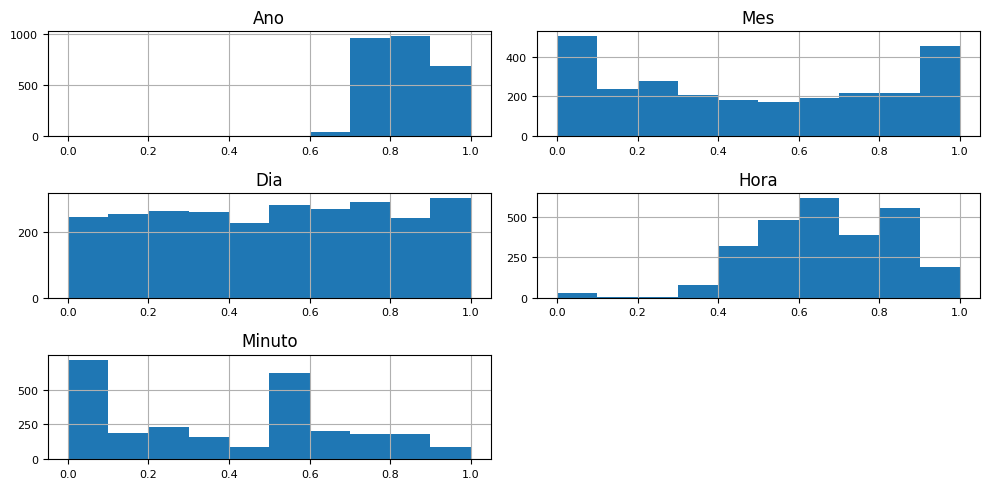

In [ ]:
# 4.1 - Atributos 'Data_da_Ocorrencia','Hora_da_Ocorrencia' (continuação)

# Plota os gráficos de histograma após a normalização

df_2[['Ano','Mes','Dia','Hora','Minuto']].hist(figsize = (10,5), xlabelsize=8, ylabelsize=8)
plt.tight_layout()
plt.plot()


## 4.2 - Dados Quantitativos

Para a análise exploratória dos dados quantitativos será feita a impresão das estatísticas descritivas e plotagem dos gráficos de histograma, boxplot antes e depois da normalização dos dados para comparação.


### 4.2.1 - Atributo - 'Lesoes'

In [ ]:
# 4.2.1 - Atributo 'Lesoes'

# Imprime as estatísticas de 'Lesoes'
print(df_2['Lesoes'].describe())

count      2655.0
mean     0.398117
std      1.055397
min           0.0
25%           0.0
50%           0.0
75%           0.0
max          14.0
Name: Lesoes, dtype: Float64


### 4.2.1 - Atributo 'Lesoes' (continuação)

As estatísticas do campo "lesoes' mostram que o conjunto de dados possui o número máximo de 14 lesões. Pelo que parece, os acidentes aéreos com a aeronave da TAM em 31/10/1996 com 99 vítimas fatais, da GOL em 29/09/2006 com 154 vítimas fatais, da TAM em 17 de julho de 2007 com 187 vítimas fatais e da Passaredo 09/08/2024 com 62 vítimas fatais foram excluídos do conjunto de dados durante a eliminação de valores nulos.

Será necessário verificar o que ocorreu e, se possível, incluir os dados desses acidentes para que o conjunto de dados contenha ocorrências aeronáuticas com aeronaves de grande porte.

In [ ]:
# 4.2.1- Atributo 'Lesoes' (continuação)

# Imprime as linhas com o número de lesões fatais maior do 40 para verificar se o conjunto de dados possui informações
# sobre os acidentes da GOL, TAM e Passaredo
df_filtrado = df.loc[df['Lesoes_Fatais_Passageiros'] > 40]
pd.set_option('display.width', None)

# Imprime os atributos correspondentes a acidentes aéreos com o número de vítimas fatais maiores do que 40
print(df_filtrado[['Operador_Padronizado','Classificacao_da_Ocorrencia','Data_da_Ocorrencia','Hora_da_Ocorrencia',
  'UF','Descricao_do_Tipo','Categoria_da_Aeronave','Operacao','Danos_a_Aeronave','Modelo','Lesoes_Fatais_Tripulantes',
  'Lesoes_Fatais_Passageiros','Lesoes_Desconhecidas_Terceiros' ]])


     Operador_Padronizado Classificacao_da_Ocorrencia Data_da_Ocorrencia  \
2383                  TAM                    Acidente         17/07/2007   
2555                  GOL                    Acidente         29/09/2006   

     Hora_da_Ocorrencia             UF  Descricao_do_Tipo  \
2383                NaN  Indeterminado  EXCURSÃO DE PISTA   
2555                NaN  Indeterminado                NaN   

     Categoria_da_Aeronave     Operacao Danos_a_Aeronave    Modelo  \
2383                   TPR  Voo Regular        Destruída  A320-233   
2555                   TPR  Voo Regular        Destruída   737-8EH   

      Lesoes_Fatais_Tripulantes  Lesoes_Fatais_Passageiros  \
2383                        6.0                      181.0   
2555                        6.0                      148.0   

      Lesoes_Desconhecidas_Terceiros  
2383                             0.0  
2555                             0.0  


4.2.1 - Atributo - 'Lesoes' (continuação)

Verifica-se na listagem acima que o conjunto de dados original possui somente os dados do acidente da da GOL em 29/09/2006 e da TAM em 17 de julho de 2007. Verifica-se o atributo 'UF' não foi preenchido corretamente. Como esses dados são conhecidos e os outros dados podem ser aproveitados, será feita a inclusão manual desses acidentes no conjunto de dados.

**OBSERVAÇÃO**: Não foram encontrados os acidentes com as aeronaves da TAM em 31/10/1996 e da Passaredo em 09/08/2024 no conjunto de dados.

In [ ]:
# 4.2.1- Atributo 'Lesoes' (continuação)

# Adiciona uma linha no conjunto de dados atual com dos dados do acidente da TAM
linha_tam = ["TAM","Acidente","SP","EXCURSÃO DE PISTA","TPR","Pouso","Voo Regular","Destruída","A320-233",187,2007,7,17,0,0]
df_2.loc[len(df_2)] = linha_tam

# Adiciona uma linha no conjunto de dados atual com dos dados do acidente da GOL
linha_gol = ["GOL","Acidente","MT","NÃO INFORMADO","TPR","Em rota","Voo Regular","Destruída","737-8EH",154,2006,9,29,0,0]
df_2.loc[len(df_2)] = linha_gol


### 4.2.1 - Atributo 'Lesoes' (continuação)

Após a inclusão dos acidentes da GOL e da TAM, verifica as estatísticas do atributo para confirmar a inclusão dos dados.

In [ ]:
# 4.2.1 - Campo 'Lesoes' (continuação)

# Verifica se as instâncias foram incluídas
df_2_filtrado = df_2.loc[df_2['Lesoes'] > 40]
pd.set_option('display.width', None)

print(df_2_filtrado[['Operador_Padronizado','Classificacao_da_Ocorrencia','Dia','Mes','Ano','Hora','Minuto',
  'Descricao_do_Tipo','Categoria_da_Aeronave',
  'UF','Operacao','Danos_a_Aeronave','Modelo','Lesoes']])


     Operador_Padronizado Classificacao_da_Ocorrencia   Dia  Mes     Ano  \
2655                  TAM                    Acidente  17.0  7.0  2007.0   
2656                  GOL                    Acidente  29.0  9.0  2006.0   

      Hora  Minuto  Descricao_do_Tipo Categoria_da_Aeronave  UF     Operacao  \
2655   0.0     0.0  EXCURSÃO DE PISTA                   TPR  SP  Voo Regular   
2656   0.0     0.0      NÃO INFORMADO                   TPR  MT  Voo Regular   

     Danos_a_Aeronave    Modelo  Lesoes  
2655        Destruída  A320-233     187  
2656        Destruída   737-8EH     154  


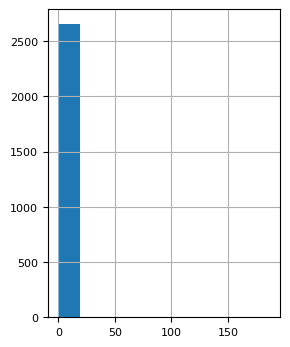

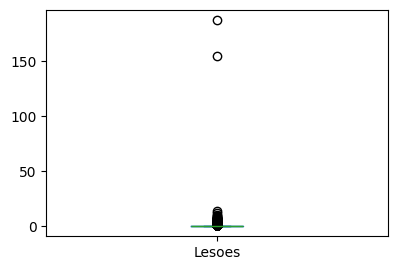

count      2657.0
mean     0.526157
std      4.805182
min           0.0
25%           0.0
50%           0.0
75%           0.0
max         187.0
Name: Lesoes, dtype: Float64


In [ ]:
# 4.2.1 - Atributo 'Lesoes' (continuação)

# Verifica as estatísticas e gráficos de histograma e boxplot para verificar como ficaram
# as estatísticas após a inclusão dos dados de 'UF'

# Plota histograma
df_2['Lesoes'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Boxplot de 'Lesoes'
df_2['Lesoes'].plot(kind = 'box', subplots = True, layout = (3,3), sharex = False, sharey = False, figsize = (15,10))
plt.show()

# Imprime estatísticas do atributo após a
print(df_2['Lesoes'].describe())


### 4.2.1 - Atributo 'Lesoes' (continuação)

Os dados estatísticos e o boxplot do atributo 'Lesoes' podem parecer estranhos pela concentração de valores entre 0 e 1 (média 0,52), mas isso se deve ao alto número de ocorrências aeronáuticas com aeronaves pequenas como ultraleves, que transportam somente uma pessoa.

Além disso, muitos valores com "0" representam ocorrências aeronáuticas com danos à aeronaves, mas sem lesões.

Com a inclusão dos dados de 'Lesoes' referentes aos acidentes da GOL e TAM, esses dados apareceram como outliers no boxplot. Para tentar corrigir esse problema, será utilizada a transformação de Escalador Robusto para tratar os outliers.

In [ ]:
# 4.2.1 - Atributo 'Lesoes' (continuação)

# Imprime estatísticas do atributo
print("\n->>> Estatísticas antes da normalização.\n")
print(df_2['Lesoes'].describe())

# Aplica a transformação de Escalador Robusto
scaler = RobustScaler()

df_2['Lesoes'] = scaler.fit_transform(df_2[['Lesoes']])

# Imprime estatísticas do atributo após a transformação do Escalador Robusto
print("\n->>> Estatísticas após a transformação de Escalador Robusto.\n")
print(df_2['Lesoes'].describe())



->>> Estatísticas antes da normalização.

count      2657.0
mean     0.526157
std      4.805182
min           0.0
25%           0.0
50%           0.0
75%           0.0
max         187.0
Name: Lesoes, dtype: Float64

->>> Estatísticas após a transformação de Escalador Robusto.

count    2657.000000
mean        0.526157
std         4.805182
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       187.000000
Name: Lesoes, dtype: float64


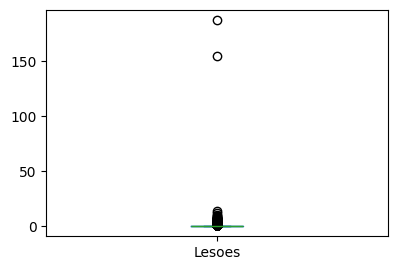

In [ ]:
# 4.2.1 - Atributo 'Lesoes' (continuação)

# Verifica o boxplot deppois da transformação

# Boxplot de 'Lesoes'
df_2['Lesoes'].plot(kind = 'box', subplots = True, layout = (3,3), sharex = False, sharey = False, figsize = (15,10))
plt.show()


### 4.2.1 - Atributo 'Lesoes' (continuação)

Como não houve alteração na média, mediana e desvio padrão após a aplicação da transformação de Escalador Robusto, será aplicada a transformação de padronização para preservar os outliers do atributo "lesoes'.

In [ ]:
# 4.2.1 - Atributo 'Lesoes' (continuação)

# Aplica a transformação de Normalização
scaler = StandardScaler()

df_2['Lesoes'] = scaler.fit_transform(df_2[['Lesoes']])

print("\n->>> Verifica o resultado após a normalização.\n")
print(df_2['Lesoes'])


->>> Verifica o resultado após a normalização.

0        0.306777
1        0.306777
2       -0.109519
3       -0.109519
4       -0.109519
          ...    
2652    -0.109519
2653    -0.109519
2654     0.098629
2655    38.814129
2656    31.945250
Name: Lesoes, Length: 2657, dtype: float64


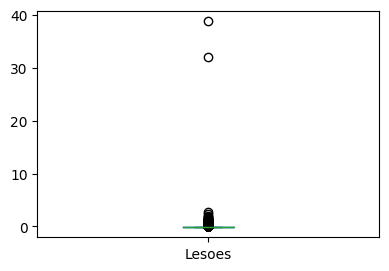

count    2.657000e+03
mean     2.674229e-18
std      1.000188e+00
min     -1.095185e-01
25%     -1.095185e-01
50%     -1.095185e-01
75%     -1.095185e-01
max      3.881413e+01
Name: Lesoes, dtype: float64


In [ ]:
# 4.2.1 - Atributo 'Lesoes' (continuação)

# Boxplot após normalização

# Boxplot de 'Lesoes'
df_2['Lesoes'].plot(kind = 'box', subplots = True, layout = (3,3), sharex = False, sharey = False, figsize = (15,10))
plt.show()

# Imprime estatísticas do atributo
print(df_2['Lesoes'].describe())


## 4.2 - Dados Categóricos

Nesta etapa os atributos do conjunto de dados com o tipo 'object' serão analisados individualmente para identificar o melhor tipo de transformação que será aplicada para possibilizar a sua utilização na etapa de aprendizado de máquina.

**OBSERVAÇÃO**: Devido ao número elevado de atributos categóricos do tipo contagem de frequência, caso não seja identificada uma transformação específica que possa ser aplicada ao atributo, será aplicada a transformação Contagem de Frequência em uma primeira etapa e em seguida a transformação de Raiz Quadrada para melhorar a distribuição. Caso não haja melhora, será utilizado outro tipo de distribuição.

### 4.2.1 - Atributo 'Classificacao_da_Ocorrencia'

O primeiro atributo a ser convertido será a variável alvo, 'Classificacao_da_Ocorrencia'. Pela distribuição de frequências verifica-se que esse atributo possui somente as opções "Acidente" e "Incidente Grave". A melhor opção é a transformação Dummy-Encoding. Seguem os valores que serão atribuídos para cada categoria:

- Acidente = "1"
- Incidente Grave = "0"

O tipo de dados do atributo 'Classificacao_da_Ocorrencia' será tranformado do tipo object para o tipo inteiro.

In [ ]:
# 4.2.1 - Atributo 'Classificacao_da_Ocorrencia'

# Conta a frequência de cada 'Operador_Padronizado'
print(df_2.groupby('Classificacao_da_Ocorrencia').size())

Classificacao_da_Ocorrencia
Acidente           1844
Incidente Grave     813
dtype: int64


In [ ]:
# 4.2.1 - Atributo 'Classificacao_da_Ocorrencia'

# Transforma os dados utilizando a transformação Dummy Encoding

# Imprime o valor de 'Classificacao_da_Ocorrencia' antes da conversão de dados
print("\n->>> Valor de 'Classificacao_da_Ocorrencia' antes da conversão de dados.\n")
print(df_2[['Classificacao_da_Ocorrencia']])

# Mapeia "Acidente" para "1" e "Incidente Grave" para "0"
df_2['Classificacao_da_Ocorrencia'] = df_2['Classificacao_da_Ocorrencia'].map({'Acidente': 1, 'Incidente Grave': 0})

# Verifica se as colunas foram transformadas corretamente
print("\n->>> Verifica se os valores de 'Classificacao_da_Ocorrencia' estão corretos.\n")
print(df_2[['Classificacao_da_Ocorrencia']])




->>> Valor de 'Classificacao_da_Ocorrencia' antes da conversão de dados.

     Classificacao_da_Ocorrencia
0                       Acidente
1                       Acidente
2                       Acidente
3                Incidente Grave
4                       Acidente
...                          ...
2652             Incidente Grave
2653                    Acidente
2654                    Acidente
2655                    Acidente
2656                    Acidente

[2657 rows x 1 columns]

->>> Verifica se os valores de 'Classificacao_da_Ocorrencia' estão corretos.

      Classificacao_da_Ocorrencia
0                               1
1                               1
2                               1
3                               0
4                               1
...                           ...
2652                            0
2653                            1
2654                            1
2655                            1
2656                            1

[2657 rows x 1 c

### 4.2.2 - 'Danos_a_Aeronave'
A listagem da contagem de frequência desse atributo indica que ele possui 5 categorias. Consultando os metadados, verifica-se que as categorias possuem uma graduação.

Será utilizada a transformação Codificação Ordinal para adequar os dados desse atributo. A categoria com a maior gravidade terá o valor "1" e de menor gravidade o valor "5" conforme descrito abaixo:

- Destruída = 1
- Substancial = 2
- Leve = 3
- Desconhecida = 4
- Nenhum = 5



In [ ]:
# 4.2.2 - Atributo 'Danos_a_Aeronave'

# Conta a frequência de cada 'Operador_Padronizado' para identificar o número de categorias
print(df_2.groupby('Danos_a_Aeronave').size())

Danos_a_Aeronave
Desconhecida      15
Destruída        250
Leve             470
Nenhum           228
Substancial     1694
dtype: int64


In [ ]:
# 4.2.2 - Atributo 'Danos_a_Aeronave' (continuação)

# Imprime o valor de 'Danos_a_Aeronave' antes da conversão de dados
print("\n->>> Valor de 'Danos_a_Aeronave' antes da conversão de dados.\n")
print(df_2[['Danos_a_Aeronave']])

# Cria a coluna 'Danos_Aeronave' em df_2
df_2['Danos_Aeronave'] = 0

# Quantifica o dano conforme o tipo de dano á aeronave
df_2.loc[df_2['Danos_a_Aeronave'] == 'Destruída', 'Danos_Aeronave'] = 1
df_2.loc[df_2['Danos_a_Aeronave'] == 'Substancial', 'Danos_Aeronave'] = 2
df_2.loc[df_2['Danos_a_Aeronave'] == 'Leve', 'Danos_Aeronave'] = 3
df_2.loc[df_2['Danos_a_Aeronave'] == 'Desconhecida', 'Danos_Aeronave'] = 4
df_2.loc[df_2['Danos_a_Aeronave'] == 'Nenhum', 'Danos_Aeronave'] = 5

# Verifica se os valores foram transformados corretamente
print("\n->>> Verifica se os valores de 'Danos_Aeronave' estão corretos.\n")
print(df_2[['Danos_Aeronave']])

# Elimina a coluna original 'Danos_a_Aeronave'
df_2 = df_2.drop(columns=['Danos_a_Aeronave'])




->>> Valor de 'Danos_a_Aeronave' antes da conversão de dados.

     Danos_a_Aeronave
0         Substancial
1           Destruída
2         Substancial
3                Leve
4         Substancial
...               ...
2652             Leve
2653      Substancial
2654      Substancial
2655        Destruída
2656        Destruída

[2657 rows x 1 columns]

->>> Verifica se os valores de 'Danos_Aeronave' estão corretos.

      Danos_Aeronave
0                  2
1                  1
2                  2
3                  3
4                  2
...              ...
2652               3
2653               2
2654               2
2655               1
2656               1

[2657 rows x 1 columns]


In [ ]:
# 4.2.2 - Atributo 'Danos_Aeronave' (continuação)

# Aplica a transformação de Escalonamento de Recursos para
# colocar todos os atributos numéricos na mesma escala
scaler = StandardScaler()

# Aplica o escalador na coluna 'Danos_Aeronave'
df_2['Danos_Aeronave'] = scaler.fit_transform(df_2[['Danos_Aeronave']])

# Imprime estatísticas do atributo após a transformação
print("\n->>> Estatísticas após a transformação.\n")
print(df_2['Danos_Aeronave'].describe())


->>> Estatísticas após a transformação.

count    2.657000e+03
mean    -1.497568e-16
std      1.000188e+00
min     -1.392293e+00
25%     -3.621279e-01
50%     -3.621279e-01
75%      6.680368e-01
max      2.728366e+00
Name: Danos_Aeronave, dtype: float64


### 4.2.2 - Atributo 'Danos_a_Aeronave' (continuação)

Verifica a distribuição desse atributo após a transformação dos dados.

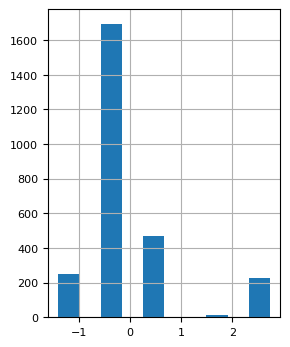

count    2.657000e+03
mean    -1.497568e-16
std      1.000188e+00
min     -1.392293e+00
25%     -3.621279e-01
50%     -3.621279e-01
75%      6.680368e-01
max      2.728366e+00
Name: Danos_Aeronave, dtype: float64


In [ ]:
# 4.2.2 - Atributo 'Danos_a_Aeronave' (continuação)

# Plota o histograma
df_2['Danos_Aeronave'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Danos_Aeronave'].describe())

### 4.2.3 - Atributo 'UF'

Para esse atributo será utilizado a metodologia One-Hot Encoding, porque o atributo não possui uma classificação que poderia ser enumerada para dar algum tipo de peso aos seus valores. Para representar os valores desse atributo serão criadas as colunas que conterão os valores binários desse atributo:

- 'UF_0'
- 'UF_1'
- 'UF_2'
- 'UF_3'
- 'UF_4'

O bit mais significativo será representado pelo atributo 'UF_4' (coluna mais a esquerda) e o bit menos significativo pelo atributo 'UF_0' (coluna mais a direita). Segue a descrição da codificação que será utilizada:

 'UF_4'- 'UF_3'- 'UF_2'- 'UF_1'- 'UF_0'
- AC = 0,0,0,0,0
- AL = 0,0,0,0,1
- AP = 0,0,0,1,0
- AM = 0,0,0,1,1
- BA = 0,0,1,0,0
- CE = 0,0,1,0,1
- DF = 0,0,1,1,0
- ES = 0,0,1,1,1
- GO = 0,1,0,0,0
- MA = 0,1,0,0,1
- MT = 0,1,0,1,0
- MS = 0,1,0,1,1
- MG = 0,1,1,0,0
- PA = 0,1,1,0,1
- PB = 0,1,1,1,0
- PR = 0,1,1,1,1
- PE = 1,0,0,0,0
- PI = 1,0,0,0,1
- RJ = 1,0,0,1,0
- RN = 1,0,0,1,1
- RS = 1,0,1,0,0
- RO = 1,0,1,0,1
- RR = 1,0,1,1,0
- SC = 1,0,1,1,1
- SP = 1,1,0,0,0
- SE = 1,1,0,0,1
- TO = 1,1,0,1,0

Após a operação de transferência de dados, a coluna 'UF' será descartada.

In [ ]:
# 4.2.3 - Atributo 'UF'

# Transforma os dados utilizando one-hot encoding

# Imprime o valor de 'UF' antes da conversão de dados
print("\n->>> Valor de 'UF' antes da conversão de dados.\n")
print(df_2[['UF']])

# Cria as colunas 'UF_4','UF_3','UF_2','UF_1','UF_0' em df_2
df_2[['UF_4','UF_3','UF_2','UF_1','UF_0']] = 0

# Carrega os bits de acordo com a sigla da 'UF'
df_2.loc[df_2['UF'] == 'AC',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,0,0,0,0]
df_2.loc[df_2['UF'] == 'AL',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,0,0,0,1]
df_2.loc[df_2['UF'] == 'AP',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,0,0,1,0]
df_2.loc[df_2['UF'] == 'AM',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,0,0,1,1]
df_2.loc[df_2['UF'] == 'BA',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,0,1,0,0]
df_2.loc[df_2['UF'] == 'CE',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,0,1,0,1]
df_2.loc[df_2['UF'] == 'DF',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,0,1,1,0]
df_2.loc[df_2['UF'] == 'ES',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,0,1,1,1]
df_2.loc[df_2['UF'] == 'GO',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,1,0,0,0]
df_2.loc[df_2['UF'] == 'MA',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,1,0,0,1]
df_2.loc[df_2['UF'] == 'MT',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,1,0,1,0]
df_2.loc[df_2['UF'] == 'MS',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,1,0,1,1]
df_2.loc[df_2['UF'] == 'MG',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,1,1,0,0]
df_2.loc[df_2['UF'] == 'PA',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,1,1,0,1]
df_2.loc[df_2['UF'] == 'PB',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,1,1,1,0]
df_2.loc[df_2['UF'] == 'PR',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [0,1,1,1,1]
df_2.loc[df_2['UF'] == 'PE',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,0,0,0,0]
df_2.loc[df_2['UF'] == 'PI',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,0,0,0,1]
df_2.loc[df_2['UF'] == 'RJ',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,0,0,1,0]
df_2.loc[df_2['UF'] == 'RN',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,0,0,1,1]
df_2.loc[df_2['UF'] == 'RS',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,0,1,0,0]
df_2.loc[df_2['UF'] == 'RO',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,0,1,0,1]
df_2.loc[df_2['UF'] == 'RR',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,0,1,1,0]
df_2.loc[df_2['UF'] == 'SC',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,0,1,1,1]
df_2.loc[df_2['UF'] == 'SP',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,1,0,0,0]
df_2.loc[df_2['UF'] == 'SE',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,1,0,0,1]
df_2.loc[df_2['UF'] == 'TO',['UF_4','UF_3','UF_2','UF_1','UF_0']] = [1,1,0,1,0]

# Verifica se as colunas foram transformadas corretamente
print("\n->>> Verifica se os valores de 'UF' estão corretos.\n")

#pd.set_option('display.max_rows', None)
print(df_2[['UF_4','UF_3','UF_2','UF_1','UF_0']])

# Elimina as colunas originais de 'Danos_a_Aeronave'
df_2 = df_2.drop(columns=['UF'])




->>> Valor de 'UF' antes da conversão de dados.

      UF
0     RS
1     RJ
2     GO
3     MG
4     PA
...   ..
2652  RS
2653  RS
2654  AM
2655  SP
2656  MT

[2657 rows x 1 columns]

->>> Verifica se os valores de 'UF' estão corretos.

      UF_4  UF_3  UF_2  UF_1  UF_0
0        1     0     1     0     0
1        1     0     0     1     0
2        0     1     0     0     0
3        0     1     1     0     0
4        0     1     1     0     1
...    ...   ...   ...   ...   ...
2652     1     0     1     0     0
2653     1     0     1     0     0
2654     0     0     0     1     1
2655     1     1     0     0     0
2656     0     1     0     1     0

[2657 rows x 5 columns]


### 4.2.4 - Atributo 'Operador_Padronizado'

Será utilizada a transformação de Contagem de Frequência para esse atributo.



In [ ]:
# 4.2.4 - Atributo 'Operador_Padronizado'

# Aplica a transformação de Contagem de Frequência

print("\n->>> Valores do campo 'Operador_Padronizado' antes da transformação dos dados.\n")
print(df_2['Operador_Padronizado'])

# Calcula frequências relativas
frequencia = df_2['Operador_Padronizado'].value_counts(normalize=True)

# Substitui os valores na coluna original pela porcentagem calculada
df_2['Operador_Padronizado'] = df_2['Operador_Padronizado'].map(frequencia)

# Imprime os valores normalizados
print("\n->>> Valores do campo 'Operador_Padronizado' após a transformação dos dados.\n")
print(df_2['Operador_Padronizado'])



->>> Valores do campo 'Operador_Padronizado' antes da transformação dos dados.

0             AERO AGRICOLA SANTOS DUMONT LTDA
1       SKY CLEAR ESCOLA DE AVIACAO CIVIL LTDA
2                          JOAO TELMO POZZOBON
3       FRISONFLY ESCOLA DE AVIACAO CIVIL LTDA
4           PENA AGRO-FLORESTAL MADEREIRA LTDA
                         ...                  
2652            PLA & SILVA AVIACAO AGRIC.LTDA
2653                    FERNANDO ANTONIO COSTA
2654                 JHONATA DO PRADO DE FARIA
2655                                       TAM
2656                                       GOL
Name: Operador_Padronizado, Length: 2657, dtype: object

->>> Valores do campo 'Operador_Padronizado' após a transformação dos dados.

0       0.000753
1       0.000753
2       0.000376
3       0.001882
4       0.000753
          ...   
2652    0.000753
2653    0.000376
2654    0.000376
2655    0.005269
2656    0.004893
Name: Operador_Padronizado, Length: 2657, dtype: float64


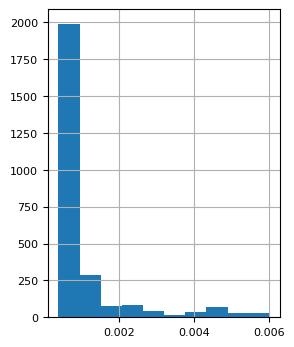

In [ ]:
# 4.2.4 - Atributo 'Operador_Padronizado' (continuação)

# Verifica o histograma antes da transformação

# Plota o histograma
df_2['Operador_Padronizado'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()


### 4.2.4 - Atributo 'Operador_Padronizado' (continuação)

Aplica a transformação de Raiz Quadrada para tentar melhorar a distribuição do atribuito, que possui uma cauda londa à direita. Essa distribuição se deve ao grande número de proprietários de pequenas aeonaves.

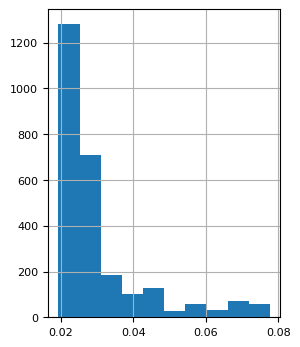

count    2657.000000
mean        0.028794
std         0.013759
min         0.019400
25%         0.019400
50%         0.027436
75%         0.033602
max         0.077600
Name: Operador_Padronizado, dtype: float64


In [ ]:
# 4.2.4 - Atributo 'Operador_Padronizado' (continuação)

# Verifica o histograma e dados estatísticos após a transformação

df_2['Operador_Padronizado'] = np.sqrt(df_2['Operador_Padronizado'])

# Plota o histograma
df_2['Operador_Padronizado'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Operador_Padronizado'].describe())

Como a transformação melhorou a distribuição, ela será mantida.

### 4.2.5 - Atributo - 'Fase_da_Operacao'

Será utilizada a transformação de Contagem de Frequência para esse atributo.

In [ ]:
# 4.2.5 - Atributo 'Fase_da_Operacao'

# Conta a frequência de cada 'Fase_da_Operacao' para identificar o número de categorias
print(df_2.groupby('Fase_da_Operacao').size())

Fase_da_Operacao
Aproximação                 101
Arremetida                   41
Cheque de motor ou rotor      2
Circuto de Tráfego           49
Corrida após pouso          347
                           ... 
Reta Final                    5
Saída IFR                     3
Subida                      116
Táxi                         49
Voo a baixa altura           58
Length: 27, dtype: int64


In [ ]:
# 4.2.5 - Atributo 'Fase_da_Operacao'

# Aplica a transformação de Contagem de Frequência

print("\n->>> Valores do campo 'Fase_da_Operacao' antes da transformação dos dados.\n")
print(df_2['Fase_da_Operacao'])

# Calcula frequências relativas
frequencia = df_2['Fase_da_Operacao'].value_counts(normalize=True)

# Substitui os valores na coluna original pela porcentagem calculada
df_2['Fase_da_Operacao'] = df_2['Fase_da_Operacao'].map(frequencia)

# Imprime os valores normalizados
print("\n->>> Valores do campo 'Fase_da_Operacao' após a transformação dos dados.\n")
print(df_2['Fase_da_Operacao'])

#df_2.info()


->>> Valores do campo 'Fase_da_Operacao' antes da transformação dos dados.

0       Circuto de Tráfego
1                  Em rota
2                Decolagem
3       Voo a baixa altura
4                Decolagem
               ...        
2652    Voo a baixa altura
2653            Arremetida
2654         Indeterminada
2655                 Pouso
2656               Em rota
Name: Fase_da_Operacao, Length: 2657, dtype: object

->>> Valores do campo 'Fase_da_Operacao' após a transformação dos dados.

0       0.018442
1       0.117802
2       0.162589
3       0.021829
4       0.162589
          ...   
2652    0.021829
2653    0.015431
2654    0.023711
2655    0.217539
2656    0.117802
Name: Fase_da_Operacao, Length: 2657, dtype: float64


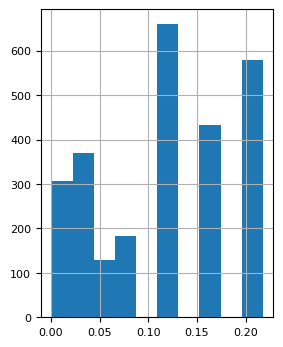

In [ ]:
# 4.2.5 - Atributo 'Fase_da_Operacao' (continuação)

# Verifica o histograma antes da transformação

# Plota o histograma
df_2['Fase_da_Operacao'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()


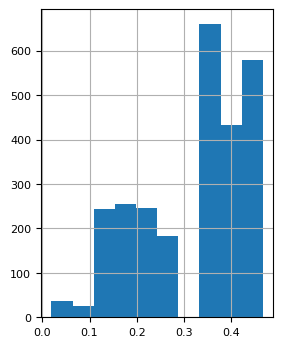

count    2657.000000
mean        0.323375
std         0.118331
min         0.019400
25%         0.208946
50%         0.361384
75%         0.403224
max         0.466410
Name: Fase_da_Operacao, dtype: float64


In [ ]:
# 4.2.5 - Atributo 'Fase_da_Operacao' (continuação)

# Aplica a transformação de Raiz Quadrada para entar melhorar a distribuição do atribuito
# Verifica o histograma e dados estatísticos após a transformação

df_2['Fase_da_Operacao'] = np.sqrt(df_2['Fase_da_Operacao'])

# Plota o histograma
df_2['Fase_da_Operacao'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Fase_da_Operacao'].describe())

Como a transformação melhorou a distribuição, ela será mantida.

### 4.2.6 - Atributo 'Categoria_da_Aeronave'

Será utilizada a transformação de Contagem de Frequência para esse atributo.

In [ ]:
# 4.2.6 - Atributo 'Categoria_da_Aeronave'

# Conta a frequência de cada 'Categoria_da_Aeronave' para identificar o número de categorias
print(df_2.groupby('Operacao').size())

Operacao
Desconhecida                 1
Operação Agrícola          538
Operação Especializada      40
Operação Policial           23
Operação Pública            59
                          ... 
Voo Experimental            45
Voo Privado               1274
Voo Regular                 67
Voo de Instrução           386
Voo não regular             18
Length: 11, dtype: int64


In [ ]:
# 4.2.6 - Atributo 'Categoria_da_Aeronave'

# Aplica a transformação de contagem de frequência

print("\n->>> Valores antes da transformação dos dados.\n")
print(df_2['Categoria_da_Aeronave'])

# Calcula frequências relativas
frequencia = df_2['Categoria_da_Aeronave'].value_counts(normalize=True)

# Substitui os valores na coluna original pela porcentagem calculada
df_2['Categoria_da_Aeronave'] = df_2['Categoria_da_Aeronave'].map(frequencia)

# Imprime os valores normalizados
print("\n->>> Valores após a transformação dos dados.\n")
print(df_2['Categoria_da_Aeronave'])



->>> Valores antes da transformação dos dados.

0       PRI
1       PRI
2       TPP
3       PRI
4       TPP
       ... 
2652    S05
2653    TPP
2654    AMD
2655    TPR
2656    TPR
Name: Categoria_da_Aeronave, Length: 2657, dtype: object

->>> Valores após a transformação dos dados.

0       0.147535
1       0.147535
2       0.390666
3       0.147535
4       0.390666
          ...   
2652    0.124953
2653    0.390666
2654    0.016936
2655    0.025969
2656    0.025969
Name: Categoria_da_Aeronave, Length: 2657, dtype: float64


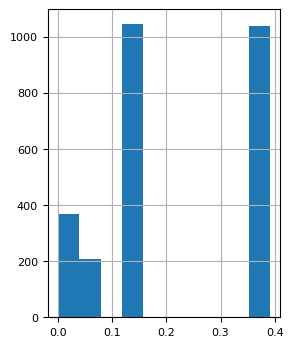

count    2657.000000
mean        0.212982
std         0.147369
min         0.000376
25%         0.120813
50%         0.147535
75%         0.390666
max         0.390666
Name: Categoria_da_Aeronave, dtype: float64


In [ ]:
# 4.2.6 - Atributo 'Categoria_da_Aeronave' (continuação)

# Verifica o histograma antes da transformação

# Plota o histograma
df_2['Categoria_da_Aeronave'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Categoria_da_Aeronave'].describe())

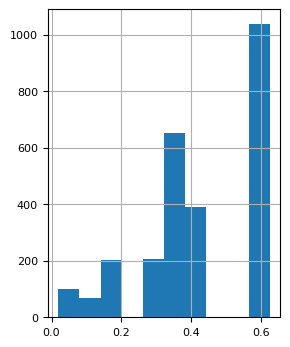

count    2657.000000
mean        0.425298
std         0.179207
min         0.019400
25%         0.347582
50%         0.384103
75%         0.625033
max         0.625033
Name: Categoria_da_Aeronave, dtype: float64


In [ ]:
# 4.2.6 - Atributo 'Categoria_da_Aeronave' (continuação)

# Aplica a Transformação de Raiz Quadrada para tentar melhorar a distribuição do atribuito
# Verifica o histograma e dados estatísticos após a transformação

df_2['Categoria_da_Aeronave'] = np.sqrt(df_2['Categoria_da_Aeronave'])

# Plota o histograma
df_2['Categoria_da_Aeronave'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Categoria_da_Aeronave'].describe())

Como a transformação melhorou a distribuição, ela será mantida.

### 4.2.6 - Atributo 'Categoria_da_Aeronave' (continuação)

A aplicação da Transformação de Raiz Quadrada melhorou a distribuição do atributo e será mantida.

### 4.2.7 - Atributo - 'Operacao'

Será utilizada a transformação de Contagem de Frequência para esse atributo.

In [ ]:
# 4.2.7 - Atributo 'Operacao'

# Conta a frequência de cada 'Operacao' para identificar o número de categorias
print(df_2.groupby('Operacao').size())

Operacao
Desconhecida                 1
Operação Agrícola          538
Operação Especializada      40
Operação Policial           23
Operação Pública            59
                          ... 
Voo Experimental            45
Voo Privado               1274
Voo Regular                 67
Voo de Instrução           386
Voo não regular             18
Length: 11, dtype: int64


In [ ]:
# 4.2.7 - Atributo 'Operacao'

# Transforma os dados utilizando a técnica de contagem de frequência

print("\n->>> Valores do campo 'Operacao' antes da transformação dos dados.\n")
print(df_2['Operacao'])

# Calcula frequências relativas
frequencia = df_2['Operacao'].value_counts(normalize=True)

# Substitui os valores na coluna original pela porcentagem calculada
df_2['Operacao'] = df_2['Operacao'].map(frequencia)

# Imprime os valores após a transformação
print("\n->>> Valores do campo 'Operacao' após a tranformação dos dados.\n")
print(df_2['Operacao'])

#print(df_2.info())


->>> Valores do campo 'Operacao' antes da transformação dos dados.

0        Voo de Instrução
1        Voo de Instrução
2             Voo Privado
3        Voo de Instrução
4             Voo Privado
              ...        
2652    Operação Agrícola
2653          Voo Privado
2654     Voo Experimental
2655          Voo Regular
2656          Voo Regular
Name: Operacao, Length: 2657, dtype: object

->>> Valores do campo 'Operacao' após a tranformação dos dados.

0       0.145277
1       0.145277
2       0.479488
3       0.145277
4       0.479488
          ...   
2652    0.202484
2653    0.479488
2654    0.016936
2655    0.025216
2656    0.025216
Name: Operacao, Length: 2657, dtype: float64


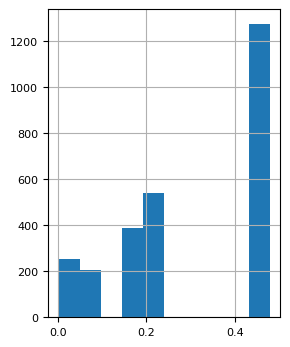

count    2657.000000
mean        0.299788
std         0.179577
min         0.000376
25%         0.145277
50%         0.202484
75%         0.479488
max         0.479488
Name: Operacao, dtype: float64


In [ ]:
# 4.2.7 - Atributo 'Categoria_da_Aeronave' (continuação)

# Verifica o histograma após da transformação

# Plota o histograma
df_2['Operacao'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Operacao'].describe())

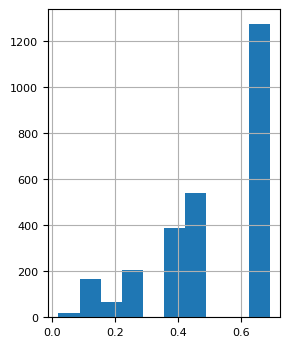

count    2657.000000
mean        0.512831
std         0.191849
min         0.019400
25%         0.381152
50%         0.449982
75%         0.692451
max         0.692451
Name: Operacao, dtype: float64


In [ ]:
# 4.2.7 - Atributo 'Operacao' (continuação)

# Aplica a Transformação de Raiz Quadrada para tentar melhorar a distribuição do atribuito
# Verifica o histograma e dados estatísticos após a transformação

df_2['Operacao'] = np.sqrt(df_2['Operacao'])

# Plota o histograma
df_2['Operacao'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Operacao'].describe())

### 4.2.7 - Atributo 'Operacao' (continuação)
A aplicação da Transformação de Raiz Quadrada melhorou a distribuição do atributo e será mantida.

### 4.2.8 - Atributo 'Descricao_do_Tipo'

Será utilizada a transformação de Contagem de Frequência para esse atributo.

In [ ]:
# 4.2.8 - Atributo 'Descricao_do_Tipo'

# Conta a frequência de cada 'Descricao_do_Tipo' para identificar o número de categorias
print(df_2.groupby('Descricao_do_Tipo').size())

Descricao_do_Tipo
AERÓDROMO                                              7
COLISÃO COM AVE                                        9
COLISÃO COM FAUNA                                     10
COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO    151
COLISÃO NO SOLO                                       41
                                                    ... 
PERDA DE SEPARAÇÃO / COLISÃO EM VOO                   39
POUSO AQUÉM/ALÉM DA PISTA                             17
RELACIONADO COM SECURITY                               3
TURBULÊNCIA                                            2
VOO CONTROLADO CONTRA O TERRENO                       30
Length: 32, dtype: int64


In [ ]:
# 4.2.8 - Atributo 'Descricao_do_Tipo'

# Transforma os dados utilizando a técnica de contagem de frequência

print("\n->>> Valores antes da transformação dos dados.\n")
print(df_2['Descricao_do_Tipo'])

# Calcula frequências relativas
frequencia = df_2['Descricao_do_Tipo'].value_counts(normalize=True)

# Substitui os valores na coluna original pela porcentagem calculada
df_2['Descricao_do_Tipo'] = df_2['Descricao_do_Tipo'].map(frequencia)

# Imprime os valores normalizados
print("\n->>> Valores após a tranformação dos dados.\n")
print(df_2['Descricao_do_Tipo'])



->>> Valores antes da transformação dos dados.

0       FALHA OU MAU FUNCIONAMENTO DE SISTEMA / COMPONENTE
1        COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO
2                                PERDA DE CONTROLE NO SOLO
3        COLISÃO COM OBSTÁCULO DURANTE A DECOLAGEM E POUSO
4                                        EXCURSÃO DE PISTA
                               ...                        
2652                                       COLISÃO COM AVE
2653                   FALHA OU MAU FUNCIONAMENTO DO MOTOR
2654                                         INDETERMINADO
2655                                     EXCURSÃO DE PISTA
2656                                         NÃO INFORMADO
Name: Descricao_do_Tipo, Length: 2657, dtype: object

->>> Valores após a tranformação dos dados.

0       0.105006
1       0.056831
2       0.113286
3       0.056831
4       0.147535
          ...   
2652    0.003387
2653    0.176891
2654    0.034249
2655    0.147535
2656    0.000376
Name: Descricao_

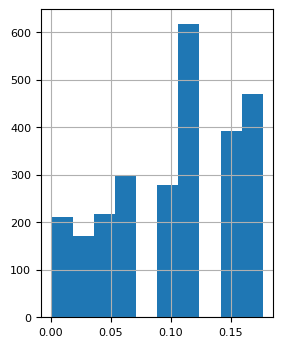

count    2657.000000
mean        0.103610
std         0.053709
min         0.000376
25%         0.056078
50%         0.113286
75%         0.147535
max         0.176891
Name: Descricao_do_Tipo, dtype: float64


In [ ]:
# 4.2.8 - Atributo 'Categoria_da_Aeronave' (continuação)

# Verifica o histograma e dados estatísticos após a transformação

# Plota o histograma
df_2['Descricao_do_Tipo'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Descricao_do_Tipo'].describe())

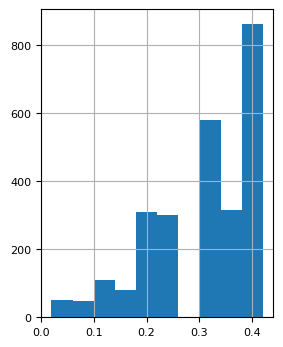

count    2657.000000
mean        0.306242
std         0.099141
min         0.019400
25%         0.236809
50%         0.336579
75%         0.384103
max         0.420584
Name: Descricao_do_Tipo, dtype: float64


In [ ]:
# 4.2.8 - Atributo 'Descricao_do_Tipo'

# Aplica a Transformação de Raiz Quadrada para entar melhorar a distribuição do atribuito
# Verifica o histograma e dados estatísticos após a transformação

df_2['Descricao_do_Tipo'] = np.sqrt(df_2['Descricao_do_Tipo'])
#df_2['Descricao_do_Tipo'] = np.log(df_2['Descricao_do_Tipo'])

# Plota o histograma
df_2['Descricao_do_Tipo'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Descricao_do_Tipo'].describe())

### 4.2.8 - Atributo 'Descricao_do_Tipo'
A aplicação da Transformação de Raiz Quadrada melhorou a distribuição do atributo e será mantida.

### 4.2.9 - Atributo 'Modelo'

Para esse atributo será utilizado a transformação de Contagem de Frequência. O atributo possui uma contagem muito alta devido ao número de proprietários (operadores) de aeronaves pequenas como ultraleves.


In [ ]:
# 4.2.9 - Atributo 'Modelo'

# Conta a frequência de cada 'Modelo' para identificar o número de categorias
print(df_2.groupby('Modelo').size())

Modelo
1124A            4
114              1
120              2
140              1
140A             1
                ..
YPIRANGA         1
ZENAIR CH 701    1
ZENITH CH 701    1
ZODIAC CH-640    1
conquest 180     2
Length: 540, dtype: int64


In [ ]:
# 4.2.9 - Atributo 'Modelo'

# Aplpica a transformção de Contagem de Frequência

print("\n->>> Valores antes da normalização dos dados.\n")
print(df_2['Modelo'])

# Calcula frequências relativas
frequencia = df_2['Modelo'].value_counts(normalize=True)

# Substitui os valores na coluna original pela porcentagem calculada
df_2['Modelo'] = df_2['Modelo'].map(frequencia)

# Imprime os valores normalizados
print("\n->>> Valores após a normalização dos dados.\n")
print(df_2['Modelo'])



->>> Valores antes da normalização dos dados.

0                140
1           R22 BETA
2               SR22
3           R22 BETA
4        PA-46-500TP
            ...     
2652           A188B
2653    PA-32-301XTC
2654           RV-10
2655        A320-233
2656         737-8EH
Name: Modelo, Length: 2657, dtype: object

->>> Valores após a normalização dos dados.

0       0.000376
1       0.010162
2       0.016184
3       0.010162
4       0.003764
          ...   
2652    0.028604
2653    0.000376
2654    0.012796
2655    0.000376
2656    0.003387
Name: Modelo, Length: 2657, dtype: float64


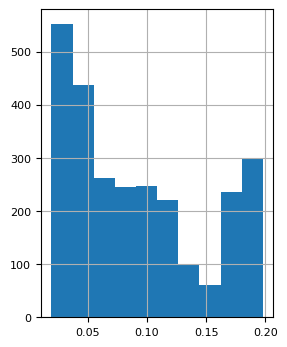

count    2657.000000
mean        0.091057
std         0.057928
min         0.019400
25%         0.038800
50%         0.077600
75%         0.127215
max         0.197843
Name: Modelo, dtype: float64


In [ ]:
# 4.2.9 - Atributo 'Modelo' (continuação)

# Verifica o histograma e dados estatísticos após a transformação

df_2['Modelo'] = np.sqrt(df_2['Modelo'])

# Plota o histograma
df_2['Modelo'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Modelo'].describe())

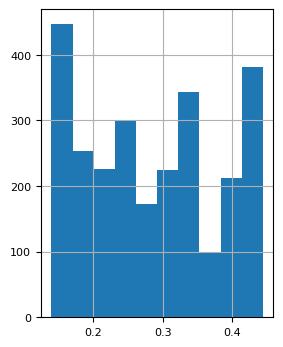

count    2657.000000
mean        0.285362
std         0.098126
min         0.139284
25%         0.196978
50%         0.278569
75%         0.356672
max         0.444796
Name: Modelo, dtype: float64


In [ ]:
# 4.2.9 - Atributo 'Modelo' (continuação)

# Aplica a Transformação de Raiz Quadrada para entar melhorar a distribuição do atribuito
# Verifica o histograma e dados estatísticos após a transformação

df_2['Modelo'] = np.sqrt(df_2['Modelo'])

# Plota o histograma
df_2['Modelo'].hist(figsize = (3,4), xlabelsize=8, ylabelsize=8)
plt.show()

# Imprime estatísticas do atributo
print(df_2['Modelo'].describe())

### 4.2.9 - Atributo 'Modelo' (continuação)
A aplicação da Transformação de Raiz Quadrada melhorou a distribuição do atributo e será mantida.

# 5 - Balanceamento da Variável Alvo

Pela gráfico de barras de contagem de frequência da variável alvo 'Classificacao_da_Ocorrencia' verifica-se um desbalanceamento ocasionado por um maior número de acidentes (1844) do que incidentes graves (813), que são explicados pelos requisitos de classificação desse atributo. Mesmo que não haja vítimas em uma ocorrência aeronáutica, pela classificação da ANAC, uma ocorrência aeronáutica pode ser considerada como um acidente se houver danos consideráveis à aeronave.

Será necessário aplicar o balanceamento no conjunto de dados para prepará-lo para a etapa de aprendizado de máquina.


## 5.2 - Distribuição de Frequências Antes do Balanceamento

In [ ]:
# 5.2 - Balanceamento da Variável Alvo (continuação)

print("\n->>> Distribuição de frequências da variável alvo antes do balanceamento.\n")

print(df_2.groupby('Classificacao_da_Ocorrencia').size())


->>> Distribuição de frequências da variável alvo antes do balanceamento.

Classificacao_da_Ocorrencia
0     813
1    1844
dtype: int64


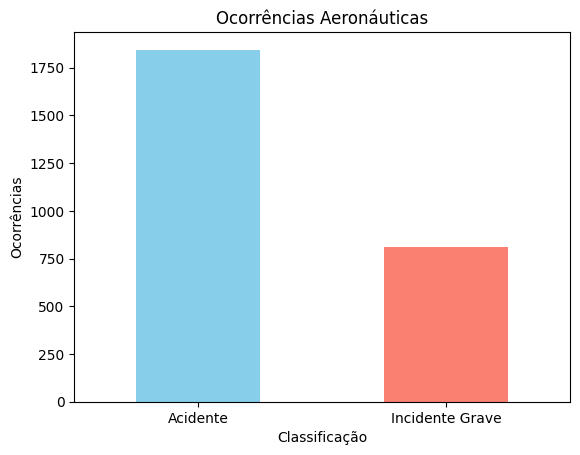

In [ ]:
# 5.2 - Balanceamento da Variável Alvo (continuação)

contagem = df_2['Classificacao_da_Ocorrencia'].value_counts()

# Plota o gráfico de barras
contagem.plot(kind='bar', color=['skyblue', 'salmon'], rot=0)

# Configurações do gráfico
plt.title('Ocorrências Aeronáuticas')
plt.xlabel('Classificação')
plt.ylabel('Ocorrências')
plt.xticks([0, 1], ['Acidente', 'Incidente Grave'])

plt.show()

## 5.2 - Distribuição de Frequências Depois do Balanceamento

Como conjunto de dados possui um numero razoável de instâncias, será aplicada a técnica de Subamostragem (Undersampling) para equilibrar os conjuntos de dados desbalanceados reduzindo o número de observações da classe majoritária.

In [ ]:
# 5.2 - Distribuição de Frequências Depois do Balanceamento

# Classes minoritária e majoritária
df_minority_class = df_2[df_2['Classificacao_da_Ocorrencia'] == 0]
df_majority_class = df_2[df_2['Classificacao_da_Ocorrencia'] == 1]

# Amplica o algorítmo de subamostragem na classe majoritária para o tamanho da classe minoritária
df_majority_downsampled = resample(df_majority_class,
                                 replace=False,
                                 n_samples=len(df_minority_class),
                                 random_state=42)

# Combina as classes
df_balanceado = pd.concat([df_majority_downsampled, df_minority_class])
print("\n->>> Número de instâncias de cada classe após balancemento.\n")
print(df_balanceado['Classificacao_da_Ocorrencia'].value_counts())




->>> Número de instâncias de cada classe após balancemento.

Classificacao_da_Ocorrencia
1    813
0    813
Name: count, dtype: int64


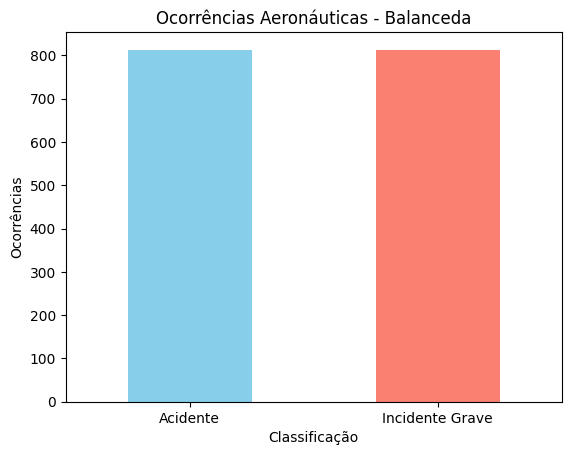

In [ ]:
# 5.2 - Balanceamento da Variável Alvo (continuação)

# Contagem de frequências do tipo de ocorrência aeronáutica
contagem = df_balanceado['Classificacao_da_Ocorrencia'].value_counts()

# Plota o gráfico de barras
contagem.plot(kind='bar', color=['skyblue', 'salmon'], rot=0)

# Configurações do gráfico
plt.title('Ocorrências Aeronáuticas - Balanceda')
plt.xlabel('Classificação')
plt.ylabel('Ocorrências')
plt.xticks([0, 1], ['Acidente', 'Incidente Grave'])

plt.show()


# 6.0 - Análise dos Resultados

Segue a comparação dos gráficos de histograma, densidade, boxplot e matriz de correlação dos atributos antes e depois da aplicação do algorítmo de balanceamento.

## 6.1 - Plotagem dos Gráficos

### 6.1.1 - Histogramas

A comparação dos gráficos de histograma antes e depois do balancemento não mostra variação indicando que o balancemento manteve o formato das distribuições dos atributos, apesar da exclusão de 1031 instâncias do conjunto de dados.

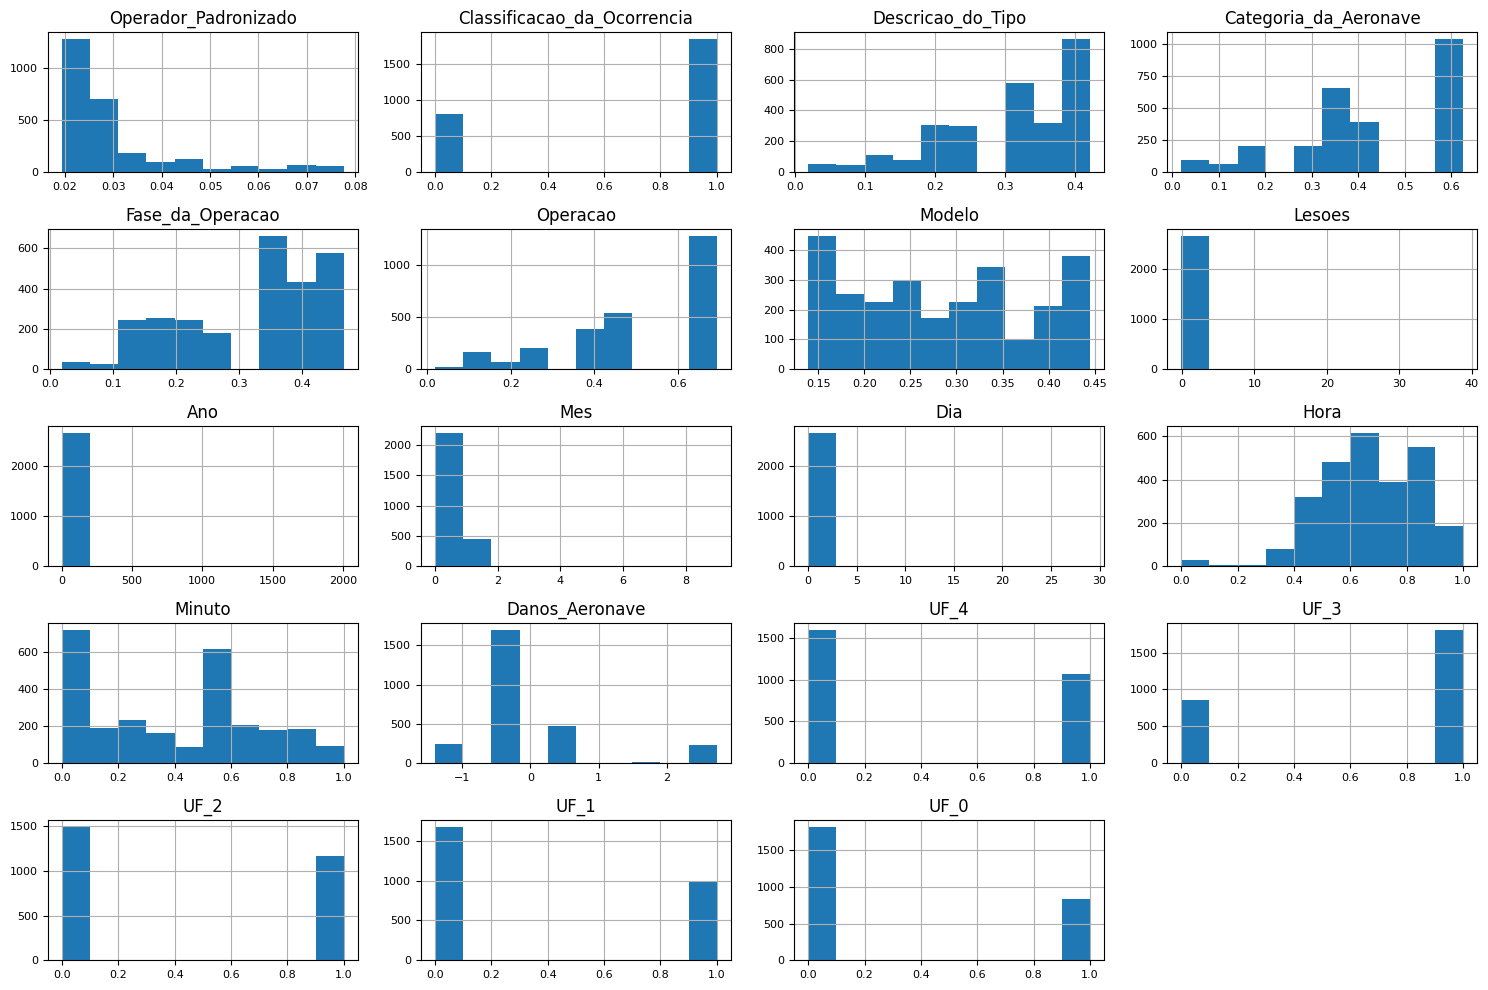

In [ ]:
# 6.1.1 - Histogramas

# Antes do Balanceamento

df_2.hist(figsize = (15,10), xlabelsize=8, ylabelsize=8)
plt.tight_layout()
plt.show()

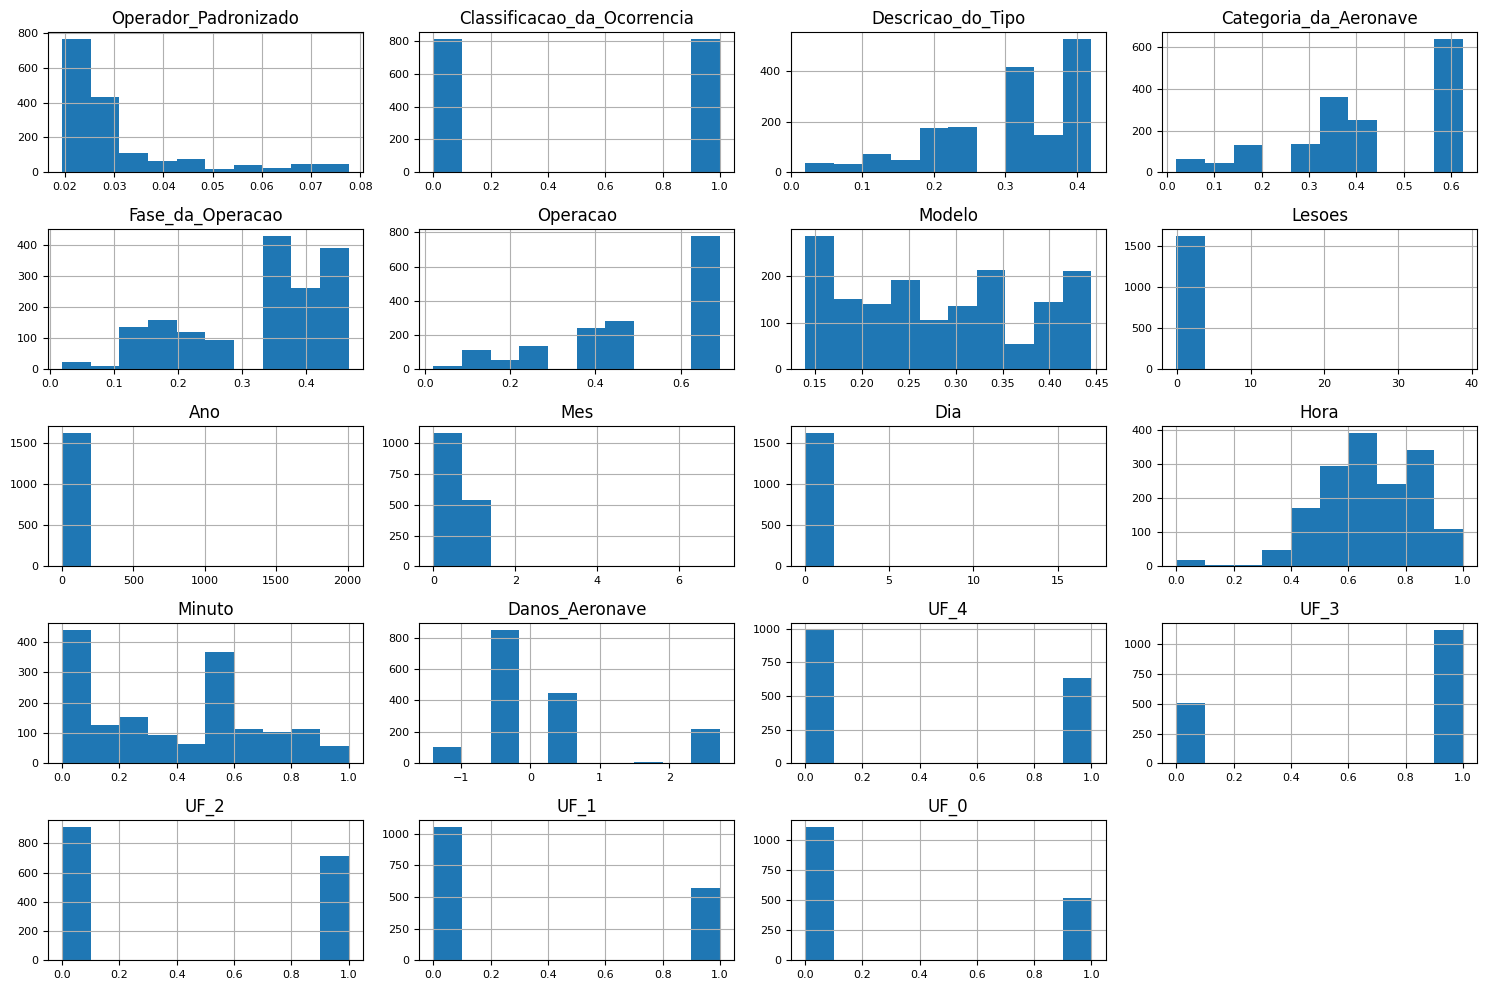

In [ ]:
# 6.1.1 - Histogramas

# Depois do Balanceamento

df_balanceado.hist(figsize = (15,10), xlabelsize=8, ylabelsize=8)
plt.tight_layout()
plt.show()

### 6.1.1 - Insights

Segue um insight (item 1) e um possível insight (item 2) encontrados na analise dos histogramas:

- 1 - Observou-se que entre os meses de novembro e fevereiro ocorrem mais ocorrências aeronáuticas no Brasil do que nos outros meses.

Segue o que foi encontrado na internet sobre a afirmação: "Os acidentes aéreos no Brasil ocorrem com maior frequência entre os meses de novembro de fevereiro."

**COMENTÁRIO**: É correto afirmar que os acidentes aéreos no Brasil têm uma incidência maior ou relevante durante o verão, compreendido entre os meses de novembro e fevereiro.

Principais Fatores da Alta Incidência no Período:

Meteorologia: O período de novembro a fevereiro corresponde ao verão brasileiro, caracterizado por chuvas intensas, tempestades, alta nebulosidade e formação de granizo, fatores que complicam significativamente as operações aéreas, especialmente a aviação de pequeno porte.

Aumento de Tráfego: Há um aumento no número de aeronaves em circulação, incluindo voos particulares e comerciais para destinos turísticos, o que estatisticamente aumenta o risco.

Acidentes Recentes: O início de 2025 (janeiro e fevereiro) registrou uma concentração de ocorrências, com 30 acidentes aéreos, resultando em 12 mortes e dezenas de incidentes graves. O ano de 2024 também fechou com recordes negativos de acidentes, superando anos anteriores.

Aviação Geral/Privada: A maior parte dos acidentes no Brasil, especialmente no período de verão, envolve aviões de pequeno porte e particulares.

- 2 - Outro possível insight foi encontrado no atributo 'Hora'. Pelo verificado no histograma, a maior ocorrência de acidentes aéreos se dá entre 06:00 e 23:00 h. A hipótese mais provável é que não hajam muitos voos durante o período da madrugada contribuindo para baixo número de ocorrências aeronáuticas.

Segue o que foi encontrado na internet sobre a afirmação: "Os acidentes aéros no brasil ocorrem na sua maioria no horário de 00:00 às 06:00.

**COMENTÁRIO**: A afirmação de que a maioria dos acidentes aéreos no Brasil ocorre entre 00:00 e 06:00 não é confirmada pelos dados gerais de acidentes aeronáuticos brasileiros (que incluem aviação geral, executiva e agrícola), embora exista um risco aumentado de falhas humanas (erros operacionais) nesse período, conhecido como "corujão"

### 6.2.2 - Gráficos de Densidade

Como os gráficos de densidade apresentam as mesmas informações dos histogramas de uma forma suavizada. Os comentários são os mesmo dos histogramas.



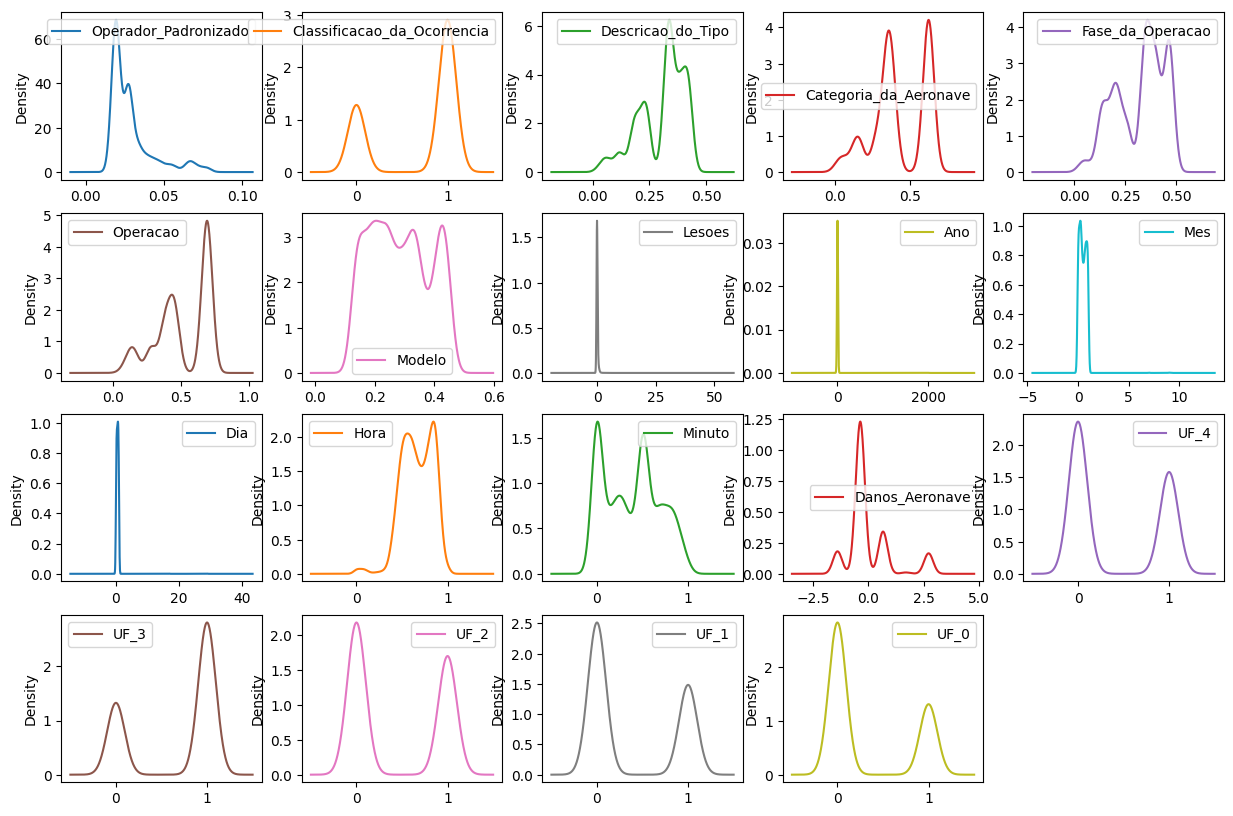

In [ ]:
# 6.1.1 - Gráfico de Densidade

# Antes do Balanceamento

df_2.plot(kind = 'density', subplots = True, layout = (4,5), sharex = False, figsize = (15,10))
plt.show()

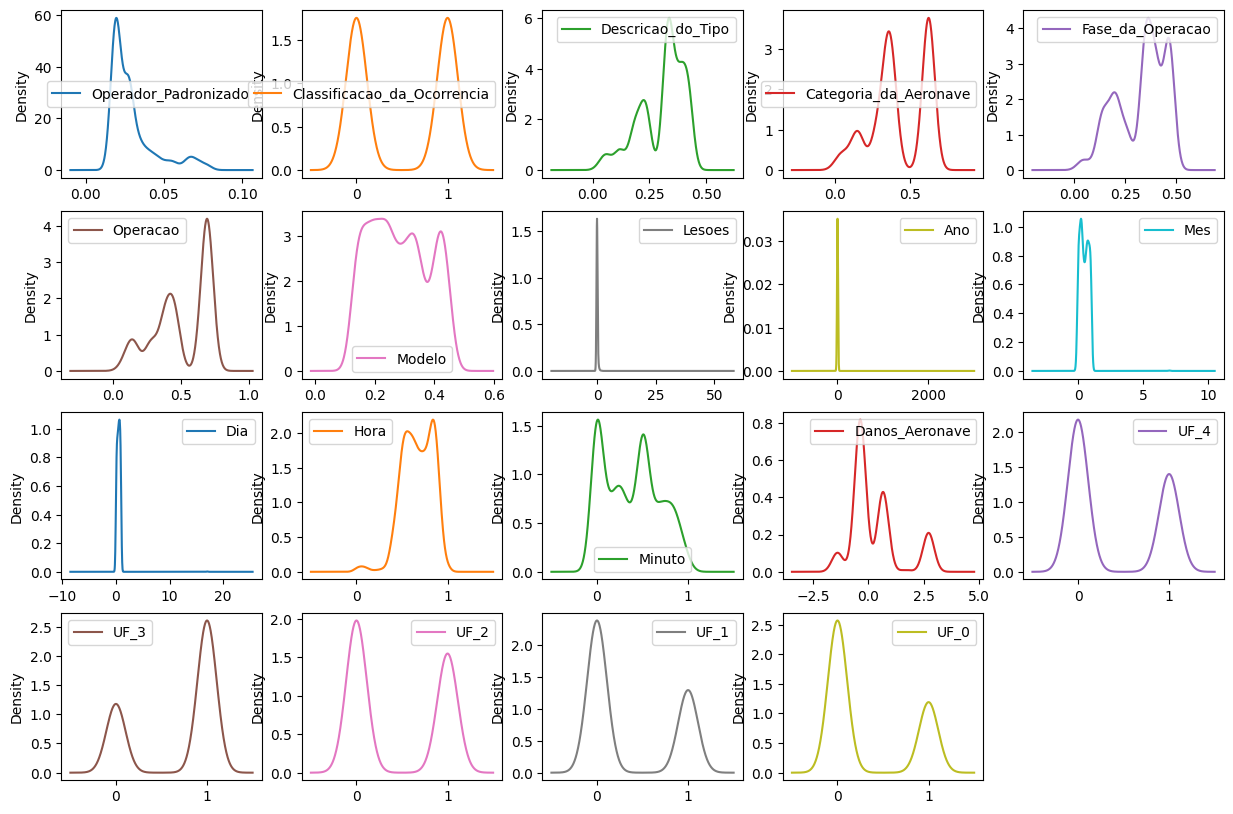

In [ ]:
# 6.2.2 - Gráfico de Densidade

# Depois o Balanceamento

df_balanceado.plot(kind = 'density', subplots = True, layout = (4,5), sharex = False, figsize = (15,10))
plt.show()

### 6.2.3 - Boxplot

A comparação dos atributos com os gráficos de boxplop mostram pequenas alterações em alguns atributos descritas a seguir.

- O atributo alvo 'Classificação_da_Ocorrencia' ficou equilibrado após o balanceamento, como era de se esperar.
- A distribuição do atributo 'Lesoes' permaneceu quase a mesma. Antes do balancemento havia 2 outliers, que foram as ocorrências da GOL e da TAM recuperadas manualmente durante a fase de tratamento dos dados. Após o balanceamento, a ocorrência da TAM foi removida do conjunto de dados.
- O atributo 'Dia' apresentava 2 atributos e ao final do balanceamento, ficou com 4.
- O atributo 'Hora' apresentava 2 atributos e ao final do balanceamento, ficou com 1.


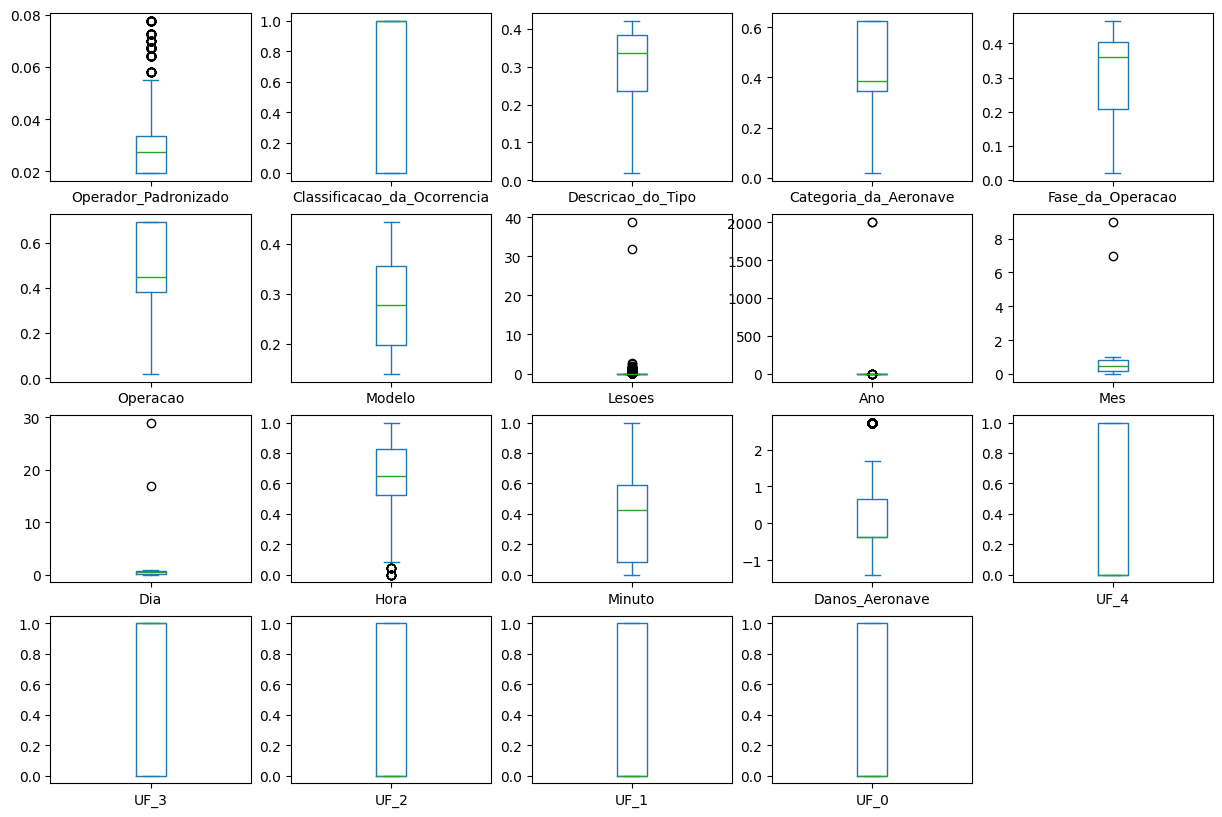

In [ ]:
# 6.1.1 - Boxplot

# Antes do Balanceamento

df_2.plot(kind = 'box', subplots = True, layout = (4,5), sharex = False, sharey = False, figsize = (15,10))
plt.show()

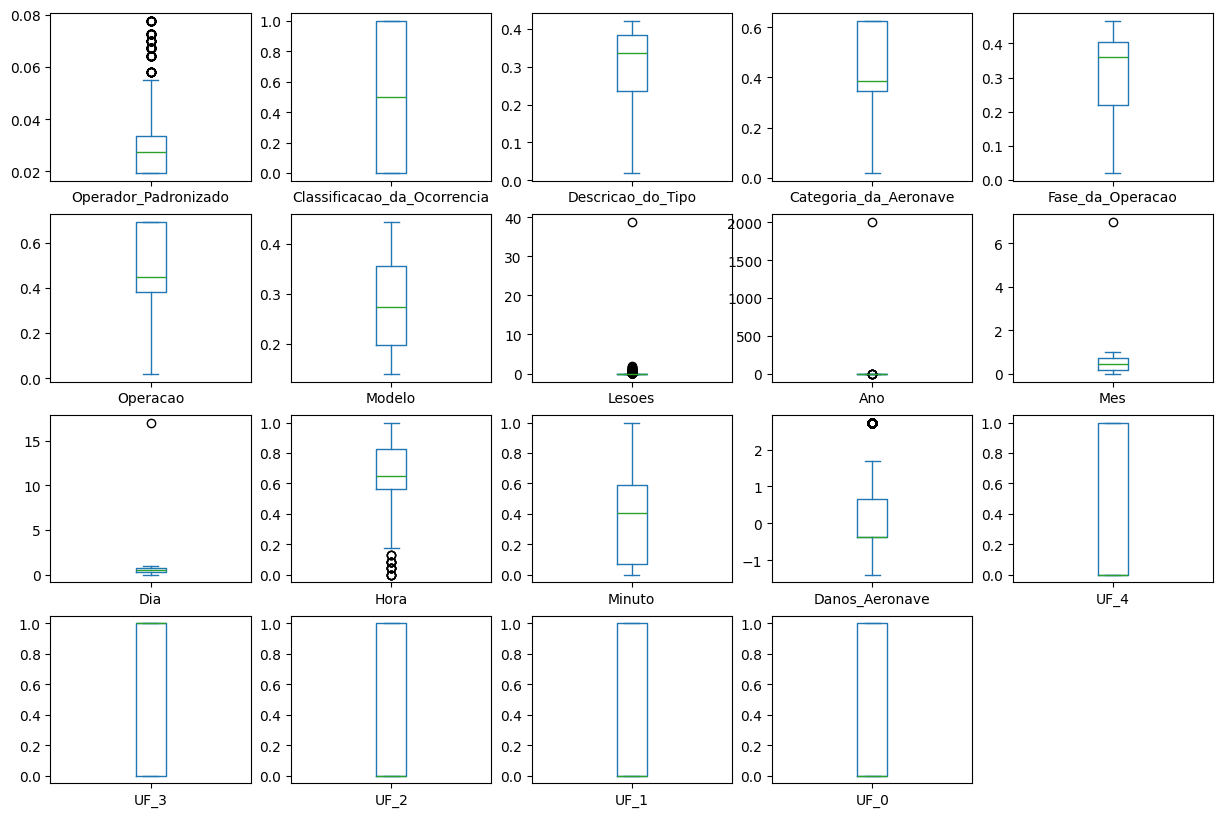

In [ ]:
# 6.1.1 - Boxplot

# Depois do Balanceamento

df_balanceado.plot(kind = 'box', subplots = True, layout = (4,5), sharex = False, sharey = False, figsize = (15,10))
plt.show()

### 6.2.4 - Matriz de Correlação

A comparação entre as matrizes de correlação antes e depois do balanceamento não mostra alteração. Seguem as correlações identificadas após o balanceamento:

- Correlação de -0,64 entre a variável alvo 'Classificação_da_Ocorrência' e o atributo 'Danos_Aeronave'.

- Correlação de 0,66 entre os atributos 'Operacao' e 'Categoria_da_Aeronave'.

- Outras correlações encontradas foram com os atributos 'Lesoes", 'Dia', 'Mês', 'Ano', 'Hora' e 'Minuto'.

- O resto dos atributos apresentou correlações baixas.



### 6.2.4 - Matriz de Correlação (continuação)
A listagem de frequência dos atributos 'Operacao' e 'Categoria_da_Aeronave' mostra que as maiores contagens estão no tipo de 'Operacao' "voo privado" com 1274 ocorrências e na 'Categoria_da_Aeronave' 'TPP' (Serviço Aéreo Privado) com 1030. Isso faz sentido, porque essas classes estão relacionadas a aeronaves utilizadas para o transporte particular, próprio ou corporativo.

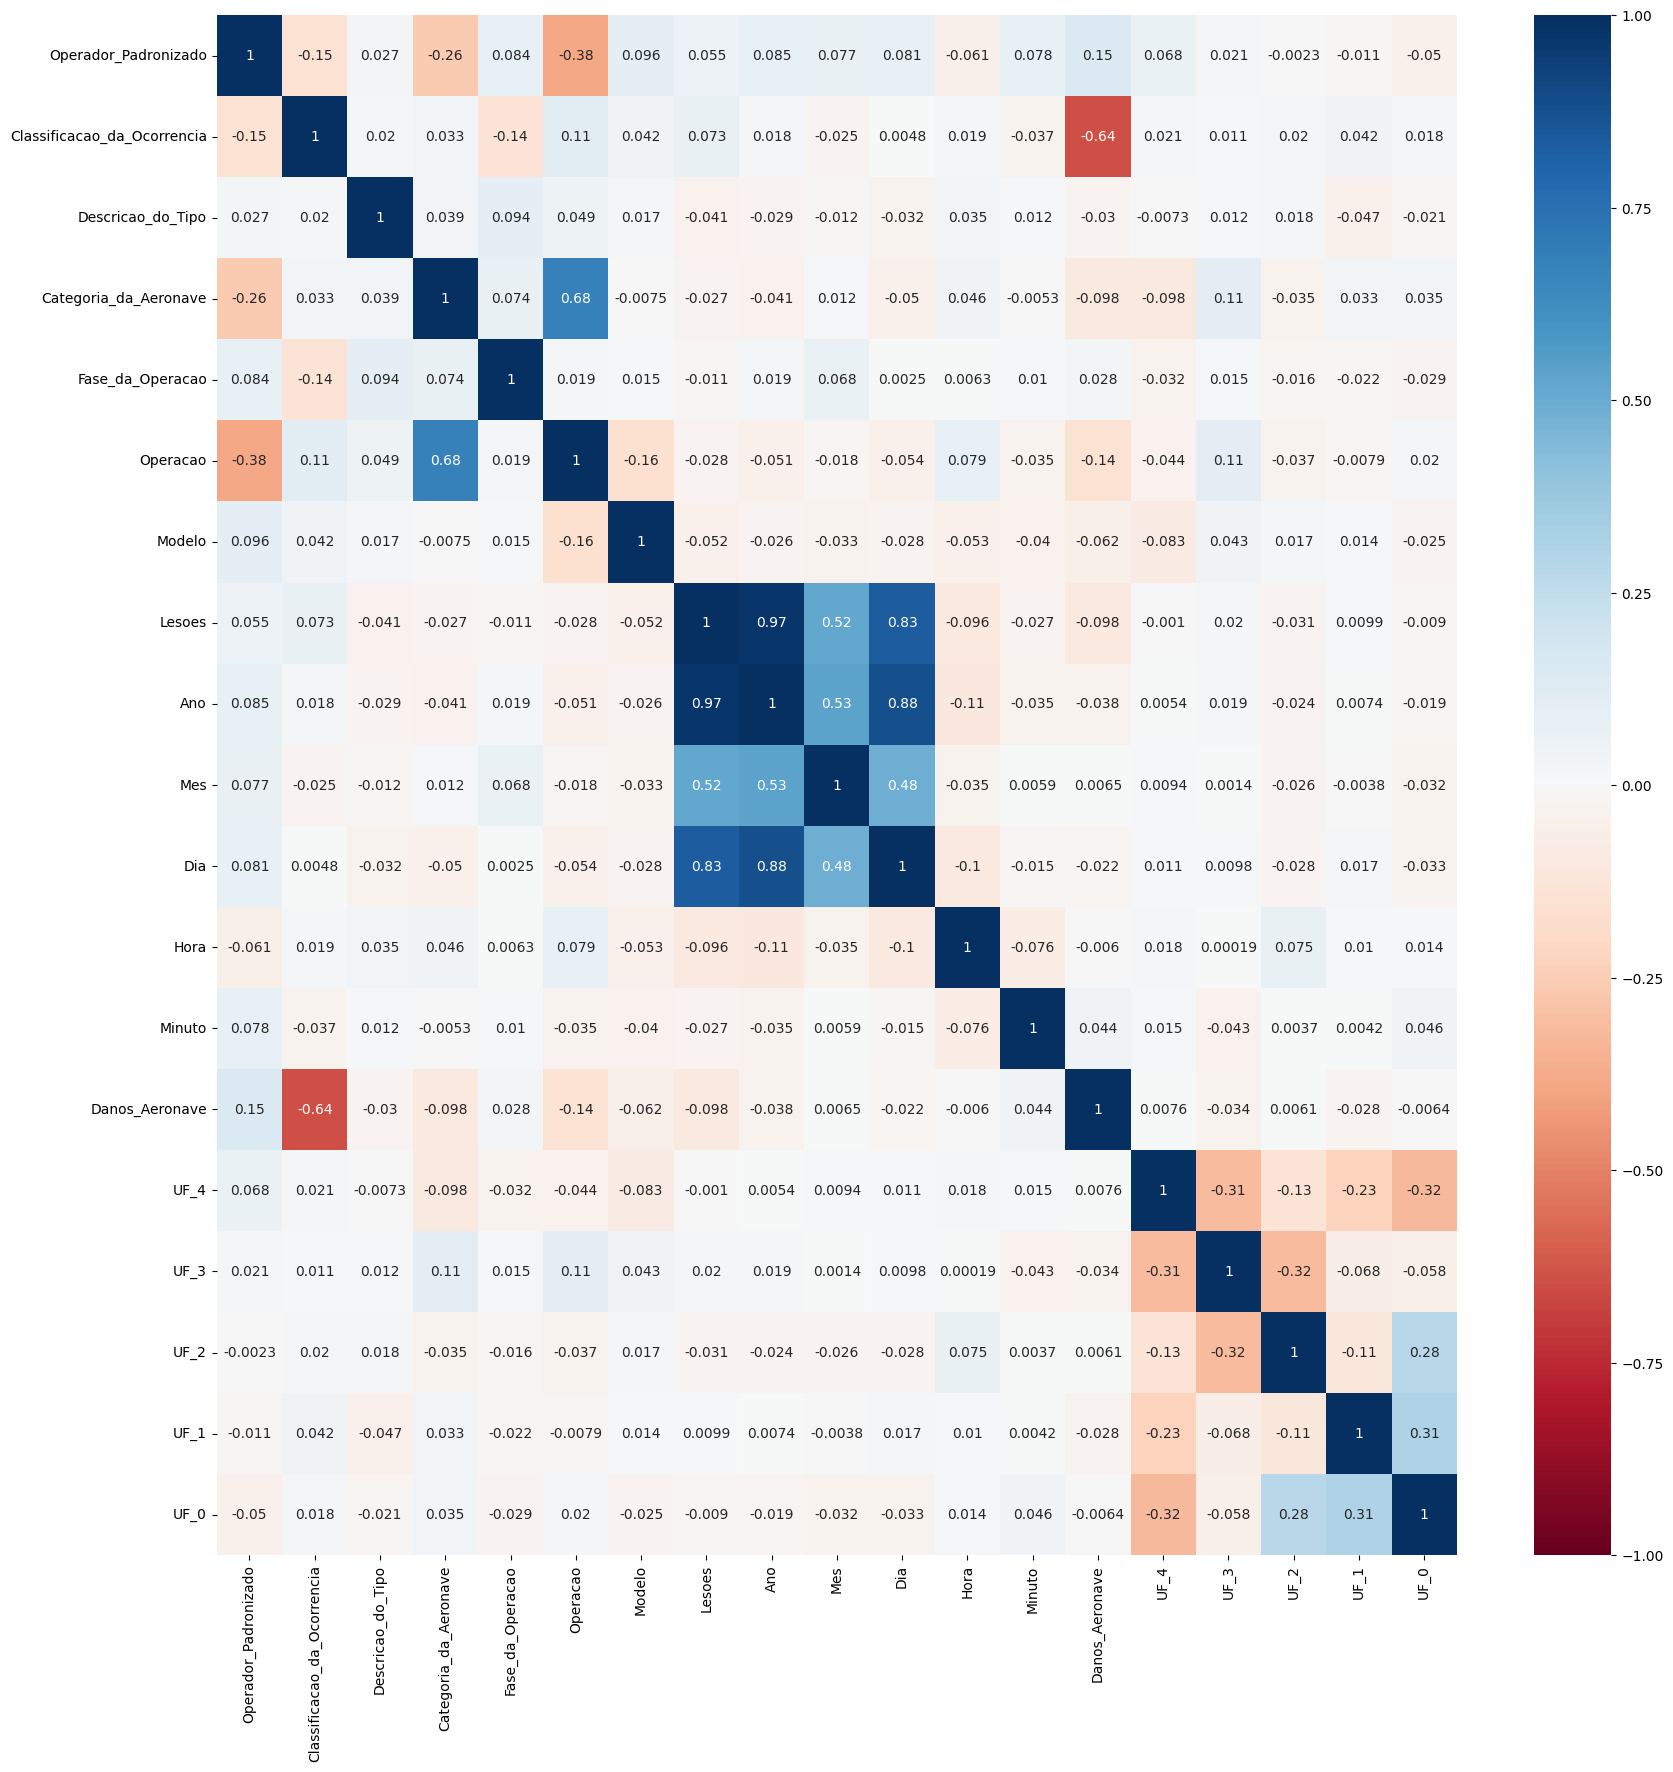

In [ ]:
# 6.2.4 - Matriz de Correlação (continuação)

#  Antes do Balanceamento

plt.figure(figsize = (20,20))
sns.heatmap(df_2.corr(), annot=True, cmap='RdBu', vmin=-1, vmax=1);

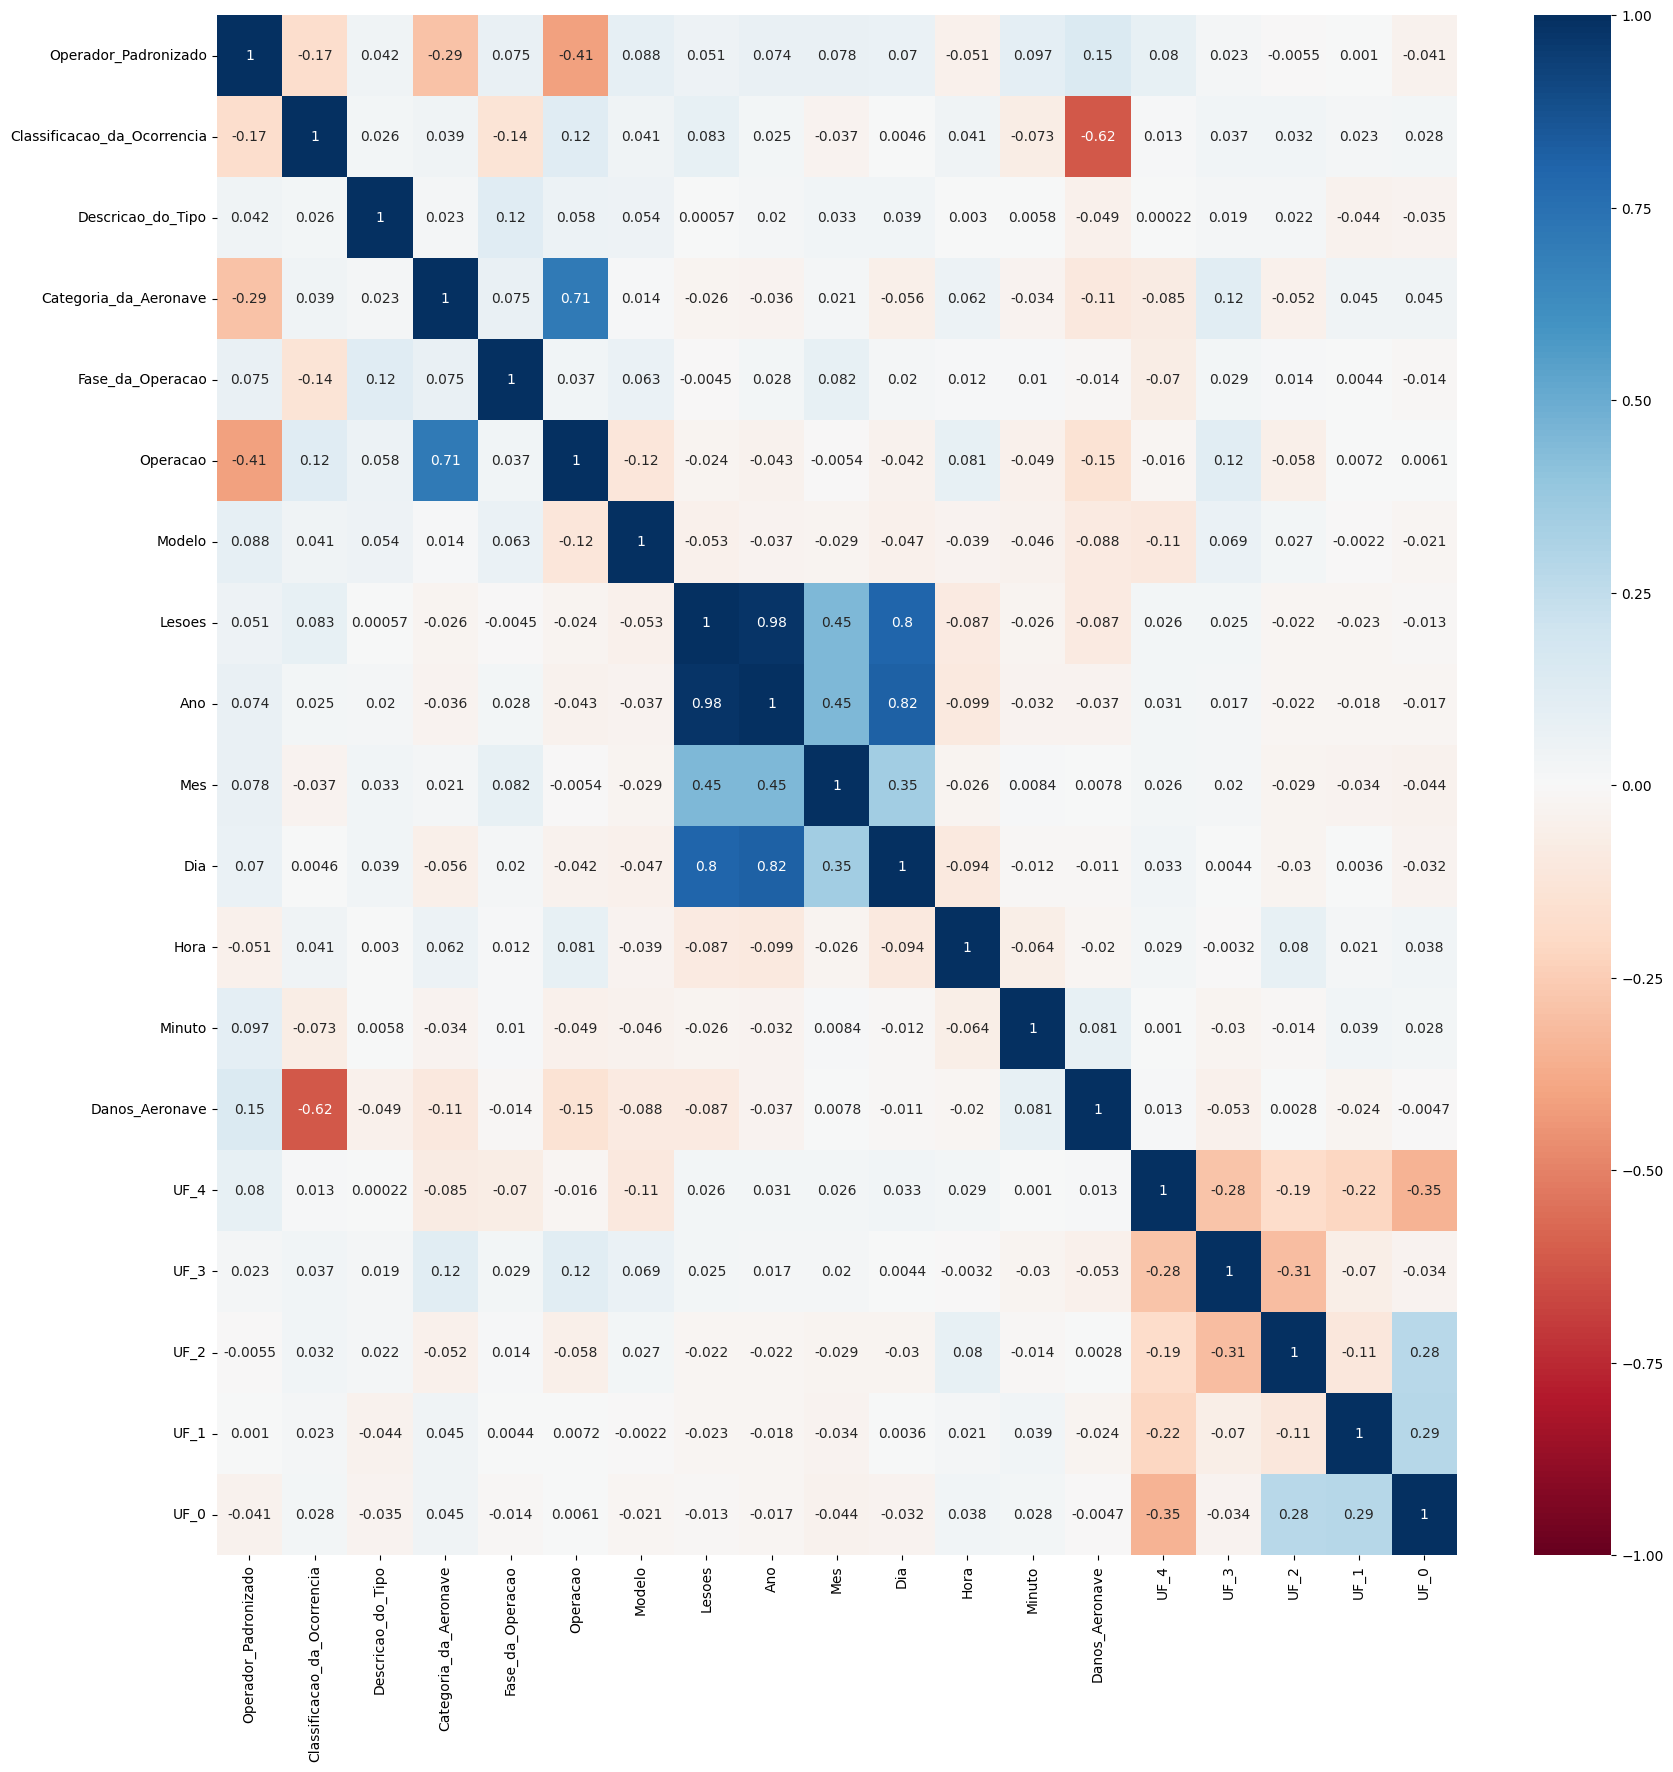

In [ ]:
# 6.2.4 - Matriz de Correlação Depois do Balanceamento (continuação)

#  Depois do Balanceamento

plt.figure(figsize = (20,20))
sns.heatmap(df_balanceado.corr(), annot=True, cmap='RdBu', vmin=-1, vmax=1);

# 7 - Conjunto de Dados Para Treino e Teste

Foi utilizada a função "train_test_split" para dividir o conjunto de dados balanceado em uma proporção de 70% para treino e 30% para teste.

In [ ]:
# 7 - Conjunto de Dados Para Treino e Teste (continuação)

# Aplica a função de separação de dados com 70% para treino e 30% para teste
# X - colunas dos atributos
# y - coluna da variável alvo
X = df_balanceado.drop('Classificacao_da_Ocorrencia', axis=1)
y = df_balanceado['Classificacao_da_Ocorrencia']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
# 7 - Conjunto de Dados Para Treino e Teste  (continuação)

# Imprime os conjuntos de dados de treino e teste

pd.set_option('display.width', 2000)
print("\n->>> Imprime os valores dos atributos para treino.\n")
print(X_train)
print("\n->>> Imprime os valores da variável alvo para treino.\n")
print(y_train)
print("\n->>> Imprime os valores dos atributos para teste.\n")
print(X_test)
print("\n->>> Imprime os valores dos atributos para treino.\n")
print(y_test)
pd.set_option('display.width', 10)


->>> Imprime os valores dos atributos para treino.

      Operador_Padronizado  Descricao_do_Tipo  Categoria_da_Aeronave  Fase_da_Operacao  Operacao    Modelo    Lesoes       Ano       Mes       Dia      Hora    Minuto  Danos_Aeronave  UF_4  UF_3  UF_2  UF_1  UF_0
2503              0.019400           0.420584               0.130140          0.184046  0.130140  0.139284 -0.109519  0.977778  0.272727  0.433333  0.478261  0.000000        0.668037     0     0     1     0     0
402               0.069948           0.384103               0.161149          0.466410  0.158797  0.241247 -0.109519  0.755556  0.818182  0.866667  0.782609  0.372881        2.728366     1     0     0     1     0
134               0.019400           0.324046               0.625033          0.361384  0.692451  0.247686 -0.109519  0.777778  0.454545  0.233333  0.608696  0.000000       -0.362128     0     1     0     1     0
907               0.019400           0.236809               0.625033          0.153984  0.69245

# 8 - Resposta para a Pergunta Formulada ao MVP

Após a consolidação dos dados, será necessário responder à pergunta formulada ao estudo de caso do MVP.

O conjunto de dados tratado ao longo do MVP corresponde aos dados reais?

Para verificar se o conjunto de dados corresponde a realidade, serão utilizadas as estatísticas do banco de dados do CENIPA que é o órgão responsável pela investigação de ocorrências aeronáuticas no Brasil.
(Fonte CENIPA: https://painelsipaer.cenipa.fab.mil.br/extensions/Sipaer/Sipaer.html).

Para essa comparação foram selecionados os atributos:

- 'Classificacao_da_Ocorrencia' (Acidentes/Incidentes Graves)
- 'Lesões'
- 'Operação'
- 'Modelo' (Modelo de aeronave)
- 'Descricao_do_Tipo' (Tipo da falha)
- 'UF'






##8.1 Acidentes-Incidente Graves x Ano

Tentou-se encontrar os dados consolidados de acidentes e incidentes graves por ano no Brasil para validar os dados do MVP. Entretanto, o CENIPA considera o número de acidentes e incidentes separadamente. Comparando o gráfico de acidentes por ano do CENIPA com o histograma do MVP, verifica-se que o número de acidentes e incendentes graves nos anos de 2017, 2021 e 2023 estão bem mais baixos que no histograma do MVP.

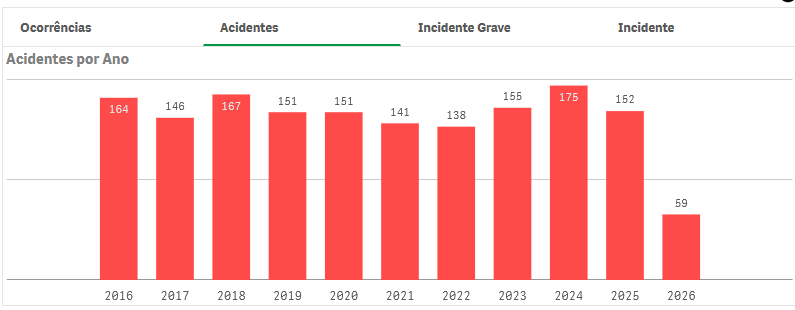



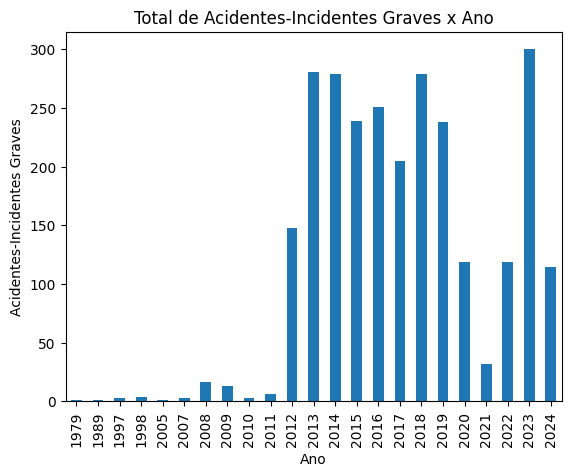

In [ ]:
# 8.1 - Plotagem dos Histogramas de "Ocorrências x Ano" (continuação)

# Plota o gráfico de barras "Acidentes-Incidentes Graves x Ano" antes da transformação
# dos atributos para serem utilizados na validação dos dados

# Verifica se é do tipo data
df_1['Data_da_Ocorrencia'] = pd.to_datetime(df_1['Data_da_Ocorrencia'], format='%d/%m/%Y', errors='coerce')

# Agrupa pelo ano e conta o total de ocorrências
df_agrupado1 = df_1.groupby(df_1['Data_da_Ocorrencia'].dt.year).size().reset_index(name='Total_Ocorrencias')
df_agrupado1.rename(columns={'Data_da_Ocorrencia': 'Ano'}, inplace=True)

# Plota o gráfico de barras
df_agrupado1.plot(kind='bar', x='Ano', y='Total_Ocorrencias', legend=False)
plt.ylabel('Acidentes-Incidentes Graves')
plt.title('Total de Acidentes-Incidentes Graves x Ano')
plt.show()

## 8.2 - Lesões (Fatalidades) x Ano



Para se comparar os gráficos de lesões ou fatalidades é necessário somar os números das barras laranja e vermelha no gráfico do CENIPA, mas, mesmo assim, os totais de cada ano não casam com os dados do MVP, principalmente nos anos 2020, 2021 e 2024.

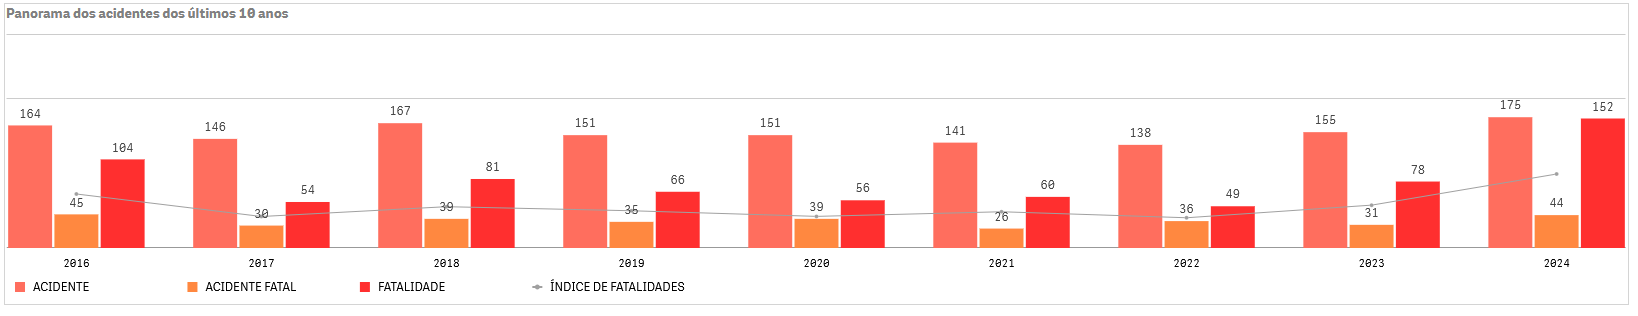

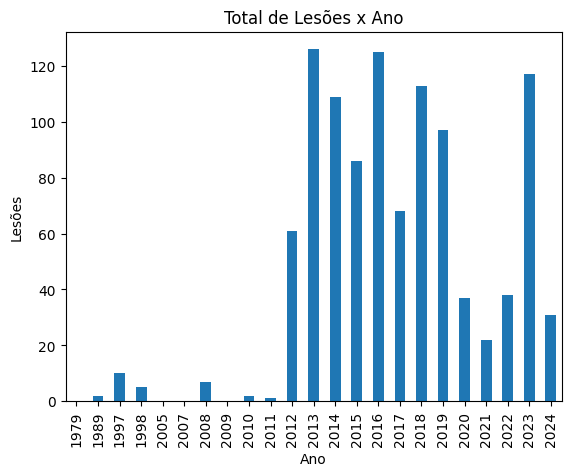

In [ ]:
# 8.2 - Plotagem dos Histogramas de "Lesões x Ano" (continuação)

# Plota o gráfico de barras de "Lesões x Ano" antes da transformação
# dos atributos para serem utilizados na validação dos dados.

# Agrupa pelo ano e conta o total de ocorrências
df_1['Data_da_Ocorrencia'] = pd.to_datetime(df_1['Data_da_Ocorrencia'], format='%d/%m/%Y', errors='coerce')

# Agrupa pelo ano e conta o total de ocorrências
df_agrupado1 = df_1.groupby(df_1['Data_da_Ocorrencia'].dt.year)['Lesoes'].sum().reset_index()
df_agrupado1.rename(columns={'Data_da_Ocorrencia': 'Ano'}, inplace=True)

# Plota o gráfico de barras
df_agrupado1.plot(kind='bar', x='Ano', y='Lesoes', legend=False)
plt.ylabel('Lesões')
plt.title('Total de Lesões x Ano')
plt.show()


##8.3 - Tipos de Operação

A comparação dos gráficos mostra que não há relação entre os resultados referentes ao tipo de operação.

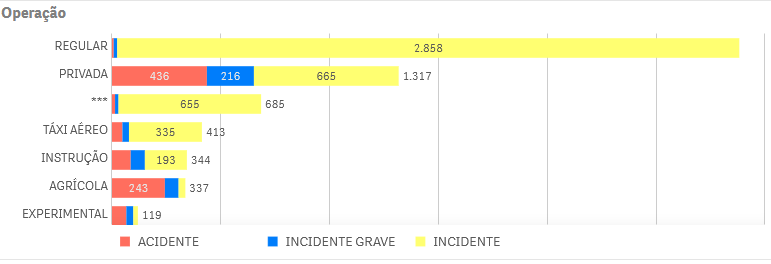

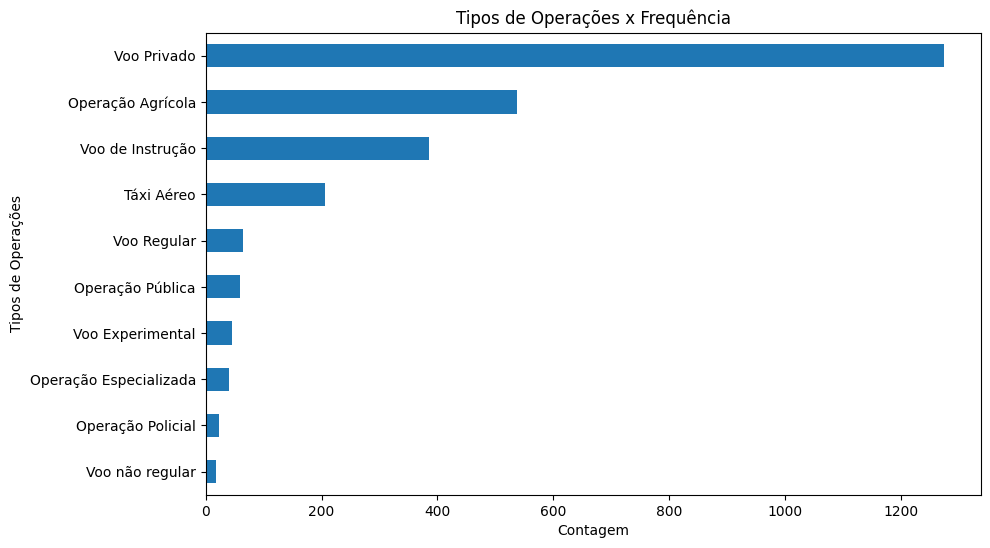

In [ ]:
# 8.3 - Operação

# Filtra os 10 primeiros
top10 = df_1['Operacao'].value_counts().head(10)

# Plota gráfico de barras horizontal
top10.plot(kind='barh', figsize=(10, 6))

plt.title('Tipos de Operações x Frequência')
plt.xlabel('Contagem')
plt.ylabel('Tipos de Operações')
plt.gca().invert_yaxis()
plt.show()

## 8.4 - Modelo de Aeronave

A comparação dos gráficos mostra que não há relação entre os resultados de modelos de aeronaves.

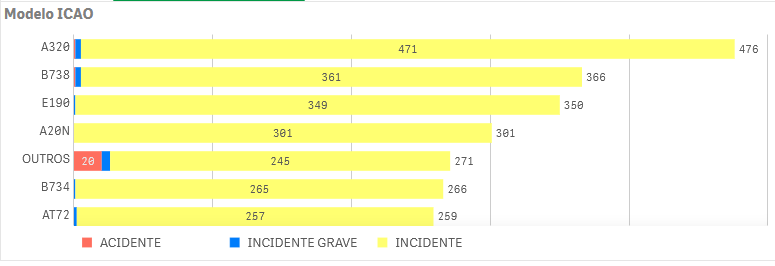

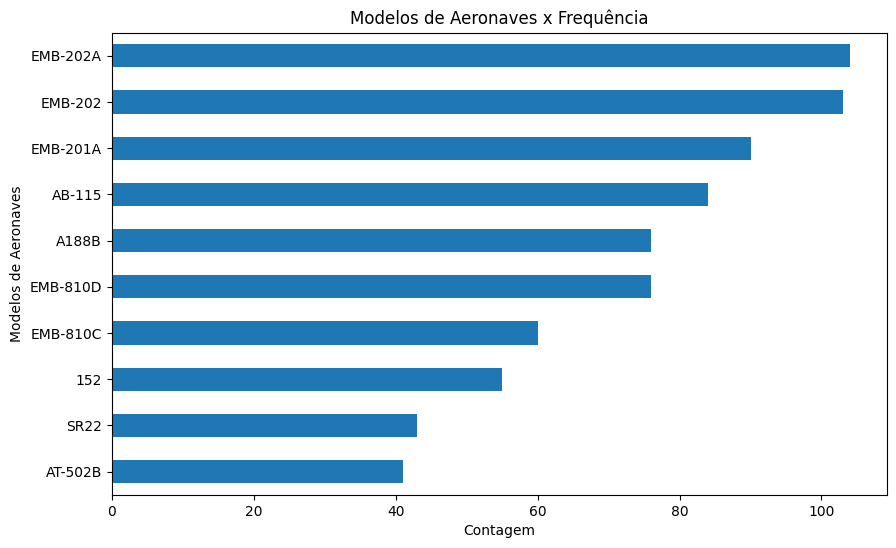

In [ ]:
# 8.4 - Modelo de Aeronave

# Filtra os 10 primeiros
top10 = df_1['Modelo'].value_counts().head(10)

# Plota gráfico de barras horizontal
top10.plot(kind='barh', figsize=(10, 6))

plt.title('Modelos de Aeronaves x Frequência')
plt.xlabel('Contagem')
plt.ylabel('Modelos de Aeronaves')
plt.gca().invert_yaxis()
plt.show()

## 8.5 - Tipo de Ocorrência

Comparando os gráficos verifica-se que a distribuição de frequências nos tipos de ocorrências não casam. A ocorrência de "FALHA OU MAU FUNCIONAMENTO DO MOTOR"
aparece em primeiro lugar no CENIPA e em terceiro no MVP.

- CENIPA:

1 - FALHA OU MAU FUNCIONAMENTO DE SISTEMA COMPONTENE" (Não foi possível caputpar a tela com a descrição da ocorrência)

2 - COLISÃO COM AVE

3 - FALHA OU MAU FUNCIONAMENTO DO MOTOR

- MVP

1 - FALHA OU MAU FUNCIONAMENTO DO MOTOR

2 - EXCURSÃO DE PISTA

3 - PERDA DE CONTROLE EM VOO


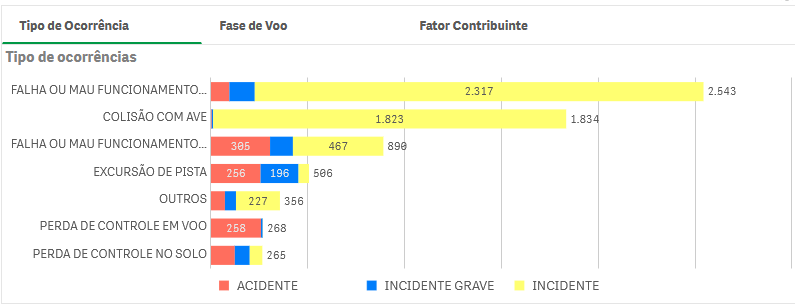

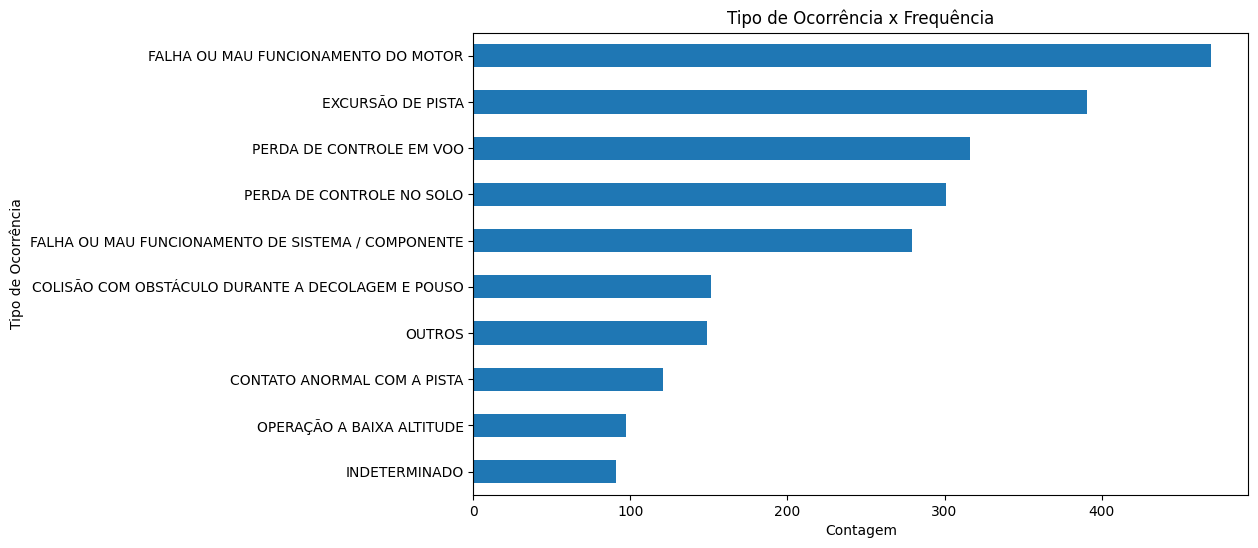

In [ ]:
# 8.5 - Tipo de Ocorrência

top10 = df_1['Descricao_do_Tipo'].value_counts().head(10)

# Plota gráfico de barras horizontal
top10.plot(kind='barh', figsize=(10, 6))

plt.title('Tipo de Ocorrência x Frequência')
plt.xlabel('Contagem')
plt.ylabel('Tipo de Ocorrência')
plt.gca().invert_yaxis()
plt.show()

## 8.6 - UF

Para o atributo UF, somente a primeira posição casou ("SP"). Entrantanto, "RJ" aparece em décimo lugar no MVP e em segundo lugar no CENIPA.

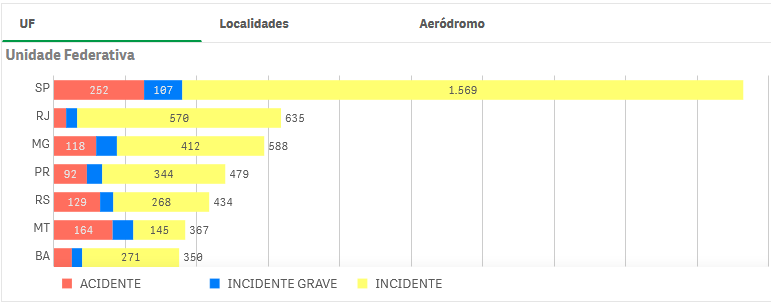

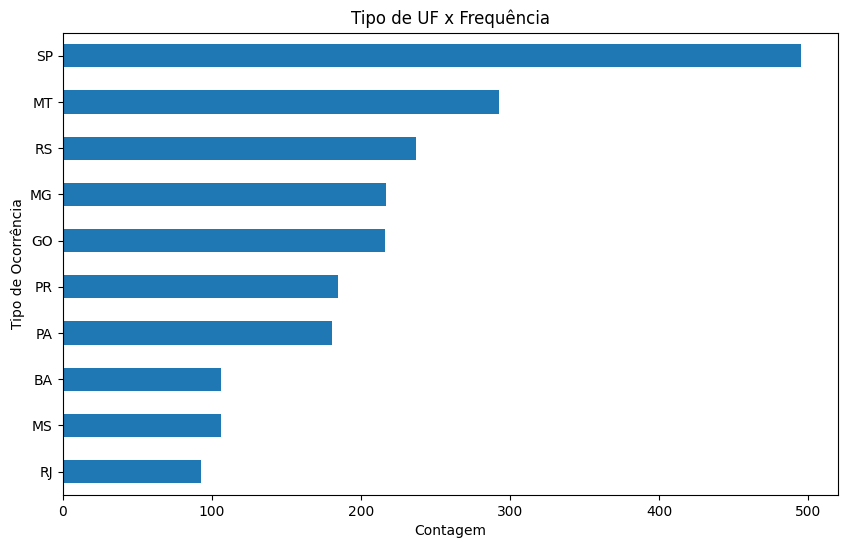

In [ ]:
# 8.6 - UF

# Filtra os 10 primeiros
top10 = df_1['UF'].value_counts().head(10)

# Plota gráfico de barras horizontal
top10.plot(kind='barh', figsize=(10, 6))

plt.title('Tipo de UF x Frequência')
plt.xlabel('Contagem')
plt.ylabel('Tipo de Ocorrência')
plt.gca().invert_yaxis()
plt.show()

#9 - Conclusões

1 - É importante ter metadados (Dicionário de Dados) bem detalhados para que o cientista de dados avalie e trate cada atributo corretamente.

2 - Os acidentes aéreos ocorridos com as aeronaves da GOL e da TAM com centenas de vítimas estavam registrados no conjunto de dados original da ANAC com o valor "DESCONHECIDO" no atributo "UF", que é um erro. Por causa dessa falha, dados importantes não foram considerados corretamente na limpeza de dados e tiveram que ser recuperados manualmente. Esse fato contribuiu para transformar totalmente as estatísticas do atributo "Lesões" com a inclusão de dois outliers reais. Por isso, é importante que as organizações governamentais disponibilizem dados confiáveis à população.

3 - Comparando os dados do CENIPA, órgão responsável pela investigação das ocorrências aeronáuticas no Brasi com os dados do MVP, que tiveram origem nos dados da ANAC, verifica-se que o conjunto de dados do MVP não possui as mesmas características do conjunto de dados do CENIPA.

Uma hipótese para esse descasamento entre os conjuntos de dados poderia ser a má qualidade dos dados da ANAC, que impôs uma limpeza profunda nos dados distorcendo os dados do conjunto de dados do MVP.

4 - Como o objetivo do MVP era fornecer uma base de dados para auxiliar na previsão de ocorrências aeronáuticas no Brasil, após o resultado negativo obtido na comparação entre alguns atributos do MVP e do CENIPA, a sugestão é utilizar o conjunto de dados do MVP no treinamento do aprendizado de máquina para verificar qual será o resultado. Isto será feito na Sprint de Aprendizado de Máquina.



#10 - Agradecimentos

Faz-se necessário agradecer os orientadores pelas dicas e explicações dadas para a execução do trabalho do MVP da Sprint de Análise de Dados e Boas Práticas.